# WaDi A2 - Pipeline Notebook 2 - EDA

The notebook will cover the following:
* **Dataset:** WaDi.A2_19 Nov 2019 - Water Distribution testbed, iTrust Labs, SUTD
* **Scope:** Sections 0–8. Loads the staged Parquet from NB1, investigates temporal
  distribution shift, attack signatures, and normalization strategy, and produces a
  documented set of findings and pipeline recommendations.
* **Input:** Staged Parquet from NB1 (`wadi_staged_*.parquet`)
* **Output:** EDA report artifacts saved to `results/eda/` — no modifications to the data
  pipeline. All downstream design decisions are documented in Section 8.

# Stage 0 - Setup

## 0.1 - Imports and Paths


In [1]:
from __future__ import annotations

from pathlib import Path
from datetime import datetime, timezone
import json
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

# ── Paths ─────────────────────────────────────────────────────────────────────
WORK_DIR    = Path("work")
PROJECT_DIR = WORK_DIR / "wadi_A2"
DATA_DIR    = PROJECT_DIR / "data"
RAW_DIR     = DATA_DIR / "raw"
STAGED_DIR  = DATA_DIR / "staged"
REF_DIR     = DATA_DIR / "reference"
RUN_DIR     = REF_DIR / "pipeline_runs"
RESULTS_DIR = PROJECT_DIR / "results" / "eda"

for p in [RAW_DIR, STAGED_DIR, REF_DIR, RUN_DIR, RESULTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_DIR)
print("Raw:    ", RAW_DIR)
print("Staged: ", STAGED_DIR)
print("Ref:    ", REF_DIR)

Project: work/wadi_A2
Raw:     work/wadi_A2/data/raw
Staged:  work/wadi_A2/data/staged
Ref:     work/wadi_A2/data/reference


## 0.2 - Helpers

In [2]:
def save_fig(fig, name):
    """Save figure to RESULTS_DIR."""
    fig.savefig(RESULTS_DIR / name, dpi=150, bbox_inches="tight")
    plt.close(fig)

def descriptive_profile(df, cols):
    """Return DataFrame of n, mean, median, std, IQR, p95, p99 for each column."""
    stats = df[cols].describe(percentiles=[.25, .50, .75, .95, .99])
    profile = pd.DataFrame({
        "n":      stats.loc["count"],
        "mean":   stats.loc["mean"],
        "median": stats.loc["50%"],
        "std":    stats.loc["std"],
        "IQR":    stats.loc["75%"] - stats.loc["25%"],
        "p95":    stats.loc["95%"],
        "p99":    stats.loc["99%"],
    })
    return profile

def missingness_snapshot(df):
    """Return DataFrame of pct_missing per column, sorted descending. Only shows columns with missing values."""
    missing = df.isnull().mean() * 100
    missing.name = "pct_missing"
    missing = missing[missing > 0].sort_values(ascending=False).to_frame()
    return missing

## 0.3 - Configuration

In [3]:
from datetime import datetime, timezone

# Dataset Identity
DATASET_NAME  = "WaDi.A2_19 Nov 2019"
DATA_SOURCE   = "iTrust Labs, SUTD"

# Gap threshold for identifying contiguous time blocks
GAP_THRESHOLD_SECONDS = 60

# Run ID — used to tag EDA artifacts
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_utc")

print(f"Dataset:  {DATASET_NAME}")
print(f"Source:   {DATA_SOURCE}")
print(f"Run ID:   {RUN_ID}")

Dataset:  WaDi.A2_19 Nov 2019
Source:   iTrust Labs, SUTD
Run ID:   20260309_224959_utc


# Stage 1 - Load and Verify 

In [4]:
# 1.1 Load Staged Parquet
staged_files = sorted(STAGED_DIR.glob("wadi_staged_*.parquet"))

if not staged_files:
    raise FileNotFoundError(f"No staged parquet files found in {STAGED_DIR}")

staged_path = staged_files[-1]
df = pd.read_parquet(staged_path)

print(f"Loaded:  {staged_path.name}")
print(f"Shape:   {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")

Loaded:  wadi_staged_20260228_160757_utc.parquet
Shape:   (957372, 103)

Dtypes:
timestamp                   datetime64[ns, UTC]
observation_day                          object
seconds_since_start                     float32
split                                    object
label                                      int8
                                   ...         
3_AIT_005_PV                            float32
3_FIT_001_PV                            float32
3_LT_001_PV                             float32
LEAK_DIFF_PRESSURE                      float32
TOTAL_CONS_REQUIRED_FLOW                float32
Length: 103, dtype: object


## 1.2 Sanity Checks

Verify the staged DataFrame matches expectations before any analysis. Check
column presence, label values, split values, time range, and missingness. Any
failure here indicates a problem in NB1 output that must be resolved before
proceeding.

**What we expect to see:** All required columns present, labels confined to {0, 1},
splits confined to {train, test}, timestamps spanning Sept 25 – Oct 11 2017, and
no missing values in sensor columns.

In [5]:
# Expected structure
REQUIRED_COLS = ["timestamp", "observation_day", "seconds_since_start", "split", "label"]
sensor_cols = [c for c in df.columns if c not in REQUIRED_COLS]

# Column check
missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
print(f"Required columns missing: {missing_cols if missing_cols else 'None'}")
print(f"Sensor columns found:     {len(sensor_cols)}")

# Label and split values
print(f"\nLabel values:  {sorted(df['label'].unique())}")
print(f"Split values:  {sorted(df['split'].unique())}")

# Time range
print(f"\nTimestamp min: {df['timestamp'].min()}")
print(f"Timestamp max: {df['timestamp'].max()}")

# Label and split distribution
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nSplit distribution:\n{df['split'].value_counts()}")

# Missingness
snapshot = missingness_snapshot(df[sensor_cols])
print(f"\nMissing values in sensor columns:")
print("None" if snapshot.empty else snapshot)

Required columns missing: None
Sensor columns found:     98

Label values:  [np.int8(0), np.int8(1)]
Split values:  ['test', 'train']

Timestamp min: 2017-09-25 00:00:00+00:00
Timestamp max: 2017-10-11 00:59:59+00:00

Label distribution:
label
0    947395
1      9977
Name: count, dtype: int64

Split distribution:
split
train    861845
test      95527
Name: count, dtype: int64

Missing values in sensor columns:
               pct_missing
1_AIT_002_PV      0.001253
2B_AIT_004_PV     0.001045
1_AIT_004_PV      0.000627
3_AIT_004_PV      0.000627


### 1.2 Analysis

- **Structure:** All required columns present, 98 sensor columns confirmed.
- **Labels:** Confined to {0, 1} as expected. No unexpected values.
- **Splits:** Confined to {train, test} as expected.
- **Time range:** Sept 25 – Oct 11 2017. Matches the known WaDi A2 recording window.
- **Class imbalance:** Attack rows represent ~1% of the dataset (9,977 / 957,372).
  This will need to be addressed in NB6 and NB7 via class weighting or resampling.
- **Missingness:** Four sensors show minimal missingness (<0.002%). Not a concern
  at this stage but will be monitored through fault injection and feature engineering.

# Section 2 - Dataset Timeline  

The WaDi A2 dataset is not continuous, it was recorded in daily sessions with
~23-hour gaps between them. This section identifies those contiguous time blocks,
summarizes their contents, and visualizes the dataset structure. This is foundational
for understanding how the data is organized before any deeper analysis.

## 2.1 Identify Contiguous Time Blocks

Use timestamp differences to detect gaps larger than GAP_THRESHOLD_SECONDS (60s).
Each contiguous segment between gaps is treated as one block. We expect 14 blocks, 
one per recording day, each roughly 1 hour long with ~23-hour gaps between them.

In [6]:
df_sorted = df.sort_values("timestamp").reset_index(drop=True)

time_diffs = df_sorted["timestamp"].diff()
gap_mask = time_diffs > pd.Timedelta(seconds=GAP_THRESHOLD_SECONDS)
df_sorted["block_id"] = gap_mask.cumsum()

blocks = []
for block_id, block_df in df_sorted.groupby("block_id"):
    blocks.append({
        "block_id":    block_id,
        "date":        block_df["timestamp"].min().date(),
        "start":       block_df["timestamp"].min(),
        "end":         block_df["timestamp"].max(),
        "n_rows":      len(block_df),
        "n_normal":    (block_df["label"] == 0).sum(),
        "n_attack":    (block_df["label"] == 1).sum(),
        "split":       block_df["split"].iloc[0],
    })

block_summary = pd.DataFrame(blocks)
print(f"Blocks found: {len(block_summary)}")
print(block_summary.to_string(index=False))

Blocks found: 14
 block_id       date                     start                       end  n_rows  n_normal  n_attack split
        0 2017-09-25 2017-09-25 00:00:00+00:00 2017-09-25 00:59:59+00:00   21600     21600         0 train
        1 2017-09-26 2017-09-26 00:00:00+00:00 2017-09-26 00:59:59+00:00   86400     86400         0 train
        2 2017-09-27 2017-09-27 00:00:00+00:00 2017-09-27 00:59:59+00:00   86400     86400         0 train
        3 2017-09-28 2017-09-28 00:00:00+00:00 2017-09-28 00:59:59+00:00   86400     86400         0 train
        4 2017-09-29 2017-09-29 00:00:00+00:00 2017-09-29 00:59:59+00:00   55199     55199         0 train
        5 2017-10-02 2017-10-02 00:00:00+00:00 2017-10-02 00:59:59+00:00   26401     26401         0 train
        6 2017-10-03 2017-10-03 00:00:00+00:00 2017-10-03 00:59:59+00:00   86400     86400         0 train
        7 2017-10-04 2017-10-04 00:00:00+00:00 2017-10-04 00:59:59+00:00   86400     86400         0 train
        8 2017-10-05

### 2.1 Analysis

- **14 blocks confirmed** — one per recording day as expected.
- **Three partial days:** Sept 25 (21,600 rows / 6hrs), Sept 29 (55,199 rows),
  and Oct 7 (76,571 rows). Likely recording start/stop artifacts rather than
  data quality issues.
- **Two missing days:** Sept 30 and Oct 1 do not appear in the dataset at all.
  The gap between Sept 29 and Oct 2 spans 3 days.
- **Attack distribution:** Attacks appear in blocks 11, 12, and 13 (Oct 9–11).
  Block 11 is assigned to train per the manual split strategy, containing 1,501
  attack rows. Blocks 12 and 13 are test.
- **All train blocks prior to Oct 9 are normal-only** — no label leakage from
  the pre-attack period into the training set.
- **Implication for normalization:** The training set spans 11 blocks of varying
  length across 13 days. Any normalization fitted on the full train split will
  reflect this multi-day structure. Whether that normalization generalizes to the
  test blocks (Oct 9–11) is an open question — Section 7 will investigate this
  directly.


## 2.2 Block Summary Table

Extend the block summary with attack sequence assignments. This gives a complete
picture of how the 7 attack sequences are distributed across blocks and splits,
confirming the manual split strategy from NB1 is intact.

**What we expect to see:** Attack sequences appear only in blocks 11–13, with
some sequences assigned to train and the remainder to test.

In [7]:
# Identify attack sequences within each block
attack_rows = df_sorted[df_sorted["label"] == 1].copy()
attack_diffs = attack_rows["timestamp"].diff()
attack_breaks = attack_diffs > pd.Timedelta(minutes=1)
attack_rows["seq_id"] = attack_breaks.cumsum()

# Map each sequence to its block
seq_to_block = (
    attack_rows.groupby("seq_id")["block_id"]
    .first()
    .reset_index()
    .rename(columns={"block_id": "block"})
)

# Summarize sequences per block
seq_per_block = (
    attack_rows.groupby("block_id")["seq_id"]
    .apply(lambda x: sorted(x.unique().tolist()))
    .reset_index()
    .rename(columns={"seq_id": "attack_sequences"})
)

block_summary_full = block_summary.merge(seq_per_block, on="block_id", how="left")
block_summary_full["attack_sequences"] = block_summary_full["attack_sequences"].apply(
    lambda x: x if isinstance(x, list) else []
)

print(block_summary_full[["block_id", "date", "n_rows", "n_normal", "n_attack", "split", "attack_sequences"]].to_string(index=False))

 block_id       date  n_rows  n_normal  n_attack split attack_sequences
        0 2017-09-25   21600     21600         0 train               []
        1 2017-09-26   86400     86400         0 train               []
        2 2017-09-27   86400     86400         0 train               []
        3 2017-09-28   86400     86400         0 train               []
        4 2017-09-29   55199     55199         0 train               []
        5 2017-10-02   26401     26401         0 train               []
        6 2017-10-03   86400     86400         0 train               []
        7 2017-10-04   86400     86400         0 train               []
        8 2017-10-05   86400     86400         0 train               []
        9 2017-10-06   86400     86400         0 train               []
       10 2017-10-07   76571     76571         0 train               []
       11 2017-10-09   21600     20099      1501 train              [0]
       12 2017-10-10   86400     81266      5134  test          

### 2.2 Analysis

- **7 attack sequences confirmed** (seq_id 0–6), all contained within blocks 11–13
  (Oct 9–11) as expected.
- **Sequence distribution across splits:**
  - Train (block 11, Oct 9): 1 sequence, 1,501 attack rows
  - Test (block 12, Oct 10): 1 sequence, 5,134 attack rows
  - Test (block 13, Oct 11): 5 sequences, 3,342 attack rows
- **Oct 11 is attack-dense:** 5 of the 7 sequences fall on a single day, meaning
  the test set is heavily weighted toward Oct 11 attack patterns. Individual
  sequences on that day are likely short.
- **Class balance within test:** Oct 10 has one long attack sequence while Oct 11
  has five shorter ones, the classifier will encounter both sustained and
  brief attack patterns at test time.
- **Split integrity confirmed:** The manual sequence-level assignment from NB1
  is intact. No sequences straddle the train/test boundary.

## 2.3 Timeline Plot

Visualize the dataset structure as a horizontal bar chart. Each block is shown as
a bar on the timeline, color-coded by whether it contains attacks, with split
assignment labeled. This makes the coarse structure of the dataset immediately
visible: partial days, missing days, and the attack window all stand out clearly.

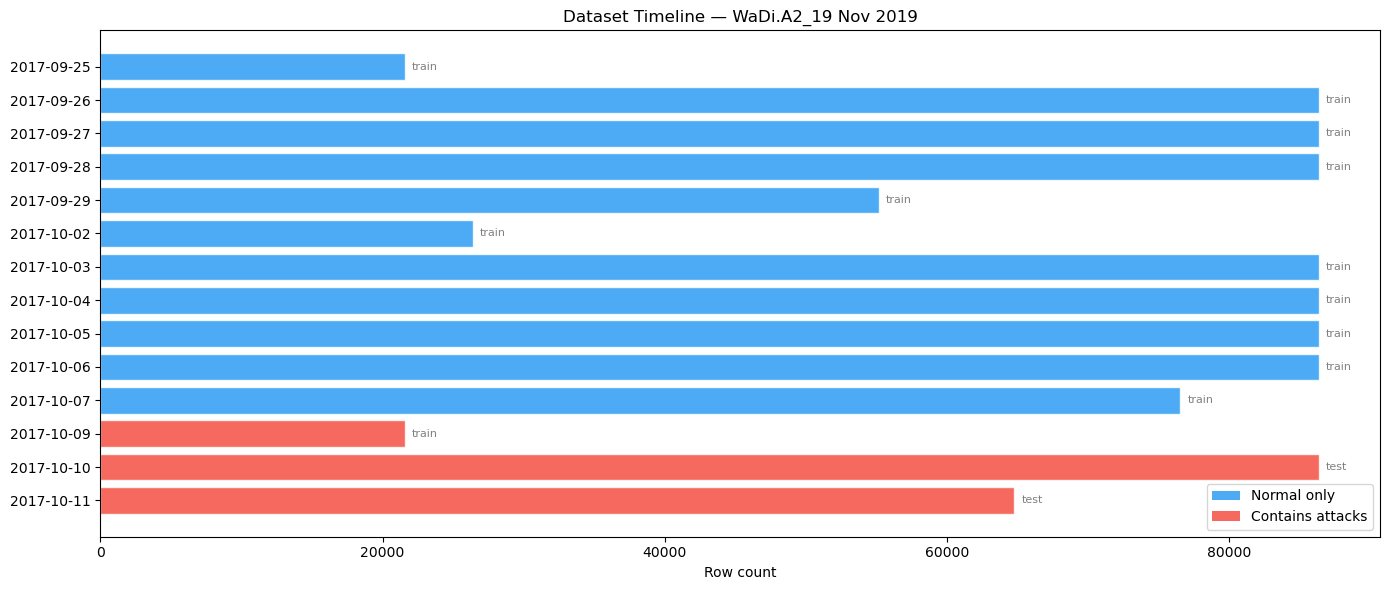

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in block_summary_full.iterrows():
    color = "#F44336" if row["n_attack"] > 0 else "#2196F3"
    ax.barh(
        y=str(row["date"]),
        width=row["n_rows"],
        color=color,
        alpha=0.8,
        edgecolor="white"
    )
    ax.text(
        row["n_rows"] + 500,
        list(block_summary_full["date"].astype(str)).index(str(row["date"])),
        row["split"],
        va="center",
        fontsize=8,
        color="gray"
    )

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", alpha=0.8, label="Normal only"),
    Patch(facecolor="#F44336", alpha=0.8, label="Contains attacks"),
]
ax.legend(handles=legend_elements, loc="lower right")

ax.set_xlabel("Row count")
ax.set_title(f"Dataset Timeline — {DATASET_NAME}")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
save_fig(fig, "eda_timeline.png")


### 2.3 Analysis

The timeline plot makes the dataset structure immediately visible:

- **Partial days** stand out clearly — Sept 25, Sept 29, Oct 2, Oct 7, and Oct 11
  are all shorter than a full recording day.
- **Missing days** are visible as gaps — Sept 30, Oct 1, and Oct 8 are absent entirely.
- **Attack window** is confined to the last three blocks (Oct 9–11), shown in red.
  The transition from normal-only to attack-period recording is abrupt.
- **Train/test boundary** falls at Oct 9. All blue bars are train, all red bars are
  test — with the exception of Oct 9 which is red but labeled train, reflecting the
  manual sequence-level split decision from NB1.
- **Row count variation** across train blocks is notable — the training set is not
  uniform. Some days contribute 86,400 rows (full hour) while others contribute
  significantly less. This uneven contribution could affect what the model learns
  as "normal."


# Section 3 — Day-by-Day Distribution Analysis

The dataset spans 14 recording days across a 17-day window. This section investigates
whether sensor behavior is consistent across those days or whether there is meaningful
day-to-day drift. Drift in the normal period would have direct implications for
normalization strategy and classifier generalization.

We focus on a representative subset of sensors rather than all 98, the goal is to
identify patterns, not exhaustively profile every channel.

## 3.1 Select Representative Sensors

Filter out sensors that are uninformative for distribution analysis: zero-variance,
near-constant, or binary columns. From the remaining eligible sensors, select 6–8
that show meaningful variation across the dataset.

In [9]:
train_df = df_sorted[df_sorted["split"] == "train"]
sensor_cols = [c for c in df.columns if c not in
               ["timestamp", "observation_day", "seconds_since_start", "split", "label"]]

# Filter out low-variance and binary sensors
sensor_cols_s = pd.Series(sensor_cols)
sensor_std = train_df[sensor_cols].std()
sensor_nunique = train_df[sensor_cols].nunique()

eligible_mask = (sensor_std > 0.01) & (sensor_nunique > 2)
eligible = sensor_cols_s[eligible_mask.values].tolist()

print(f"Total sensors:    {len(sensor_cols)}")
print(f"Eligible sensors: {len(eligible)}")
print(f"\nEligible sensor list:\n{eligible}")

Total sensors:    98
Eligible sensors: 78

Eligible sensor list:
['1_AIT_001_PV', '1_AIT_002_PV', '1_AIT_003_PV', '1_AIT_004_PV', '1_AIT_005_PV', '1_FIT_001_PV', '1_LT_001_PV', '1_MV_001_STATUS', '1_MV_004_STATUS', '2_DPIT_001_PV', '2_FIC_101_CO', '2_FIC_101_PV', '2_FIC_101_SP', '2_FIC_201_CO', '2_FIC_201_PV', '2_FIC_201_SP', '2_FIC_301_CO', '2_FIC_301_PV', '2_FIC_301_SP', '2_FIC_401_CO', '2_FIC_401_PV', '2_FIC_401_SP', '2_FIC_501_CO', '2_FIC_501_PV', '2_FIC_501_SP', '2_FIC_601_CO', '2_FIC_601_PV', '2_FIC_601_SP', '2_FIT_001_PV', '2_FIT_002_PV', '2_FIT_003_PV', '2_FQ_101_PV', '2_FQ_201_PV', '2_FQ_301_PV', '2_FQ_401_PV', '2_FQ_501_PV', '2_FQ_601_PV', '2_LT_001_PV', '2_LT_002_PV', '2_MCV_007_CO', '2_MCV_101_CO', '2_MCV_201_CO', '2_MCV_301_CO', '2_MCV_401_CO', '2_MCV_501_CO', '2_MCV_601_CO', '2_MV_003_STATUS', '2_MV_006_STATUS', '2_MV_101_STATUS', '2_MV_201_STATUS', '2_MV_301_STATUS', '2_MV_401_STATUS', '2_MV_501_STATUS', '2_MV_601_STATUS', '2_P_003_SPEED', '2_P_004_SPEED', '2_PIC_003_CO'

In [10]:
# Rank eligible sensors by standard deviation across the full dataset
eligible_std = train_df[eligible].std().sort_values(ascending=False)
print(eligible_std.head(20))

3_AIT_002_PV     2736.802979
2B_AIT_002_PV    1992.043823
3_AIT_004_PV      571.107300
2_DPIT_001_PV     136.302643
2_FIC_501_CO       39.512539
2_FIC_601_CO       38.777496
2_FIC_301_CO       38.143745
2_FIC_401_CO       37.882256
2_FIC_201_CO       37.347862
2_FIC_101_CO       37.150093
2_MCV_601_CO       23.799706
1_AIT_004_PV       22.242624
2_MCV_301_CO       20.793900
2_MCV_501_CO       17.966593
2_MCV_201_CO       17.786541
2_MCV_101_CO       16.213690
2_MCV_401_CO       15.844254
1_AIT_001_PV       14.404626
2_PIC_003_CO        9.337189
1_LT_001_PV         8.841568
dtype: float32


In [11]:
REPRESENTATIVE_SENSORS = [
    "3_AIT_002_PV",    # highest variance — water quality sensor
    "2B_AIT_002_PV",   # second highest — water quality sensor
    "2_DPIT_001_PV",   # differential pressure
    "2_FIC_101_CO",    # flow controller
    "1_AIT_001_PV",    # analytic instrument, moderate variance
    "1_LT_001_PV",     # level transmitter
    "2_PIC_003_CO",    # pressure controller
]

print(f"Representative sensors selected: {len(REPRESENTATIVE_SENSORS)}")
for s in REPRESENTATIVE_SENSORS:
    print(f"  {s:30s}  std={train_df[s].std():.4f}")

Representative sensors selected: 7
  3_AIT_002_PV                    std=2736.8030
  2B_AIT_002_PV                   std=1992.0438
  2_DPIT_001_PV                   std=136.3026
  2_FIC_101_CO                    std=37.1501
  1_AIT_001_PV                    std=14.4046
  1_LT_001_PV                     std=8.8416
  2_PIC_003_CO                    std=9.3372


### 3.1 Analysis

- **78 of 98 sensors** passed the eligibility filter (std > 0.01, unique values > 2).
  The 20 excluded sensors are either near-constant or binary.
- **7 representative sensors selected** spanning different physical measurement types:
  water quality (AIT), differential pressure (DPIT), flow control (FIC),
  level (LT), and pressure control (PIC).
- **Variance spread is large** — `3_AIT_002_PV` (std=2736) and `2B_AIT_002_PV`
  (std=1992) are orders of magnitude more variable than the others. This may reflect
  genuine physical range differences or potentially outlier-driven variance. Worth
  watching in 3.2 and 3.3.
- These sensors will be used as the lens for all distribution analysis in Sections 3–7.

## 3.2 Per-Day Statistics

For each representative sensor, compute per-block summary statistics. This gives
us a quantitative view of how sensor behavior changes across recording days before
we visualize it in 3.3.

In [12]:
per_day_stats = []

for block_id, block_df in df_sorted.groupby("block_id"):
    date = block_df["timestamp"].min().date()
    split = block_df["split"].iloc[0]
    for sensor in REPRESENTATIVE_SENSORS:
        vals = block_df[sensor].dropna()
        per_day_stats.append({
            "block_id": block_id,
            "date":     date,
            "split":    split,
            "sensor":   sensor,
            "mean":     vals.mean(),
            "median":   vals.median(),
            "std":      vals.std(),
            "p95":      vals.quantile(0.95),
        })

per_day_df = pd.DataFrame(per_day_stats)
print(per_day_df.head(20).to_string(index=False))

 block_id       date split        sensor        mean      median         std         p95
        0 2017-09-25 train  3_AIT_002_PV 5465.361328 8279.099609 3919.263672 8279.099609
        0 2017-09-25 train 2B_AIT_002_PV    9.114269    9.106950    0.098234    9.233021
        0 2017-09-25 train 2_DPIT_001_PV 2524.428223 2541.379883  155.756454 2590.041040
        0 2017-09-25 train  2_FIC_101_CO   55.263344   32.913200   35.525612  100.000000
        0 2017-09-25 train  1_AIT_001_PV  169.038101  169.037003    1.445709  171.294998
        0 2017-09-25 train   1_LT_001_PV   55.984238   56.216850    8.525502   69.673897
        0 2017-09-25 train  2_PIC_003_CO   49.578632   50.000000    2.315813   50.000000
        1 2017-09-26 train  3_AIT_002_PV 6298.679199 8002.779785 3173.215820 8279.099609
        1 2017-09-26 train 2B_AIT_002_PV    9.052720    9.055150    0.122869    9.230690
        1 2017-09-26 train 2_DPIT_001_PV 2505.241943 2540.290039  163.331985 2595.300049
        1 2017-09-26 

## 3.3 Per-Day Mean Plot

Plot the per-day mean for each representative sensor as a line chart. Train days
are shown with a blue background tint, test days with a red tint. A vertical dashed
line marks Oct 9, the start of the attack window. This reveals whether sensor
means shift gradually across the recording period or abruptly at the attack boundary.

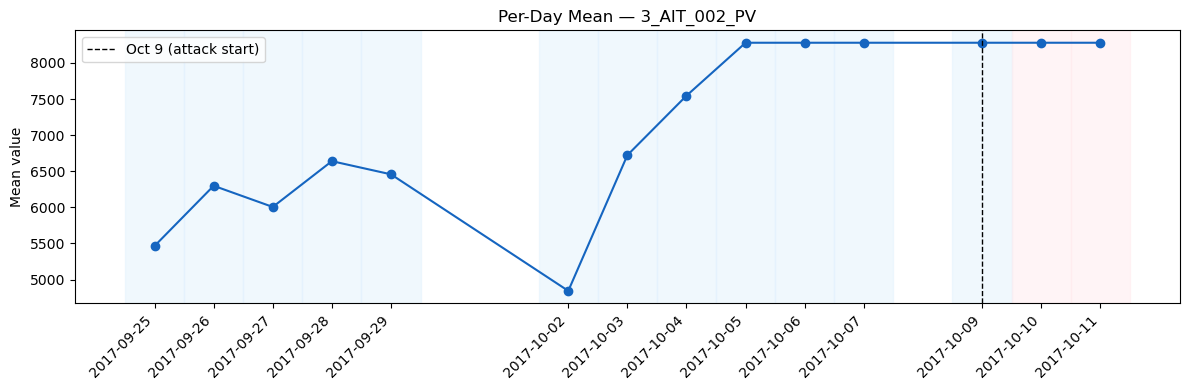

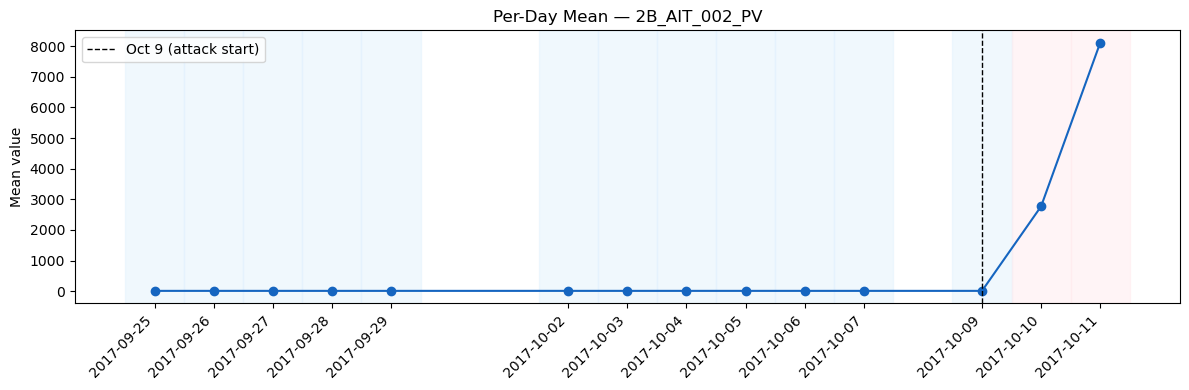

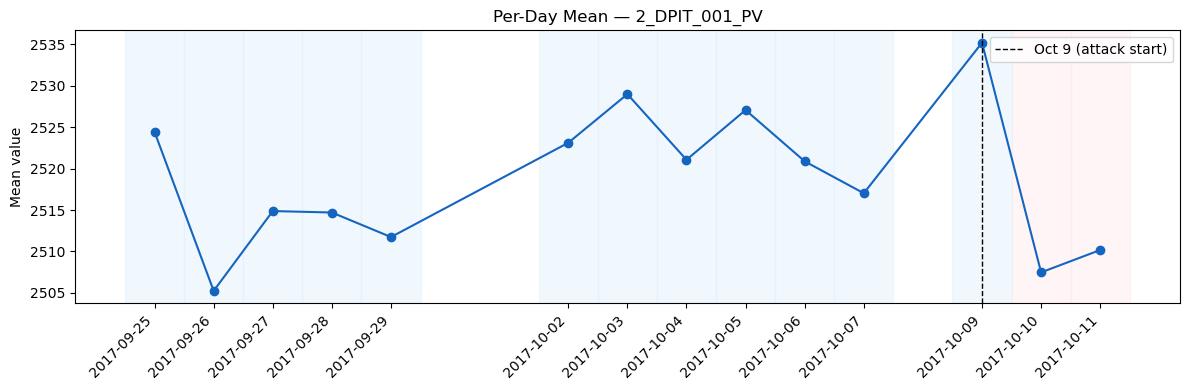

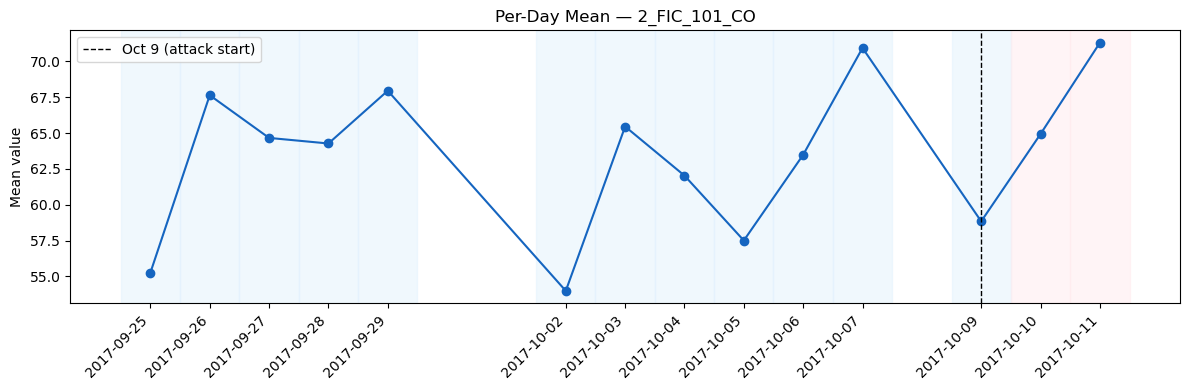

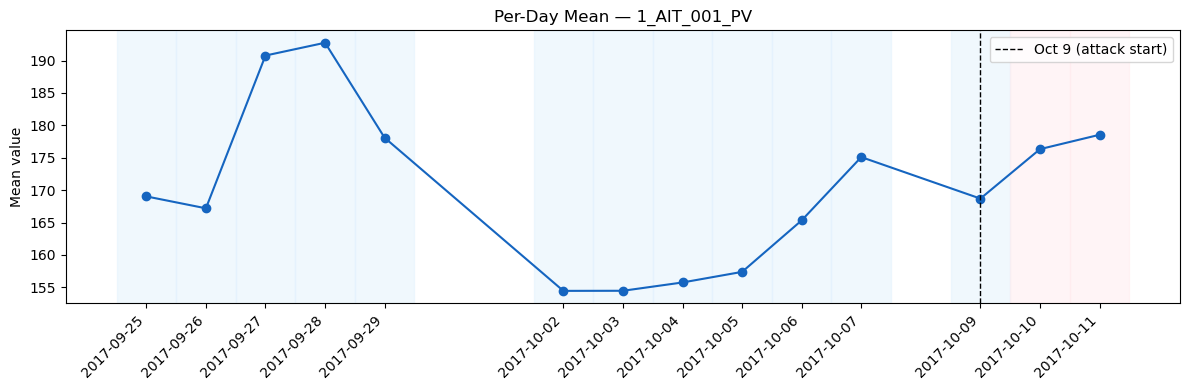

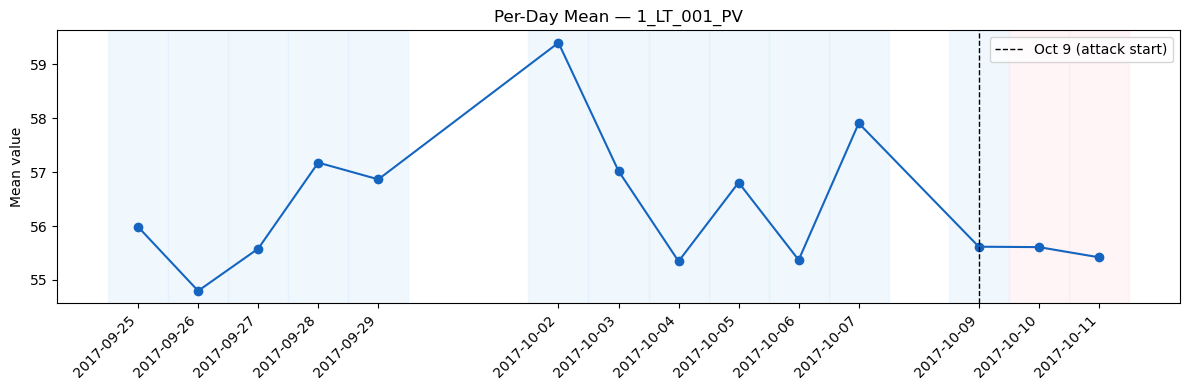

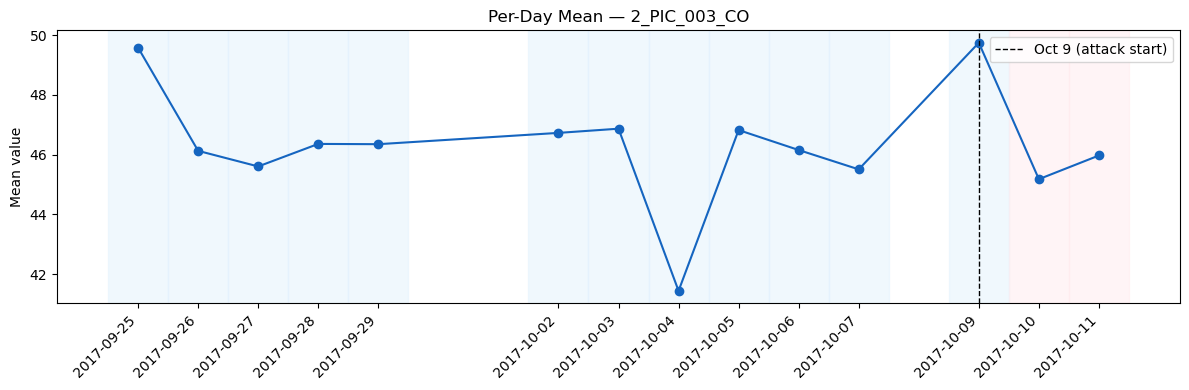

In [13]:
import matplotlib.patches as mpatches

dates = per_day_df["date"].unique()
test_dates = per_day_df[per_day_df["split"] == "test"]["date"].unique()

for sensor in REPRESENTATIVE_SENSORS:
    sensor_df = per_day_df[per_day_df["sensor"] == sensor].sort_values("date")

    fig, ax = plt.subplots(figsize=(12, 4))

    # Background tint by split
    for _, row in sensor_df.iterrows():
        color = "#FFEBEE" if row["split"] == "test" else "#E3F2FD"
        ax.axvspan(
            row["date"].toordinal() - 0.5,
            row["date"].toordinal() + 0.5,
            color=color, alpha=0.5, zorder=0
        )

    ax.plot(
        [d.toordinal() for d in sensor_df["date"]],
        sensor_df["mean"],
        marker="o", color="#1565C0", linewidth=1.5
    )

    # Vertical line at Oct 9
    oct9 = pd.Timestamp("2017-10-09").toordinal()
    ax.axvline(oct9, color="black", linestyle="--", linewidth=1, label="Oct 9 (attack start)")

    ax.set_xticks([d.toordinal() for d in sensor_df["date"]])
    ax.set_xticklabels([str(d) for d in sensor_df["date"]], rotation=45, ha="right")
    ax.set_title(f"Per-Day Mean — {sensor}")
    ax.set_ylabel("Mean value")
    ax.legend()

    plt.tight_layout()
    plt.show()
    save_fig(fig, f"eda_daily_means_{sensor}.png")

## 3.3 Analysis

- **`3_AIT_002_PV` shows clear gradual drift** across the entire recording period —
  mean rises from ~5000 on Sept 25 to ~8200 by Oct 5, well before the attack window.
  This is a pre-existing trend in the normal data, not an attack artifact.
- **`2B_AIT_002_PV` shows a sharp discontinuity at Oct 9** — near-zero throughout
  all train blocks, then jumps dramatically in the test period. This sensor is likely
  directly responding to attacks rather than exhibiting normal drift.
- **Remaining 5 sensors show day-to-day variability** with no clear directional trend.
  Test period values fall within the range observed during training for these sensors.
- **Two distinct drift patterns identified:**
  1. Gradual pre-attack drift (`3_AIT_002_PV`) — normalization fitted on train data
     will not capture the full range of this sensor's behavior.
  2. Attack-driven discontinuity (`2B_AIT_002_PV`) — this sensor may be a strong
     attack discriminator but unreliable for normal/failure distinction.
- **Implication:** Day-to-day drift exists but is sensor-specific. It is not a
  dataset-wide phenomenon. Train-only normalization is likely adequate for most
  sensors but may struggle with `3_AIT_002_PV` specifically.

## 3.4 Per-Day Std Plot - 7 High variance sensors

Plot the per-day standard deviation for each representative sensor. High std on
attack days could indicate sensors responding to attacks. Comparing std across
train and test blocks also reveals whether sensor variability changes in the
attack window, a sign that the system is behaving differently regardless of
whether a specific row is labeled as an attack.

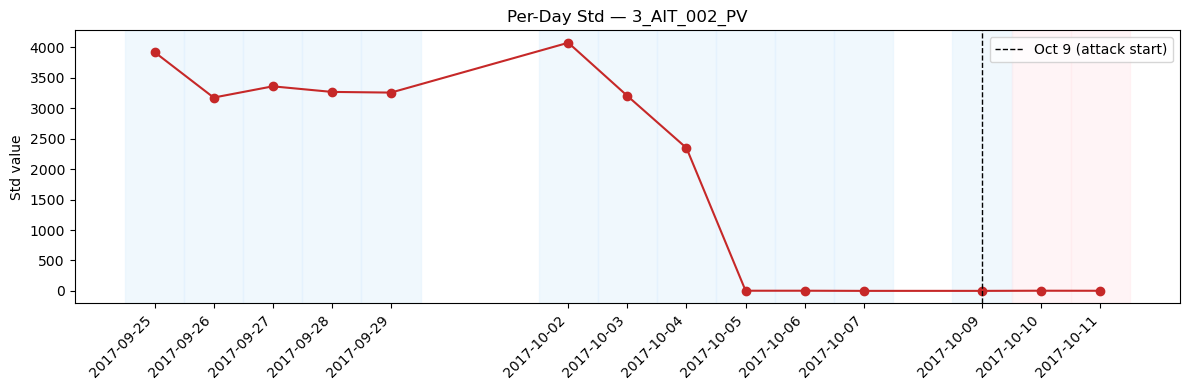

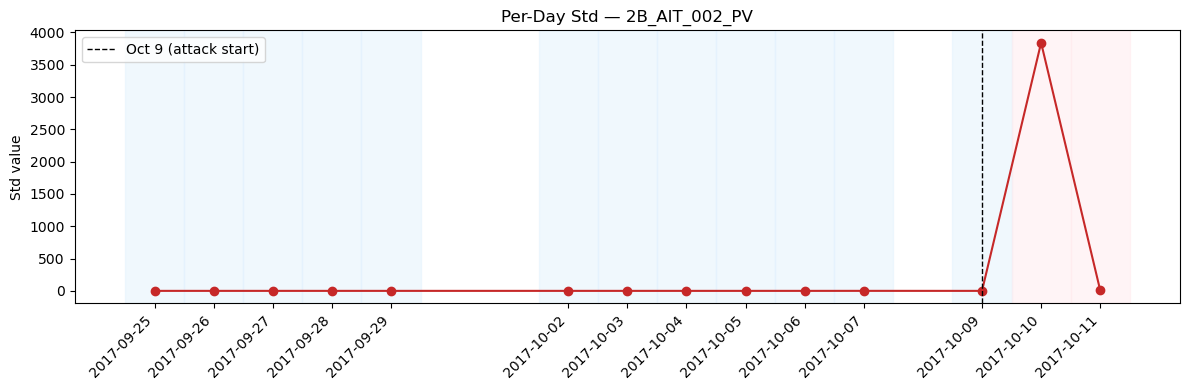

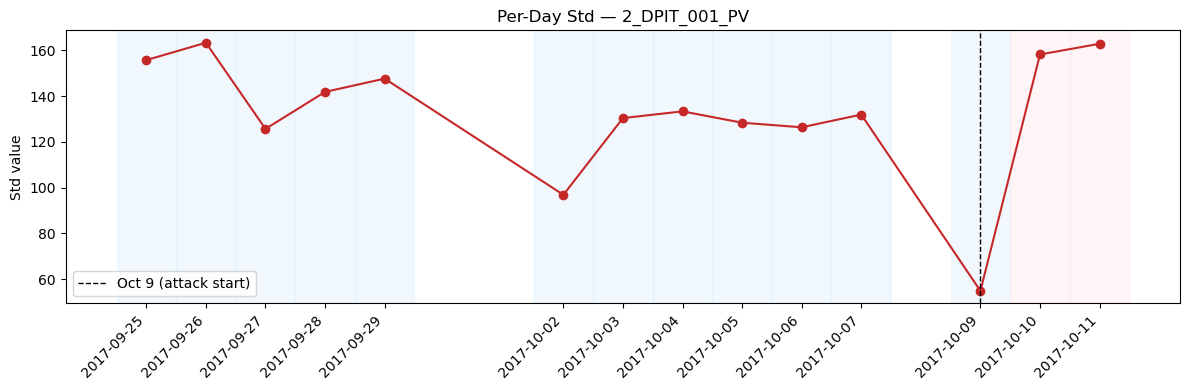

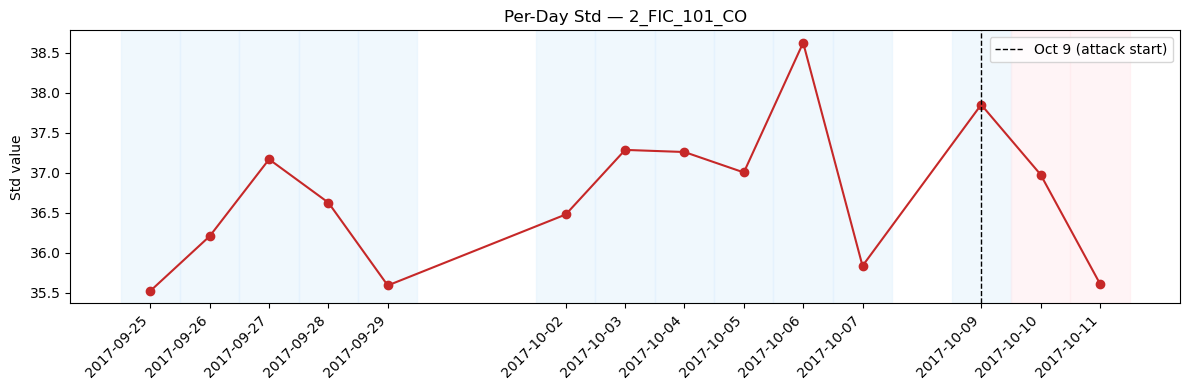

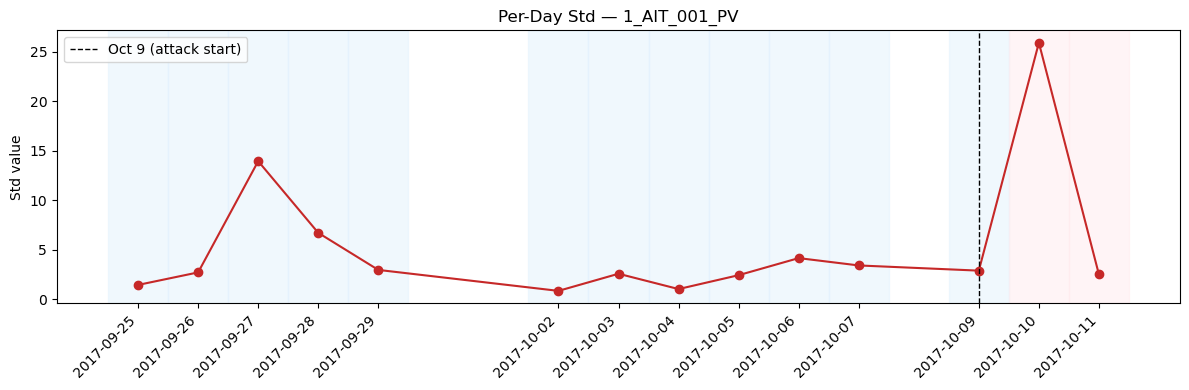

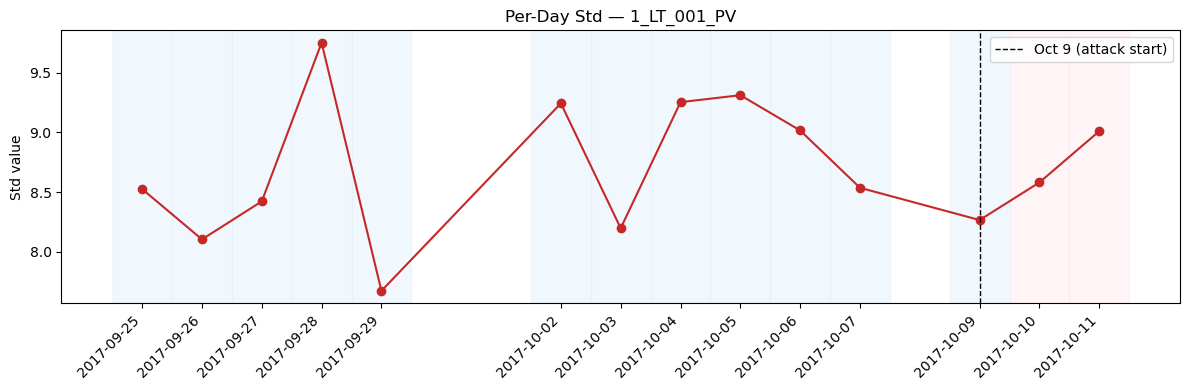

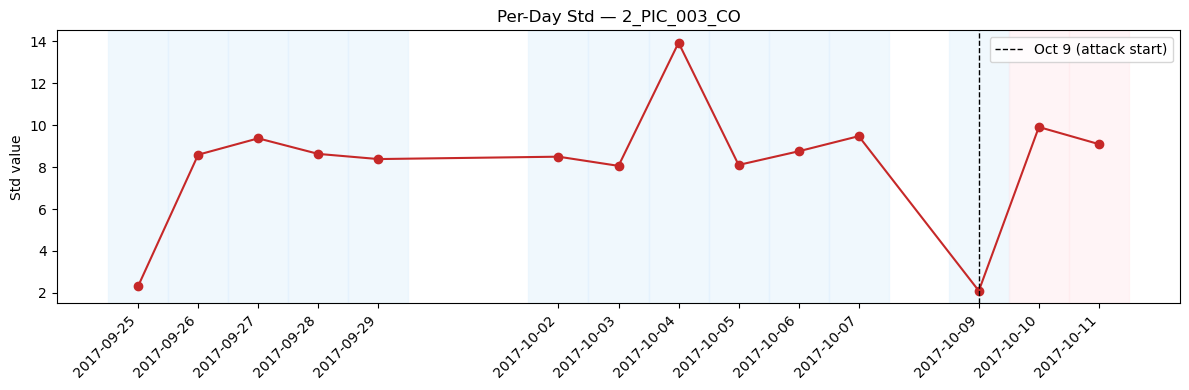

In [14]:
for sensor in REPRESENTATIVE_SENSORS:
    sensor_df = per_day_df[per_day_df["sensor"] == sensor].sort_values("date")

    fig, ax = plt.subplots(figsize=(12, 4))

    for _, row in sensor_df.iterrows():
        color = "#FFEBEE" if row["split"] == "test" else "#E3F2FD"
        ax.axvspan(
            row["date"].toordinal() - 0.5,
            row["date"].toordinal() + 0.5,
            color=color, alpha=0.5, zorder=0
        )

    ax.plot(
        [d.toordinal() for d in sensor_df["date"]],
        sensor_df["std"],
        marker="o", color="#C62828", linewidth=1.5
    )

    oct9 = pd.Timestamp("2017-10-09").toordinal()
    ax.axvline(oct9, color="black", linestyle="--", linewidth=1, label="Oct 9 (attack start)")

    ax.set_xticks([d.toordinal() for d in sensor_df["date"]])
    ax.set_xticklabels([str(d) for d in sensor_df["date"]], rotation=45, ha="right")
    ax.set_title(f"Per-Day Std — {sensor}")
    ax.set_ylabel("Std value")
    ax.legend()

    plt.tight_layout()
    plt.show()
    save_fig(fig, f"eda_daily_std_{sensor}.png")

## 3.4 Analysis

- **`3_AIT_002_PV` shows a dramatic std decrease** across the train period — from
  ~4000 in early blocks to near zero by Oct 5. Combined with the rising mean seen
  in 3.3, this sensor appears to converge to a fixed high value by mid-October.
  This is anomalous behavior within the normal period and is unrelated to attacks.
- **`2B_AIT_002_PV` confirms attack sensitivity** — near-zero std throughout all
  train blocks, then a massive spike on Oct 10 (~3800). High within-day variability
  during the attack period is consistent with an attack directly manipulating this
  sensor.
- **`1_AIT_001_PV` shows elevated std in early train blocks** (Sept 27-28) that
  settles down before spiking again on Oct 10. May reflect both early system
  instability and later attack response.
- **`2_DPIT_001_PV`, `1_LT_001_PV`, `2_FIC_101_CO`, `2_PIC_003_CO`** show
  relatively stable std across both train and test periods. These sensors are
  less sensitive to the attack window.
- **Key implication:** Std behavior is highly sensor-specific. Some sensors show
  within-train instability (`3_AIT_002_PV`) that is unrelated to attacks, while
  others are stable in training but spike during attacks (`2B_AIT_002_PV`,
  `1_AIT_001_PV`). This heterogeneity motivates per-sensor analysis in fault
  injection design.

## 3.1b Random Sensor Sample

To complement the high-variance representative sensors selected in 3.1, we select
10 sensors at random from the 78 eligible sensors. This provides an unbiased view
of typical sensor behavior across the dataset without cherry-picking sensors most
likely to show dramatic shifts. A fixed random seed ensures reproducibility.

In [15]:
import random
random.seed(42)

RANDOM_SENSORS = random.sample(eligible, 10)

print(f"Random sensors selected: {len(RANDOM_SENSORS)}")
for s in RANDOM_SENSORS:
    print(f"  {s:30s}  std={train_df[s].std():.4f}")

Random sensors selected: 10
  2_FIC_201_PV                    std=0.1180
  1_AIT_004_PV                    std=22.2426
  2_FQ_501_PV                     std=0.1345
  2_FQ_101_PV                     std=0.1441
  2_FIT_001_PV                    std=0.9372
  2_FIC_301_PV                    std=0.1159
  2_FIC_201_CO                    std=37.3479
  3_AIT_001_PV                    std=0.0243
  2_FIC_101_PV                    std=0.1442
  2_P_003_SPEED                   std=8.0297


### 3.1b Analysis

- **10 sensors selected randomly** from the 78 eligible sensors (seed=42).
- **Variance is mostly low** — 7 of 10 sensors have std < 1.0, which is much more
  representative of the typical sensor in this dataset than the high-variance set
  selected in 3.1.
- **Two moderate-variance sensors:** `1_AIT_004_PV` (std=22) and `2_FIC_201_CO`
  (std=37) fall in the mid-range of the eligible sensor variance spectrum.
- **One very low variance sensor:** `3_AIT_001_PV` (std=0.024) is near the eligibility
  threshold — it passed the filter but is close to constant.
- This set gives a more honest picture of typical dataset behavior and will serve
  as a useful contrast to the high-variance findings in 3.3 and 3.4.

## 3.2b Per-Day Statistics — Random Sensor Sample

Compute per-block summary statistics for the random sensor sample, using the same
approach as 3.2. This allows direct comparison of typical sensor behavior against
the high-variance sensors examined earlier.

In [16]:
per_day_stats_random = []

for block_id, block_df in df_sorted.groupby("block_id"):
    date = block_df["timestamp"].min().date()
    split = block_df["split"].iloc[0]
    for sensor in RANDOM_SENSORS:
        vals = block_df[sensor].dropna()
        per_day_stats_random.append({
            "block_id": block_id,
            "date":     date,
            "split":    split,
            "sensor":   sensor,
            "mean":     vals.mean(),
            "median":   vals.median(),
            "std":      vals.std(),
            "p95":      vals.quantile(0.95),
        })

per_day_df_random = pd.DataFrame(per_day_stats_random)
print(per_day_df_random.head(20).to_string(index=False))

 block_id       date split        sensor       mean     median       std        p95
        0 2017-09-25 train  2_FIC_201_PV   0.083781   0.052144  0.047495   0.128456
        0 2017-09-25 train  1_AIT_004_PV 499.924042 503.752014  7.828709 506.963013
        0 2017-09-25 train   2_FQ_501_PV   0.066883   0.029173  0.059977   0.129915
        0 2017-09-25 train   2_FQ_101_PV   0.079133   0.093171  0.064276   0.153189
        0 2017-09-25 train  2_FIT_001_PV   0.432593   0.000000  0.887050   2.273130
        0 2017-09-25 train  2_FIC_301_PV   0.072531   0.040140  0.044580   0.117847
        0 2017-09-25 train  2_FIC_201_CO  61.807819  34.050800 35.908947 100.000000
        0 2017-09-25 train  3_AIT_001_PV   0.000000   0.000000  0.000000   0.000000
        0 2017-09-25 train  2_FIC_101_PV   0.079122   0.093286  0.064265   0.153195
        0 2017-09-25 train 2_P_003_SPEED   0.402950  -0.013182  3.546782  -0.011486
        1 2017-09-26 train  2_FIC_201_PV   0.122301   0.062380  0.138394   0

## 3.3b Per-Day Mean Plot — Random Sensor Sample

Per-day mean plots for the randomly selected sensors. These serve as an unbiased
comparison against the high-variance sensors in 3.3, showing what typical sensor
behavior looks like across the recording period.

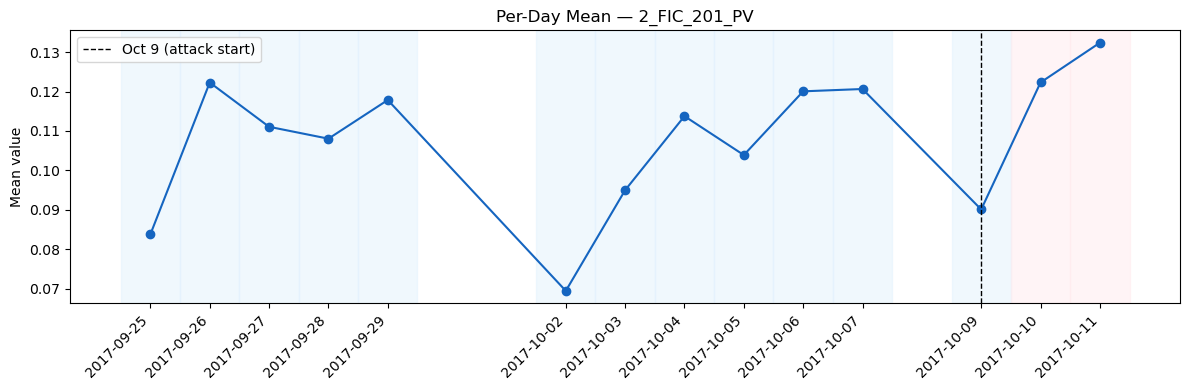

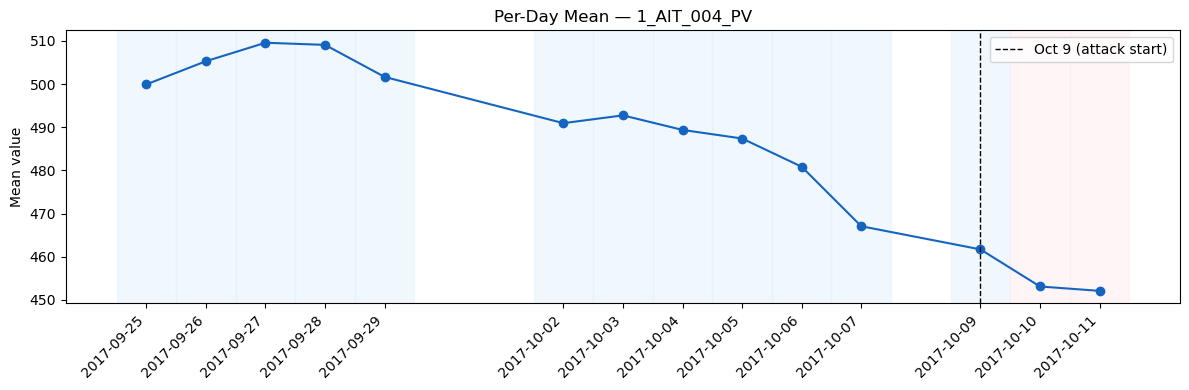

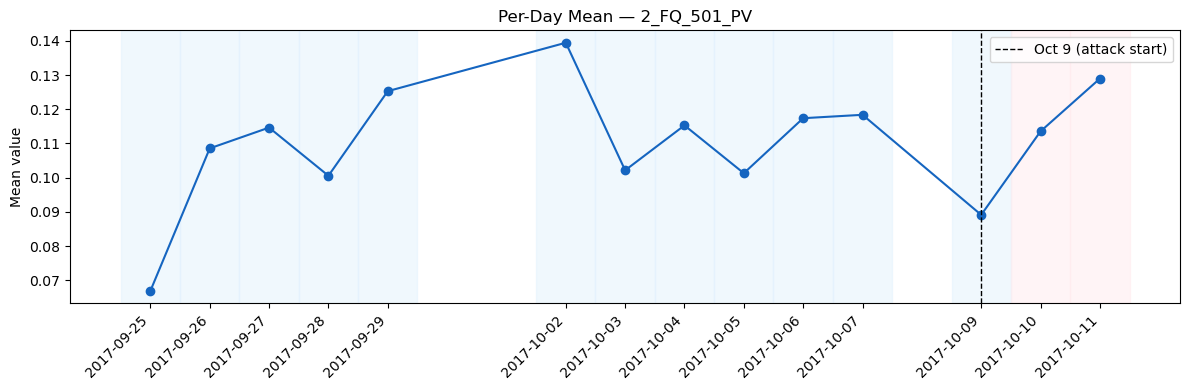

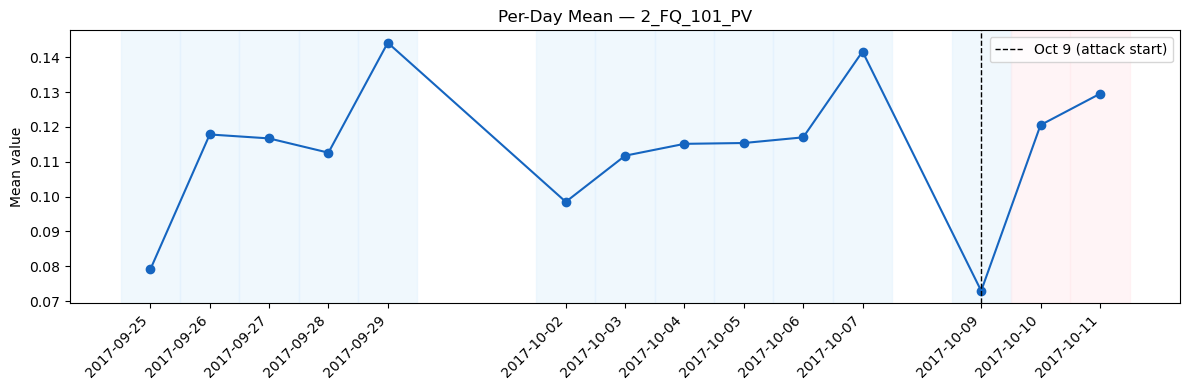

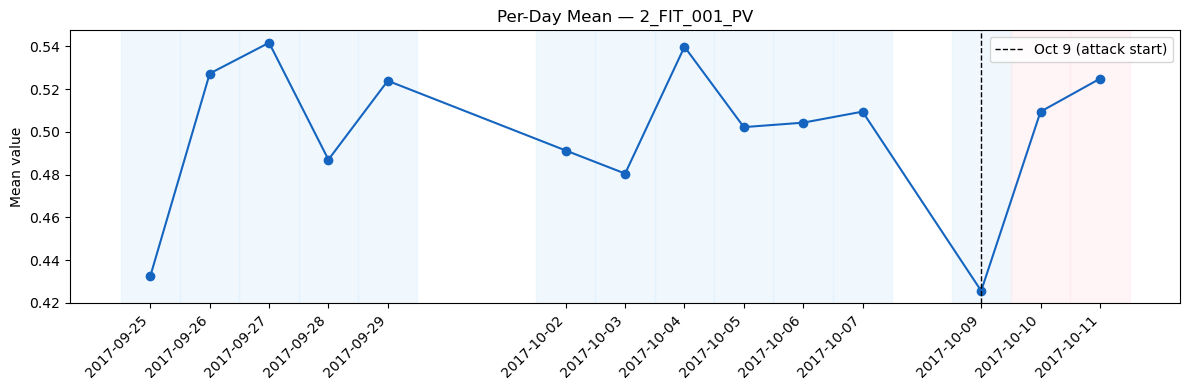

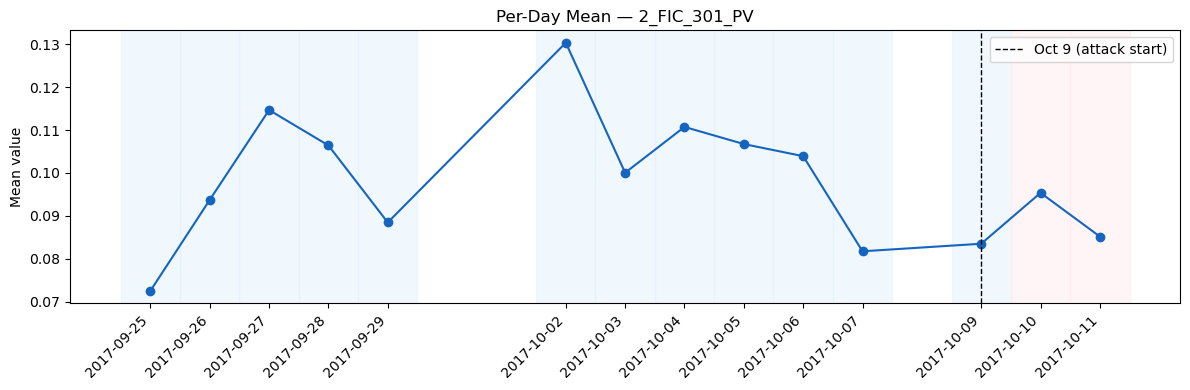

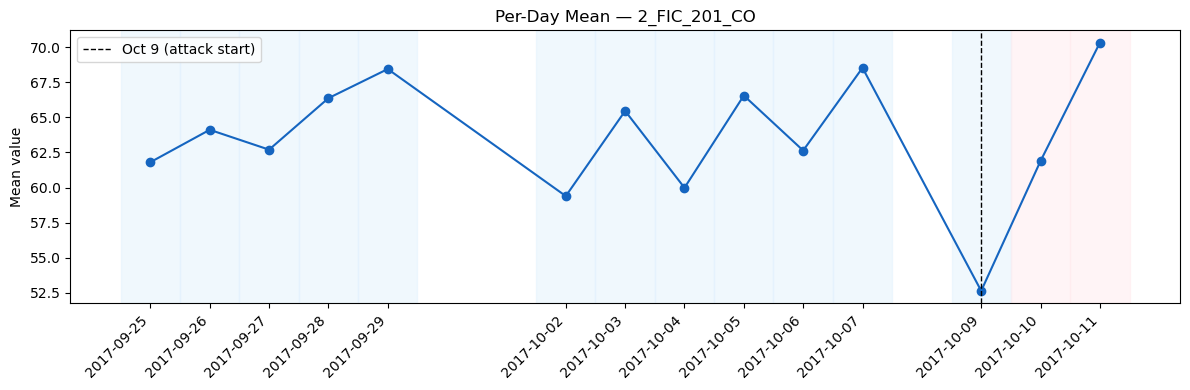

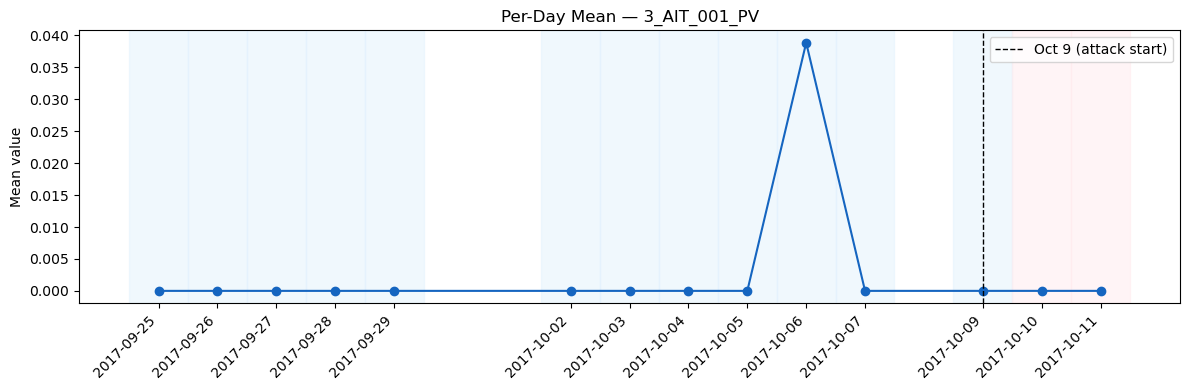

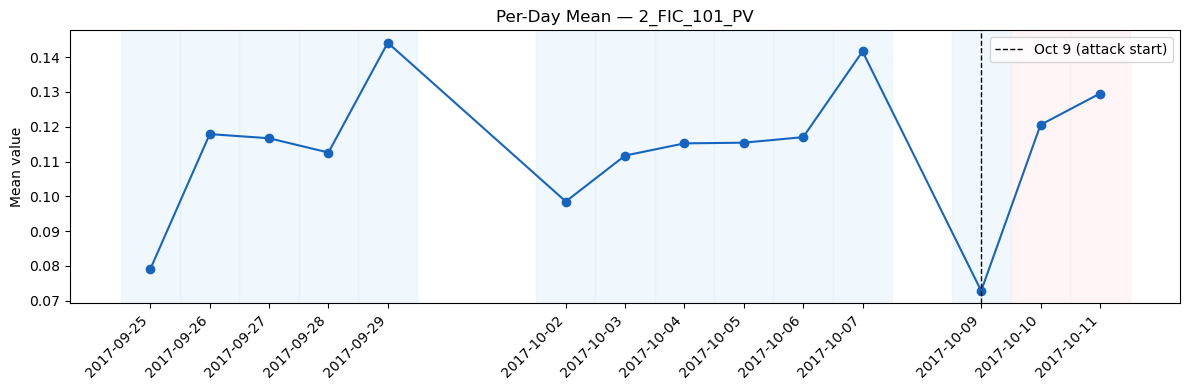

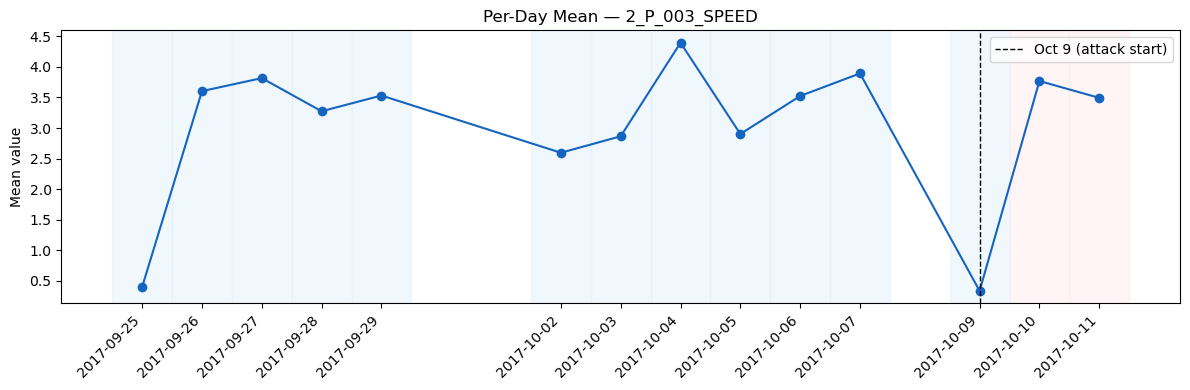

In [17]:
for sensor in RANDOM_SENSORS:
    sensor_df = per_day_df_random[per_day_df_random["sensor"] == sensor].sort_values("date")

    fig, ax = plt.subplots(figsize=(12, 4))

    for _, row in sensor_df.iterrows():
        color = "#FFEBEE" if row["split"] == "test" else "#E3F2FD"
        ax.axvspan(
            row["date"].toordinal() - 0.5,
            row["date"].toordinal() + 0.5,
            color=color, alpha=0.5, zorder=0
        )

    ax.plot(
        [d.toordinal() for d in sensor_df["date"]],
        sensor_df["mean"],
        marker="o", color="#1565C0", linewidth=1.5
    )

    oct9 = pd.Timestamp("2017-10-09").toordinal()
    ax.axvline(oct9, color="black", linestyle="--", linewidth=1, label="Oct 9 (attack start)")

    ax.set_xticks([d.toordinal() for d in sensor_df["date"]])
    ax.set_xticklabels([str(d) for d in sensor_df["date"]], rotation=45, ha="right")
    ax.set_title(f"Per-Day Mean — {sensor}")
    ax.set_ylabel("Mean value")
    ax.legend()

    plt.tight_layout()
    plt.show()
    save_fig(fig, f"eda_daily_means_random_{sensor}.png")

## 3.3b Analysis

- **Gradual drift is not limited to high-variance sensors** — `1_AIT_004_PV` shows
  a clear steady downward trend from ~500 to ~453 across the full recording period.
  This is a typical sensor exhibiting genuine long-term drift unrelated to attacks.
- **Most random sensors show day-to-day variability with no directional trend** —
  values fluctuate within a consistent range across train blocks and test period
  values generally fall within the training range.
- **Oct 9 dip is visible across multiple sensors** — many sensors show a local
  minimum on Oct 9 before recovering. This may reflect system state changes at
  the start of the attack period rather than the attacks themselves.
- **`3_AIT_001_PV` shows an unexplained spike on Oct 6** — near-zero for all other
  days. This anomaly occurs within the normal train period and has no obvious
  explanation. Worth flagging for fault injection design in NB3.
- **Contrast with high-variance set:** The random sample confirms that dramatic
  drift like `3_AIT_002_PV` and attack sensitivity like `2B_AIT_002_PV` are
  not typical. Most sensors are well-behaved with only modest day-to-day variation.

## 3.4b Per-Day Std Plot — Random Sensor Sample

Per-day standard deviation plots for the randomly selected sensors. Complements
3.4 by showing whether within-day variability changes across the recording period
for typical sensors, compared to the dramatic patterns seen in the high-variance set.

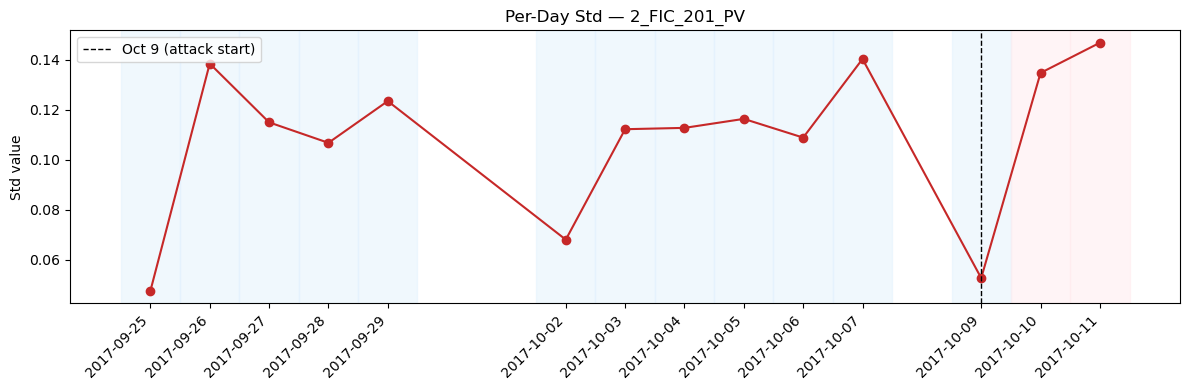

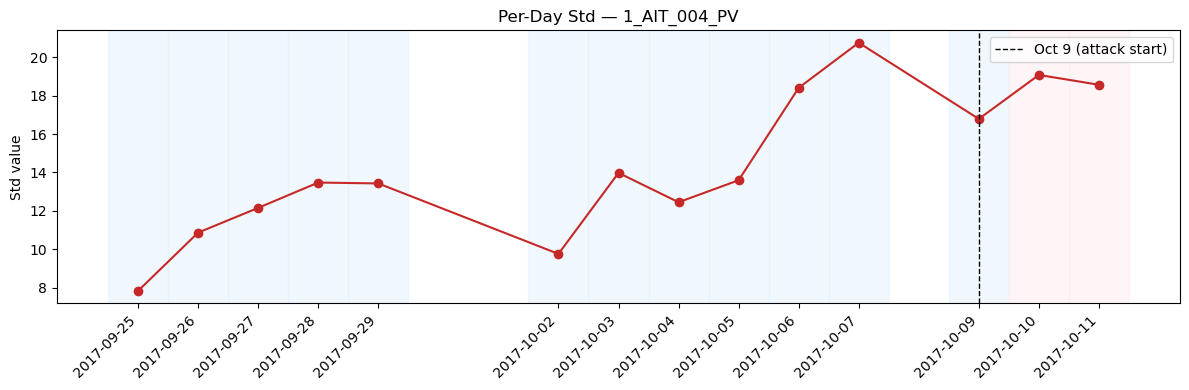

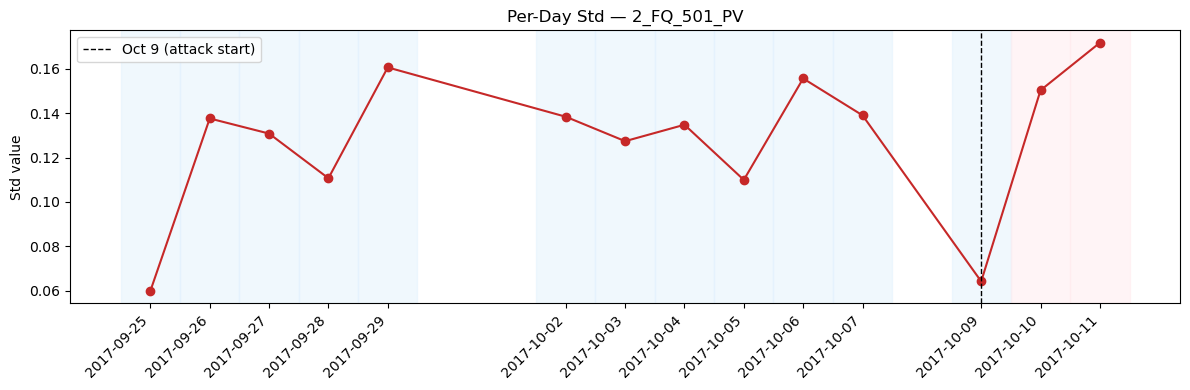

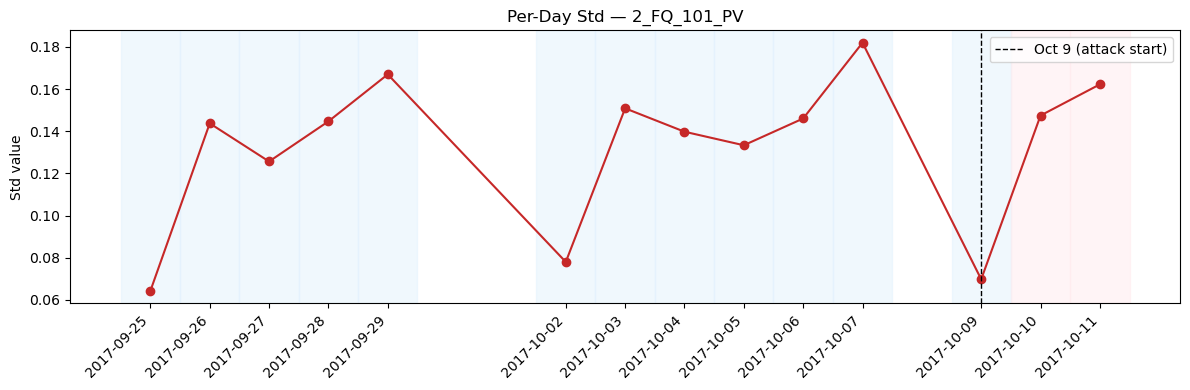

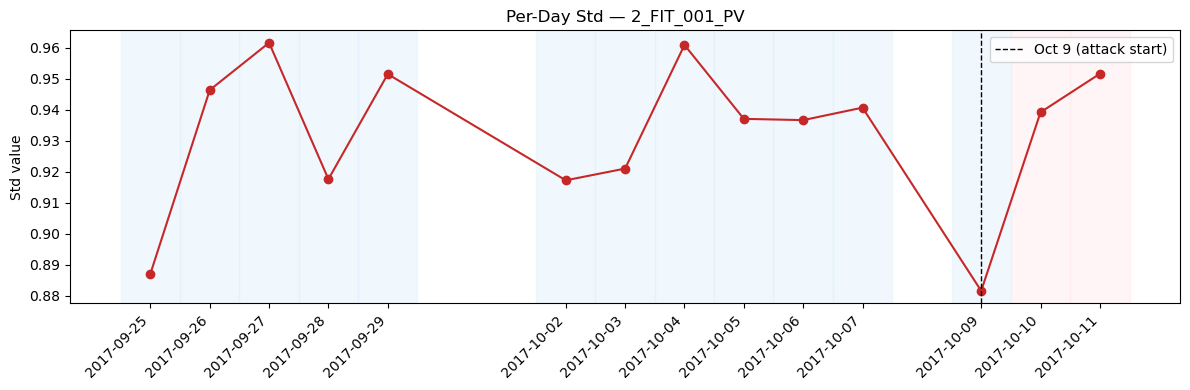

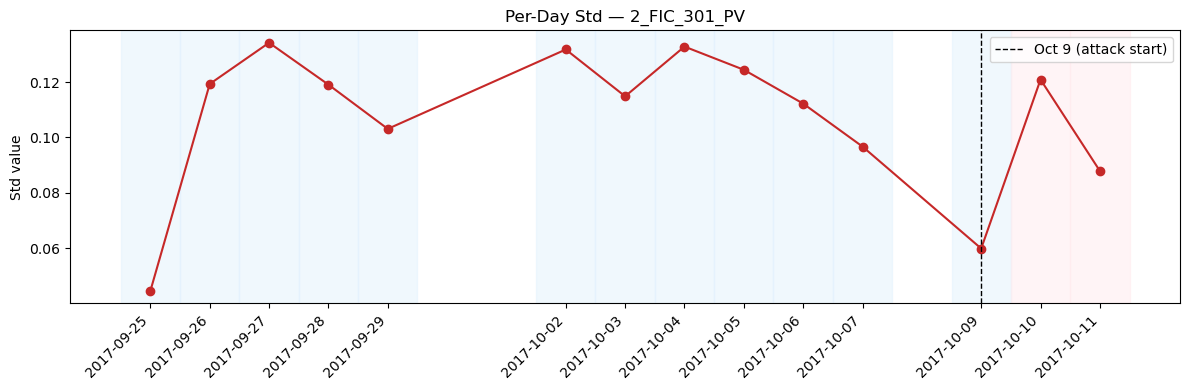

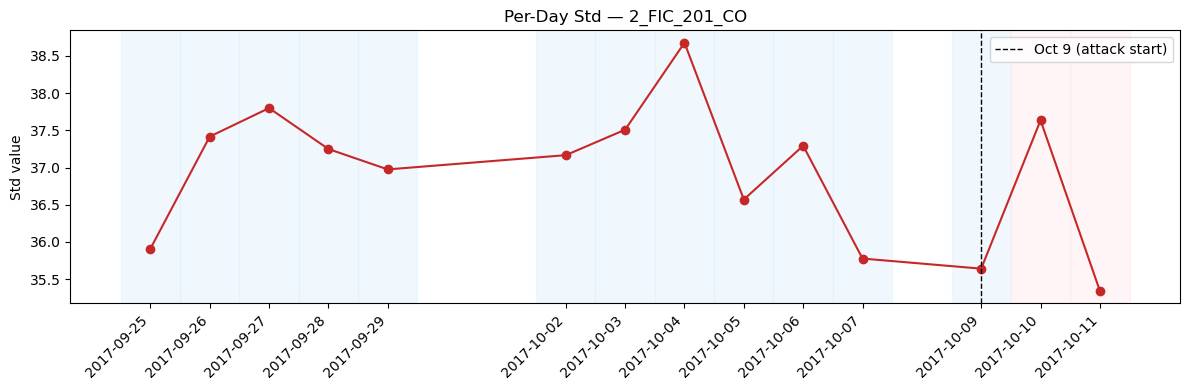

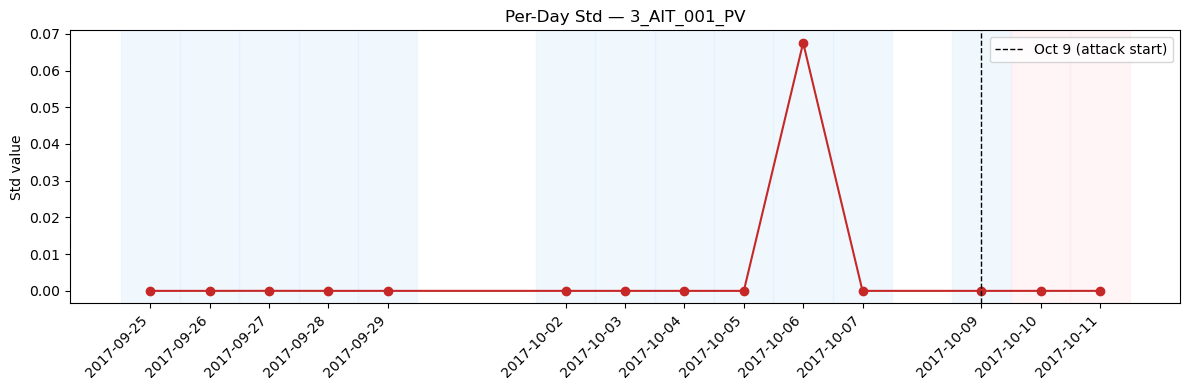

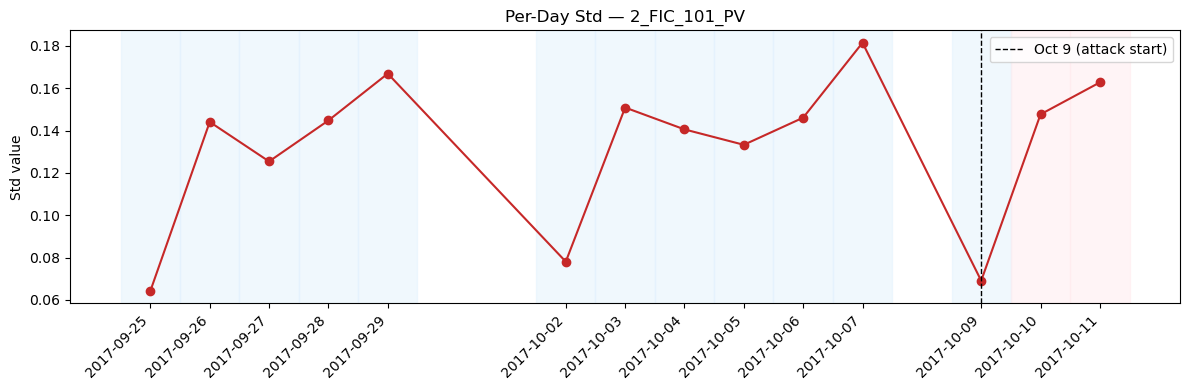

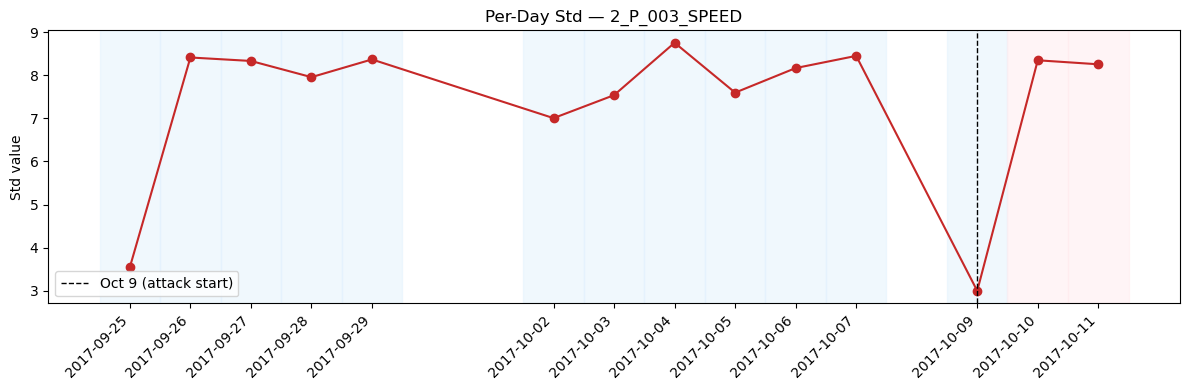

In [18]:
for sensor in RANDOM_SENSORS:
    sensor_df = per_day_df_random[per_day_df_random["sensor"] == sensor].sort_values("date")

    fig, ax = plt.subplots(figsize=(12, 4))

    for _, row in sensor_df.iterrows():
        color = "#FFEBEE" if row["split"] == "test" else "#E3F2FD"
        ax.axvspan(
            row["date"].toordinal() - 0.5,
            row["date"].toordinal() + 0.5,
            color=color, alpha=0.5, zorder=0
        )

    ax.plot(
        [d.toordinal() for d in sensor_df["date"]],
        sensor_df["std"],
        marker="o", color="#C62828", linewidth=1.5
    )

    oct9 = pd.Timestamp("2017-10-09").toordinal()
    ax.axvline(oct9, color="black", linestyle="--", linewidth=1, label="Oct 9 (attack start)")

    ax.set_xticks([d.toordinal() for d in sensor_df["date"]])
    ax.set_xticklabels([str(d) for d in sensor_df["date"]], rotation=45, ha="right")
    ax.set_title(f"Per-Day Std — {sensor}")
    ax.set_ylabel("Std value")
    ax.legend()

    plt.tight_layout()
    plt.show()
    save_fig(fig, f"eda_daily_std_random_{sensor}.png")

### 3.4b Analysis

- **The Oct 9 std dip is a dataset-wide phenomenon** — nearly every random sensor
  shows a sharp minimum on Oct 9 before recovering in the test period. This suggests
  the system enters an unusually stable or suppressed state at the start of the attack
  window, independent of whether individual rows are labeled as attacks. This is an
  important structural characteristic of the dataset.
- **`1_AIT_004_PV` shows correlated mean and std drift** — both decrease together
  across the recording period. This sensor's behavior is changing in a coordinated
  way, consistent with a slow physical process rather than noise.
- **`3_AIT_001_PV` confirms the Oct 6 anomaly** — isolated spike in both mean and
  std on a single normal train day, zero everywhere else. This is unexplained and
  worth flagging for NB3 fault injection design.
- **All other random sensors show bounded, non-directional fluctuation** — std
  values in the test period fall within the range observed during training. No
  dramatic attack-driven std changes visible in this typical sensor sample.
- **Contrast with high-variance set:** The random sample confirms that dramatic
  std behavior like `3_AIT_002_PV` (collapsing from 4000 to near zero) and
  `2B_AIT_002_PV` (exploding to 3800 during attacks) are outliers, not typical
  dataset behavior.
- **The universal Oct 9 dip is a key finding** — it will be revisited in Section 7
  when evaluating normalization strategy, as it suggests a systematic state change
  at the train/test boundary that affects all sensors simultaneously.

## 3.5 Distribution Shift Quantification

Quantify how different each daily block is from the training baseline. For each
block, compute the mean absolute deviation from the overall training mean across
representative sensors. This gives a single number per block that summarizes
how far that day's sensor behavior is from what the model will learn as normal.
The training baseline is computed from train blocks only.

In [19]:
train_baseline_mean = df_sorted[df_sorted["split"] == "train"][REPRESENTATIVE_SENSORS].mean()

shift_results = []
for block_id, block_df in df_sorted.groupby("block_id"):
    date = block_df["timestamp"].min().date()
    split = block_df["split"].iloc[0]
    shift = (block_df[REPRESENTATIVE_SENSORS].mean() - train_baseline_mean).abs().mean()
    shift_results.append({
        "block_id":   block_id,
        "date":       date,
        "split":      split,
        "mean_shift": round(float(shift), 4),
    })

shift_df = pd.DataFrame(shift_results)
print(shift_df.to_string(index=False))

 block_id       date split  mean_shift
        0 2017-09-25 train    320.6606
        1 2017-09-26 train    201.7815
        2 2017-09-27 train    244.2434
        3 2017-09-28 train    154.0011
        4 2017-09-29 train    178.8138
        5 2017-10-02 train    411.5483
        6 2017-10-03 train    142.2910
        7 2017-10-04 train    132.5751
        8 2017-10-05 train    238.0063
        9 2017-10-06 train    235.1001
       10 2017-10-07 train    235.8774
       11 2017-10-09 train    237.8029
       12 2017-10-10  test    481.2538
       13 2017-10-11  test   1245.2450


In [20]:
train_baseline_mean_random = df_sorted[df_sorted["split"] == "train"][RANDOM_SENSORS].mean()

shift_results_random = []
for block_id, block_df in df_sorted.groupby("block_id"):
    date = block_df["timestamp"].min().date()
    split = block_df["split"].iloc[0]
    shift = (block_df[RANDOM_SENSORS].mean() - train_baseline_mean_random).abs().mean()
    shift_results_random.append({
        "block_id":   block_id,
        "date":       date,
        "split":      split,
        "mean_shift": round(float(shift), 4),
    })

shift_df_random = pd.DataFrame(shift_results_random)

# Display both side by side
comparison = shift_df.merge(shift_df_random, on=["block_id", "date", "split"], suffixes=("_highvar", "_random"))
print(comparison.to_string(index=False))

 block_id       date split  mean_shift_highvar  mean_shift_random
        0 2017-09-25 train            320.6606             1.5662
        1 2017-09-26 train            201.7815             1.5854
        2 2017-09-27 train            244.2434             2.1779
        3 2017-09-28 train            154.0011             2.0658
        4 2017-09-29 train            178.8138             1.5501
        5 2017-10-02 train            411.5483             0.6798
        6 2017-10-03 train            142.2910             0.3841
        7 2017-10-04 train            132.5751             0.6668
        8 2017-10-05 train            238.0063             0.5277
        9 2017-10-06 train            235.1001             1.1678
       10 2017-10-07 train            235.8774             2.7769
       11 2017-10-09 train            237.8029             4.3798
       12 2017-10-10  test            481.2538             4.0381
       13 2017-10-11  test           1245.2450             4.4142


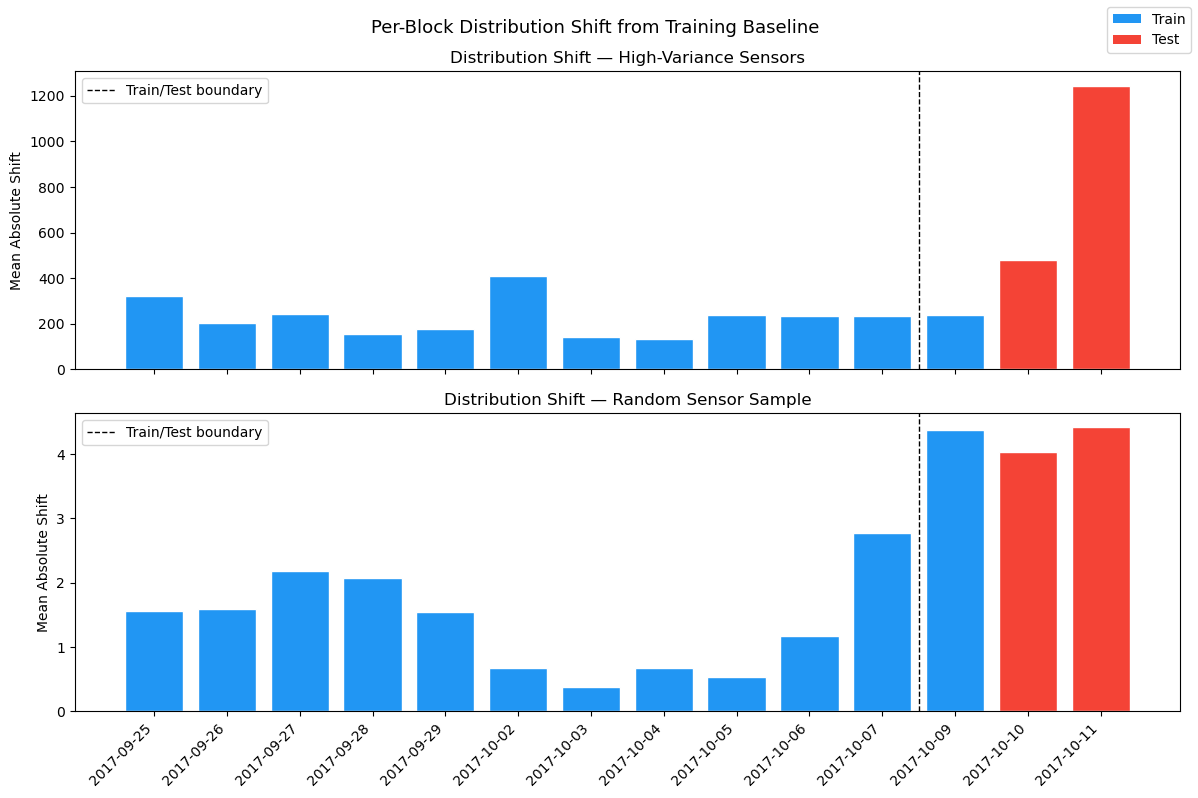

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

colors = ["#2196F3" if s == "train" else "#F44336" for s in comparison["split"]]
x = range(len(comparison))
labels = [str(d) for d in comparison["date"]]

# High-variance sensors
axes[0].bar(x, comparison["mean_shift_highvar"], color=colors, edgecolor="white")
axes[0].set_title("Distribution Shift — High-Variance Sensors")
axes[0].set_ylabel("Mean Absolute Shift")
axes[0].axvline(10.5, color="black", linestyle="--", linewidth=1, label="Train/Test boundary")
axes[0].legend()

# Random sensors
axes[1].bar(x, comparison["mean_shift_random"], color=colors, edgecolor="white")
axes[1].set_title("Distribution Shift — Random Sensor Sample")
axes[1].set_ylabel("Mean Absolute Shift")
axes[1].axvline(10.5, color="black", linestyle="--", linewidth=1, label="Train/Test boundary")
axes[1].legend()

# Shared x axis
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels, rotation=45, ha="right")

# Legend for split colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", label="Train"),
    Patch(facecolor="#F44336", label="Test"),
]
fig.legend(handles=legend_elements, loc="upper right")

plt.suptitle("Per-Block Distribution Shift from Training Baseline", fontsize=13)
plt.tight_layout()
plt.show()
save_fig(fig, "eda_distribution_shift.png")

### 3.5 Analysis

- **Distribution shift is sensor-dependent, not dataset-wide.** The two panels
  tell completely different stories:
  - High-variance sensors show large, inconsistent shifts across all train blocks
    (range: 132–411) with test blocks elevated but partly explained by within-train
    variation. Oct 11 reaches 1245, driven almost entirely by `2B_AIT_002_PV`
    responding directly to attacks.
  - Random sensors show minimal shift throughout (train range: 0.38–2.78). Test
    block shifts (4.04, 4.41) are only marginally above the highest train block
    (4.38 on Oct 9) — barely distinguishable from normal training variation.
- **The high-variance shift numbers are misleading** — dominated by two sensors
  with extreme raw value ranges. Without normalization their absolute deviations
  dwarf all other sensors.
- **For typical sensors, the train/test boundary is not a dramatic shift** — the
  system state on Oct 10–11 is broadly consistent with training for most sensors.
- **Oct 9 is the highest train block in the random sensor set** — consistent with
  the universal std dip observed in 3.4b, something changes system-wide at the
  start of the attack window even within the train split.
- **Implication for normalization:** Train-only StandardScaler should bring sensors
  onto a common scale and substantially reduce the dominance of high-variance
  sensors. Whether this resolves the shift problem will be verified in Section 7.

# Section 4 — Pre-Attack vs Attack-Window Normal Comparison

The train split contains normal rows from Sept 25 – Oct 9. The test split contains
normal rows from Oct 10–11 that were recorded during the attack file but labeled
as normal (label=0). These two normal populations may be genuinely different —
if so, any classifier trained on pre-attack normals will struggle to correctly
identify attack-window normals regardless of model choice.

This section directly tests that hypothesis.

## 4.1 Define the Two Normal Groups

Separate normal rows into two groups: pre-attack normals from the train split,
and attack-window normals from the test split. All rows in both groups have
label=0, the only difference is when they were recorded.

In [42]:
normal_pre_attack    = df_sorted[(df_sorted["label"] == 0) & (df_sorted["split"] == "train")]
normal_attack_window = df_sorted[(df_sorted["label"] == 0) & (df_sorted["split"] == "test")]

print(f"Pre-attack normals:    {len(normal_pre_attack):>7,} rows  ({normal_pre_attack['timestamp'].min().date()} → {normal_pre_attack['timestamp'].max().date()})")
print(f"Attack-window normals: {len(normal_attack_window):>7,} rows  ({normal_attack_window['timestamp'].min().date()} → {normal_attack_window['timestamp'].max().date()})")

Pre-attack normals:    857,509 rows  (2017-09-25 → 2017-10-11)
Attack-window normals:  89,886 rows  (2017-10-10 → 2017-10-11)


## 4.2 Descriptive Comparison

Run descriptive_profile on both normal groups for the representative sensors and
display side by side. A third column showing the mean difference highlights which
sensors diverge most between the two populations.

In [23]:
profile_pre    = descriptive_profile(normal_pre_attack, REPRESENTATIVE_SENSORS)
profile_attack = descriptive_profile(normal_attack_window, REPRESENTATIVE_SENSORS)

mean_diff = (profile_attack["mean"] - profile_pre["mean"]).rename("mean_diff")

comparison_profile = pd.concat([
    profile_pre.add_suffix("_pre"),
    profile_attack.add_suffix("_attack"),
    mean_diff
], axis=1)

print(comparison_profile[["mean_pre", "mean_attack", "mean_diff", "std_pre", "std_attack"]].to_string())

                  mean_pre  mean_attack    mean_diff      std_pre   std_attack
3_AIT_002_PV   7160.639160  8279.101562  1118.462402  2741.831299     4.373510
2B_AIT_002_PV   508.394928  3387.071777  2878.676849  1947.931519  3995.380859
2_DPIT_001_PV  2519.043457  2515.335693    -3.707764   136.095505   153.650711
2_FIC_101_CO     64.586166    65.388168     0.802002    37.144131    36.946285
1_AIT_001_PV    170.328629   175.249176     4.920547    14.422678     4.871330
1_LT_001_PV      56.330559    55.966251    -0.364307     8.820299     8.548567
2_PIC_003_CO     45.955418    45.440811    -0.514606     9.317176     9.732546


## 4.3 Distribution Comparison Plots

Overlaid histograms for each representative sensor comparing pre-attack normals
(blue) vs attack-window normals (orange). Divergence between the two distributions
indicates that the test normal population is genuinely different from what the
model learns as normal during training.

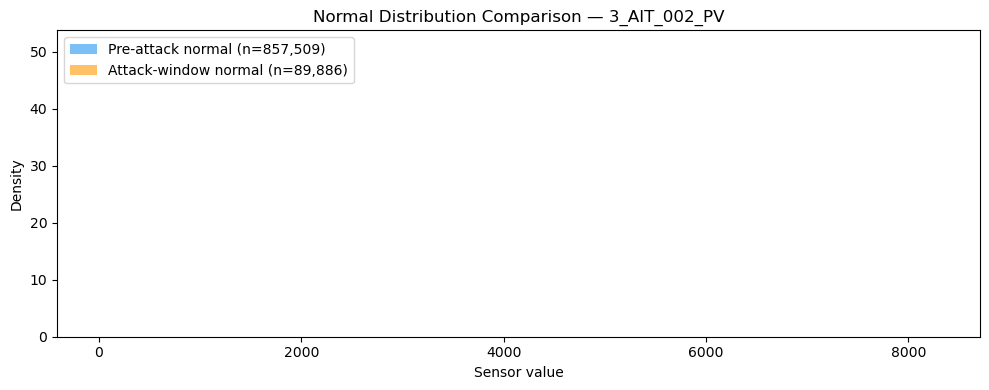

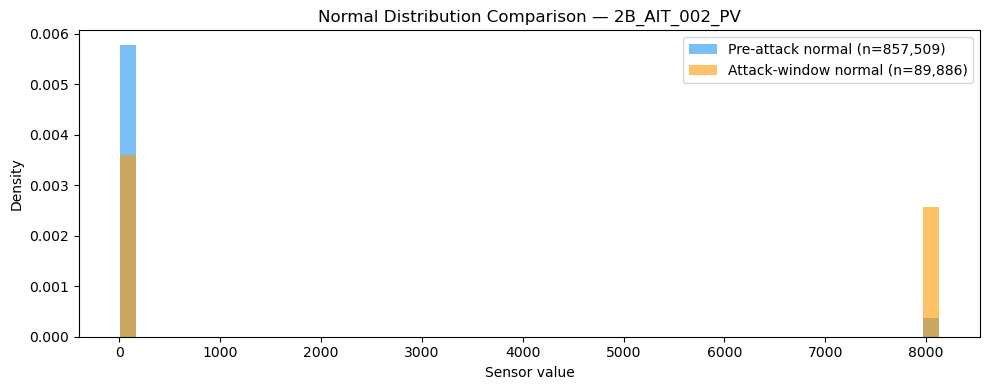

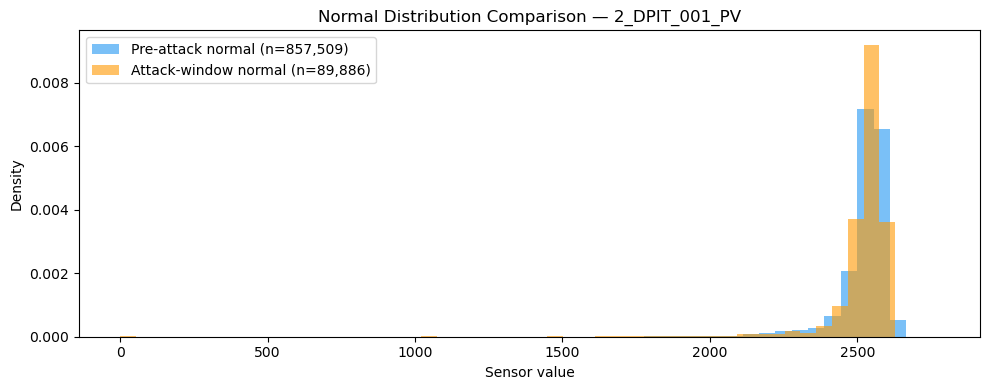

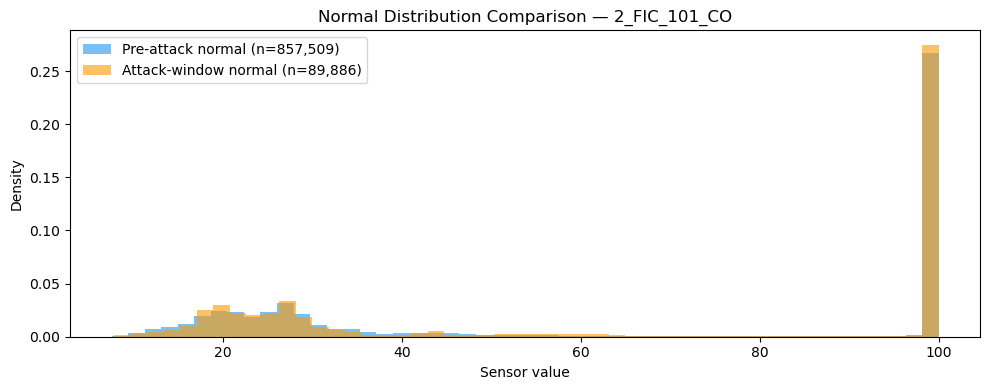

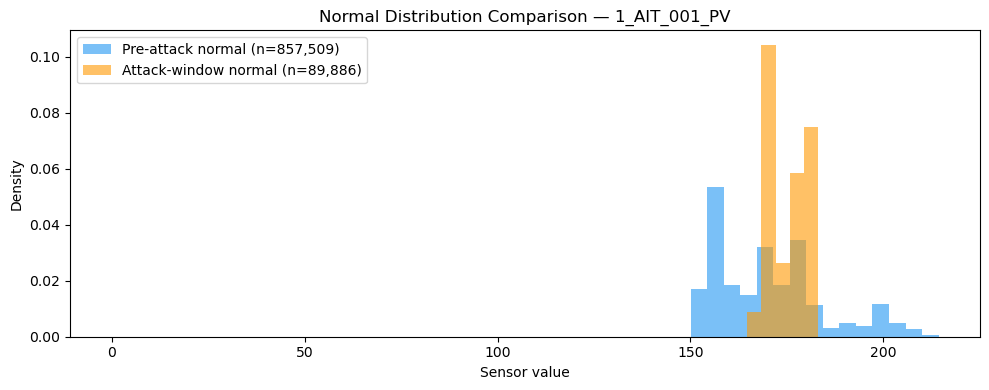

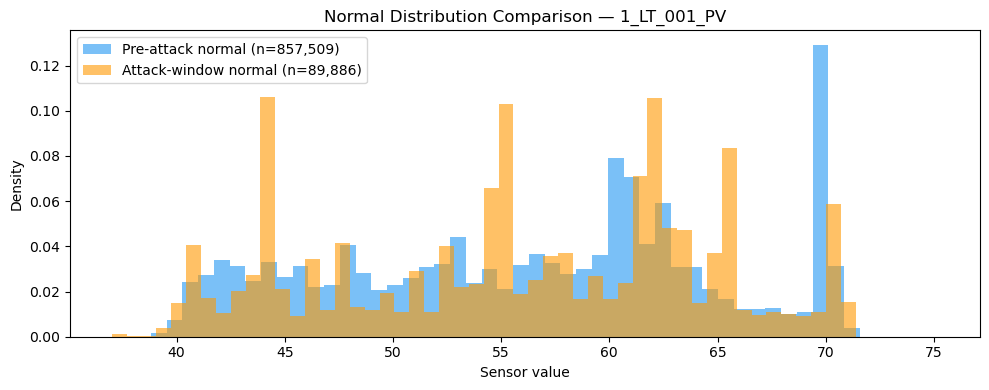

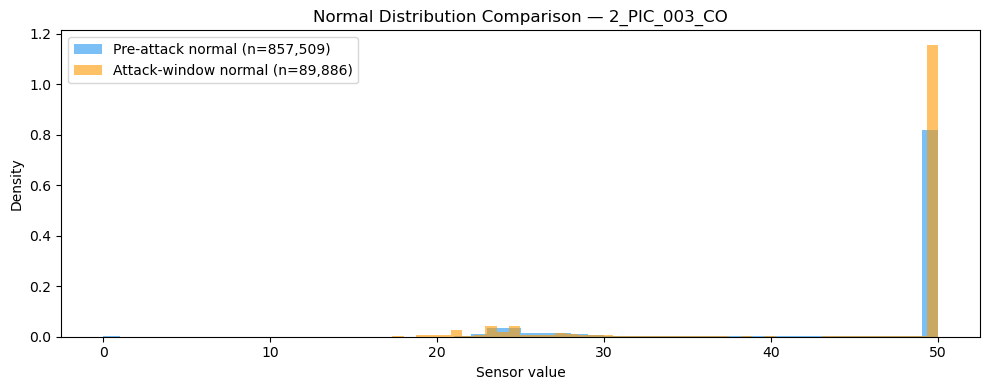

In [24]:
for sensor in REPRESENTATIVE_SENSORS:
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.hist(
        normal_pre_attack[sensor].dropna(),
        bins=50, color="#2196F3", alpha=0.6,
        label=f"Pre-attack normal (n={len(normal_pre_attack):,})",
        density=True
    )
    ax.hist(
        normal_attack_window[sensor].dropna(),
        bins=50, color="#FF9800", alpha=0.6,
        label=f"Attack-window normal (n={len(normal_attack_window):,})",
        density=True
    )

    ax.set_title(f"Normal Distribution Comparison — {sensor}")
    ax.set_xlabel("Sensor value")
    ax.set_ylabel("Density")
    ax.legend()

    plt.tight_layout()
    plt.show()
    save_fig(fig, f"eda_normal_comparison_{sensor}.png")

In [25]:
# Check the attack-window distribution for 3_AIT_002_PV
print(normal_attack_window["3_AIT_002_PV"].describe())
print(f"\nUnique values: {normal_attack_window['3_AIT_002_PV'].nunique()}")

count    89886.000000
mean      8279.101562
std          4.373510
min       8279.099609
25%       8279.099609
50%       8279.099609
75%       8279.099609
max       8279.099609
Name: 3_AIT_002_PV, dtype: float64

Unique values: 1


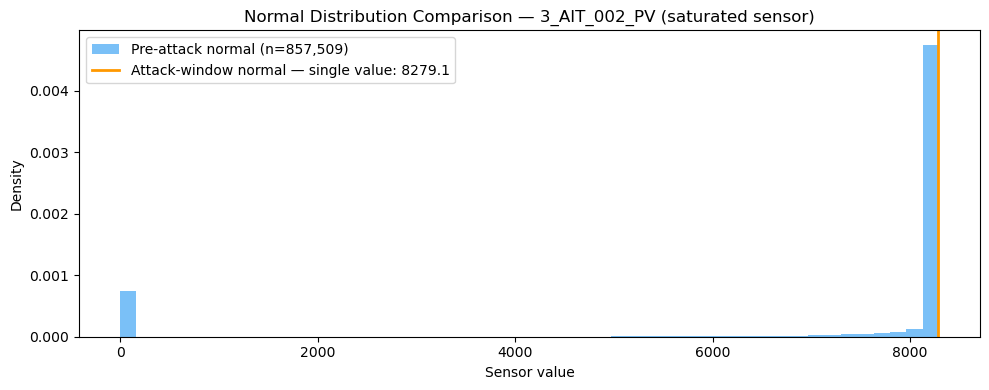

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    normal_pre_attack["3_AIT_002_PV"].dropna(),
    bins=50, color="#2196F3", alpha=0.6,
    label=f"Pre-attack normal (n={len(normal_pre_attack):,})",
    density=True
)
ax.axvline(
    normal_attack_window["3_AIT_002_PV"].iloc[0],
    color="#FF9800", linewidth=2,
    label=f"Attack-window normal — single value: {normal_attack_window['3_AIT_002_PV'].iloc[0]:.1f}"
)

ax.set_title("Normal Distribution Comparison — 3_AIT_002_PV (saturated sensor)")
ax.set_xlabel("Sensor value")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()
save_fig(fig, "eda_normal_comparison_3_AIT_002_PV_fixed.png")

### 4.3 Analysis

- **`2B_AIT_002_PV` shows complete separation** between the two normal populations.
  Pre-attack normals cluster near zero, attack-window normals cluster near 8000.
  There is zero overlap. A model trained on pre-attack normals will never recognize
  attack-window normals as normal for this sensor, it will always flag them as
  anomalous regardless of attack label.
- **`3_AIT_002_PV` has saturated** — every attack-window normal row has exactly
  the same value (8279.1). The sensor hit a physical ceiling during the gradual
  drift observed in Section 3 and is now stuck there. The pre-attack distribution
  is bimodal, reflecting early low values and later high values as the sensor drifted
  upward. This sensor is effectively uninformative in the test period.
- **`1_AIT_001_PV` shows a shifted but overlapping distribution** — attack-window
  normals concentrate at higher values (~170–185) vs the broader pre-attack spread.
  Partial overlap means the model may still generalize partially for this sensor.
- **`2_FIC_101_CO` and `2_PIC_003_CO`** both show a pronounced spike at their
  maximum values (100 and 50 respectively) in the attack-window normals. This
  suggests these sensors are operating at saturation or a control limit more
  frequently during the attack window.
- **`2_DPIT_001_PV` and `1_LT_001_PV`** show broadly similar distributions with
  reasonable overlap, these sensors generalize well across the train/test boundary.
- **This is a direct explanation for poor binary classifier performance on normal
  test rows.** At least two sensors (`2B_AIT_002_PV`, `3_AIT_002_PV`) present
  attack-window normals in regions of feature space the model has never seen as
  normal during training. The model will correctly flag these as anomalous, but
  they are labeled normal, producing false positives that inflate the false positive
  rate regardless of model quality.

In [44]:
stable_sensors = all_sensor_df[
    (all_sensor_df["out_of_range_pct"] == 0.0) & 
    (all_sensor_df["sensor"].str.endswith("PV"))
]["sensor"].tolist()

print(stable_sensors)

['2_LT_001_PV', '2A_AIT_001_PV', '3_AIT_001_PV', '2B_AIT_001_PV', '2A_AIT_003_PV', '3_AIT_002_PV']


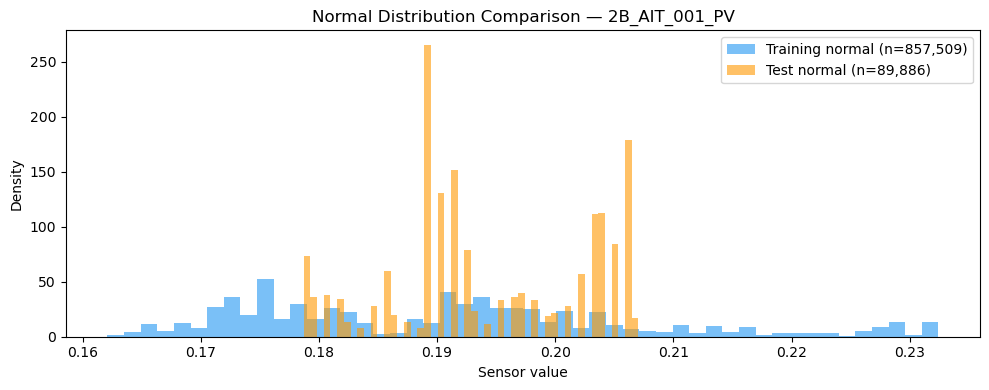

In [47]:
sensor = "2B_AIT_001_PV"
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(normal_pre_attack[sensor].dropna(), bins=50, color="#2196F3", 
        alpha=0.6, label=f"Training normal (n={len(normal_pre_attack):,})", density=True)
ax.hist(normal_attack_window[sensor].dropna(), bins=50, color="#FF9800", 
        alpha=0.6, label=f"Test normal (n={len(normal_attack_window):,})", density=True)
ax.set_title(f"Normal Distribution Comparison — {sensor}")
ax.set_xlabel("Sensor value")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()
save_fig(fig, f"eda_normal_comparison_{sensor}.png")

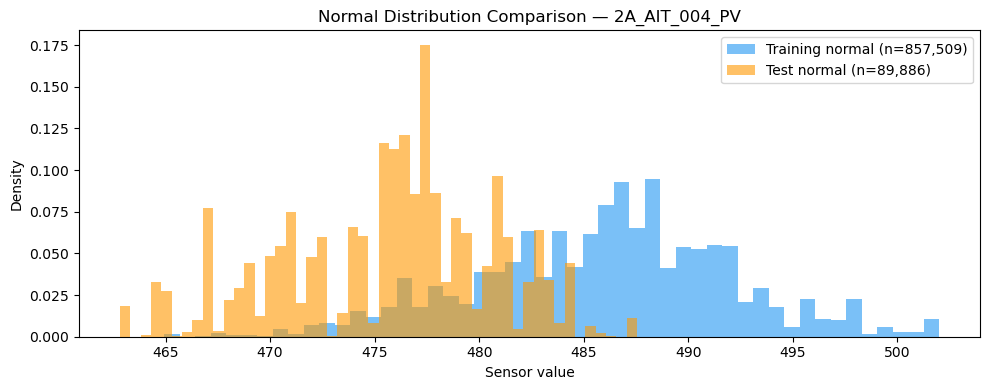

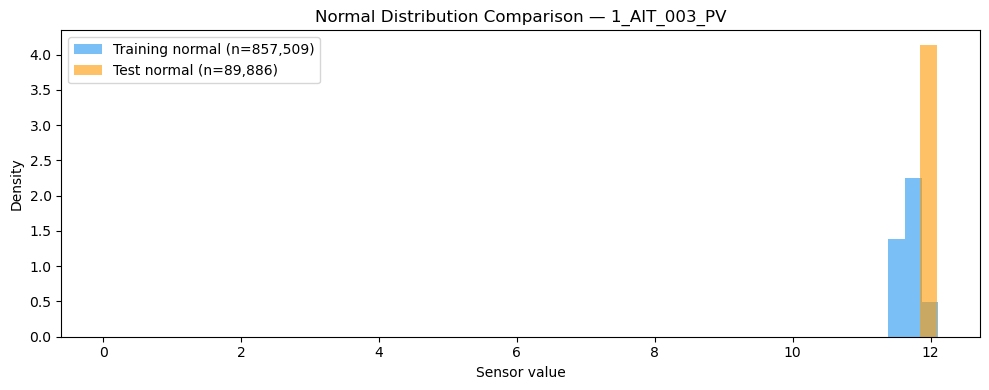

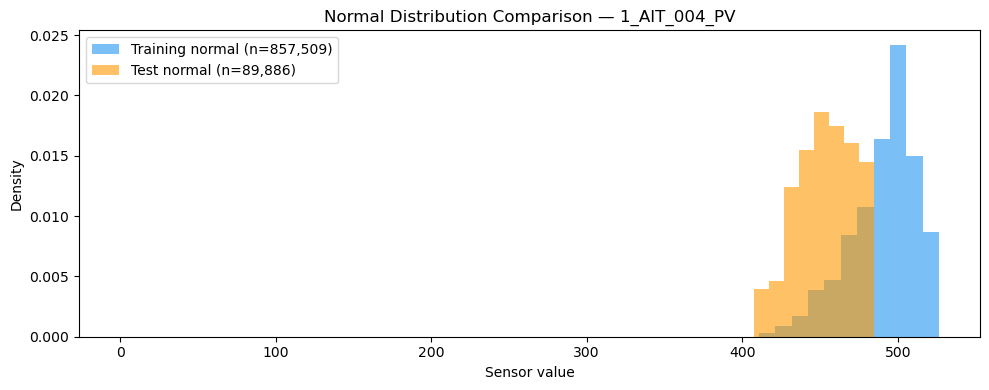

In [43]:
TOP_DRIFT_SENSORS = [
    "2A_AIT_004_PV",
    "1_AIT_003_PV",
    "1_AIT_004_PV",
]

for sensor in TOP_DRIFT_SENSORS:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(
        normal_pre_attack[sensor].dropna(),
        bins=50, color="#2196F3", alpha=0.6,
        label=f"Training normal (n={len(normal_pre_attack):,})",
        density=True
    )
    ax.hist(
        normal_attack_window[sensor].dropna(),
        bins=50, color="#FF9800", alpha=0.6,
        label=f"Test normal (n={len(normal_attack_window):,})",
        density=True
    )
    ax.set_title(f"Normal Distribution Comparison — {sensor}")
    ax.set_xlabel("Sensor value")
    ax.set_ylabel("Density")
    ax.legend()
    plt.tight_layout()
    plt.show()
    save_fig(fig, f"eda_normal_comparison_{sensor}.png")

## 4.4 Statistical Summary

Quantify the separation between the two normal populations for each representative
sensor. Three metrics capture different aspects of the divergence:
- **Mean difference:** raw shift in central tendency
- **Std ratio:** whether variability changes between populations
- **Out-of-range fraction:** proportion of attack-window normal rows that fall
  outside the pre-attack [p1, p99] range, directly measures how many test
  normal rows the model will have never seen during training

In [27]:
summary_rows = []

for sensor in REPRESENTATIVE_SENSORS:
    pre_vals    = normal_pre_attack[sensor].dropna()
    attack_vals = normal_attack_window[sensor].dropna()

    p1  = pre_vals.quantile(0.01)
    p99 = pre_vals.quantile(0.99)

    out_of_range = ((attack_vals < p1) | (attack_vals > p99)).mean()

    summary_rows.append({
        "sensor":           sensor,
        "mean_diff":        round(float(attack_vals.mean() - pre_vals.mean()), 3),
        "std_ratio":        round(float(attack_vals.std() / pre_vals.std()), 3),
        "out_of_range_pct": round(float(out_of_range * 100), 2),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

       sensor  mean_diff  std_ratio  out_of_range_pct
 3_AIT_002_PV   1118.462      0.002              0.00
2B_AIT_002_PV   2878.677      2.051             12.13
2_DPIT_001_PV     -3.708      1.129              1.51
 2_FIC_101_CO      0.802      0.995              0.89
 1_AIT_001_PV      4.921      0.338              0.01
  1_LT_001_PV     -0.364      0.969              2.66
 2_PIC_003_CO     -0.515      1.045              4.37


### 4.4 Analysis

- **`2B_AIT_002_PV` is the most problematic sensor** — mean diff of 2879, std
  ratio of 2.05, and 12.13% of attack-window normal rows fall outside the
  pre-attack [p1, p99] range. The model will have never seen these values as
  normal during training.
- **`3_AIT_002_PV` has a large mean diff (1118) but zero out-of-range rows** —
  the sensor saturated at 8279 which is within the pre-attack p99 range since
  the pre-attack distribution already reached that value during drift. The model
  has seen this value before, but only as part of a drifting signal — never as
  a constant. The std ratio of 0.002 confirms the sensor is essentially frozen.
- **Remaining sensors show out-of-range fractions below 5%** with small mean
  diffs. These sensors generalize reasonably well across the train/test boundary.
- **The false positive problem in binary classification is primarily driven by
  `2B_AIT_002_PV`** — 12% of test normal rows for this sensor fall in regions
  the model has never seen as normal. Combined with the saturation of
  `3_AIT_002_PV`, the model is operating partially blind on the test set.
- **Implication for NB6/NB7:** These two sensors should be monitored closely
  in feature importance analysis. They may need special treatment — either
  exclusion, per-block normalization, or explicit flagging as unreliable
  during the test period.

## 4.5 Out-of-Range Analysis — All Eligible Sensors

Extend the 4.4 statistical summary to all 78 eligible sensors. This gives a
dataset-wide picture of how many sensors have problematic distributions between
pre-attack and attack-window normal populations, rather than just the 7
high-variance sensors examined so far.

In [28]:
all_sensor_rows = []

for sensor in eligible:
    pre_vals    = normal_pre_attack[sensor].dropna()
    attack_vals = normal_attack_window[sensor].dropna()

    p1  = pre_vals.quantile(0.01)
    p99 = pre_vals.quantile(0.99)

    out_of_range = ((attack_vals < p1) | (attack_vals > p99)).mean()

    all_sensor_rows.append({
        "sensor":           sensor,
        "mean_diff":        round(float(attack_vals.mean() - pre_vals.mean()), 3),
        "std_ratio":        round(float(attack_vals.std() / pre_vals.std()), 4),
        "out_of_range_pct": round(float(out_of_range * 100), 2),
    })

all_sensor_df = pd.DataFrame(all_sensor_rows).sort_values("out_of_range_pct", ascending=False)

print(f"Sensors with out_of_range_pct > 10%: {(all_sensor_df['out_of_range_pct'] > 10).sum()}")
print(f"Sensors with out_of_range_pct > 5%:  {(all_sensor_df['out_of_range_pct'] > 5).sum()}")
print(f"Sensors with out_of_range_pct > 1%:  {(all_sensor_df['out_of_range_pct'] > 1).sum()}")
print(f"Sensors with out_of_range_pct = 0%:  {(all_sensor_df['out_of_range_pct'] == 0).sum()}")
print(f"\nTop 20 most problematic sensors:\n")
print(all_sensor_df.head(20).to_string(index=False))

Sensors with out_of_range_pct > 10%: 5
Sensors with out_of_range_pct > 5%:  6
Sensors with out_of_range_pct > 1%:  35
Sensors with out_of_range_pct = 0%:  15

Top 20 most problematic sensors:

            sensor  mean_diff  std_ratio  out_of_range_pct
     2A_AIT_004_PV    -10.317     0.7992             23.73
      1_AIT_003_PV      0.214     0.6590             19.51
     2B_AIT_002_PV   2878.677     2.0511             12.13
      1_AIT_004_PV    -37.500     0.8600             11.63
     2B_AIT_004_PV    -12.084     0.5002             10.35
      1_AIT_005_PV     -0.035     0.7592              6.25
       3_LT_001_PV      0.143     1.1082              4.70
      2_PIC_003_CO     -0.515     1.0446              4.37
      2_FIC_401_SP     -0.002     1.0378              4.08
       2_LT_002_PV     -0.582     1.5507              4.00
LEAK_DIFF_PRESSURE     -0.169     1.0516              2.92
      2_PIT_001_PV     -1.065     1.3521              2.71
       1_LT_001_PV     -0.364     0.9692

## 4.5 Analysis

- **The distribution shift problem is widespread** — 35 of 78 eligible sensors
  (45%) have more than 1% of attack-window normal rows falling outside the
  pre-attack [p1, p99] range. Only 15 sensors show zero out-of-range rows.
- **Five sensors exceed the 10% threshold:**
  - `2A_AIT_004_PV` (23.7%) and `1_AIT_003_PV` (19.5%) are the most problematic
    sensors in the dataset — neither appeared in our high-variance representative
    set, meaning they would have been missed without this full scan.
  - `2B_AIT_002_PV` (12.1%), `1_AIT_004_PV` (11.6%), and `2B_AIT_004_PV` (10.4%)
    round out the top five.
- **The high-variance sensor selection in 3.1 missed the worst offenders** —
  `2A_AIT_004_PV` and `1_AIT_003_PV` have moderate variance but severe
  distribution shift. This confirms the value of the full-dataset scan.
- **This is the primary explanation for poor binary classifier performance
  on test normal rows.** With 45% of sensors showing meaningful distribution
  shift between train and test normal populations, a model trained on pre-attack
  normals will systematically misclassify attack-window normals as anomalous —
  not because of model failure, but because the test normal data is genuinely
  different from training normal data.
- **Implication for NB6/NB7:** The 5 sensors with >10% out-of-range should be
  flagged for special treatment. Consider reporting per-sensor out-of-range
  fractions as a dataset characteristic in the paper. This finding strengthens
  the motivation for investigating per-block normalization in Section 7.


# Section 5 — Attack Sequence Visualization

With the normal population characterized, we now turn to the attack rows themselves.
This section visualizes each of the 7 attack sequences in context, showing sensor
behavior immediately before, during, and after each attack. The goal is to determine
whether attack signatures are visible by eye, which sensors respond most strongly,
and whether attack patterns are consistent across sequences.

These observations will directly inform fault injection design in NB3, sensors
that respond strongly to attacks are the most important targets for synthetic
failure injection.

## 5.1 Identify Attack Sequences

Re-derive the 7 attack sequences using timestamp gaps, confirming they match
the sequence assignments identified in Section 2.

In [29]:
attack_rows = df_sorted[df_sorted["label"] == 1].copy()
attack_diffs = attack_rows["timestamp"].diff()
attack_breaks = attack_diffs > pd.Timedelta(minutes=1)
attack_rows["seq_id"] = attack_breaks.cumsum()

seq_summary = []
for seq_id, seq_df in attack_rows.groupby("seq_id"):
    seq_summary.append({
        "seq_id":    seq_id,
        "start":     seq_df["timestamp"].min(),
        "end":       seq_df["timestamp"].max(),
        "duration":  seq_df["timestamp"].max() - seq_df["timestamp"].min(),
        "n_rows":    len(seq_df),
        "split":     seq_df["split"].iloc[0],
    })

seq_summary_df = pd.DataFrame(seq_summary)
print(seq_summary_df.to_string(index=False))

 seq_id                     start                       end        duration  n_rows split
      0 2017-10-09 00:25:03+00:00 2017-10-09 00:50:03+00:00 0 days 00:25:00    1501 train
      1 2017-10-10 00:00:00+00:00 2017-10-10 00:59:59+00:00 0 days 00:59:59    5134  test
      2 2017-10-11 00:00:00+00:00 2017-10-11 00:05:03+00:00 0 days 00:05:03     304  test
      3 2017-10-11 00:07:33+00:00 2017-10-11 00:10:55+00:00 0 days 00:03:22     203  test
      4 2017-10-11 00:16:03+00:00 2017-10-11 00:47:03+00:00 0 days 00:31:00    2690 train
      5 2017-10-11 00:55:03+00:00 2017-10-11 00:56:30+00:00 0 days 00:01:27      88 train
      6 2017-10-11 00:59:03+00:00 2017-10-11 00:59:59+00:00 0 days 00:00:56      57 train


### 5.1 Analysis

- **7 sequences confirmed** spanning Oct 9–11 as expected.
- **Duration varies dramatically** — seq 1 runs the full hour (5,134 rows) while
  seqs 5 and 6 are under 2 minutes (88 and 57 rows respectively). The classifier
  will encounter both sustained and brief attack patterns at test time.
- **Split assignment:** Seqs 0, 4, 5, 6 are train; seqs 1, 2, 3 are test. Note
  that seqs 4, 5, 6 all fall on Oct 11 but are assigned to train — this is
  consistent with the manual split strategy from NB1.
- **Oct 11 is attack-dense** — 5 sequences in a single hour, ranging from 57
  to 2,690 rows. The test set (seqs 1, 2, 3) includes one long sequence and
  two very short ones.


## 5.2 Visualize Each Attack Sequence

For each attack sequence, plot each representative sensor over a window spanning
5 minutes before and after the sequence. The attack period is shaded red, the
surrounding normal context is shown in blue. This reveals whether attack signatures
are visible by eye and how abruptly sensors respond.

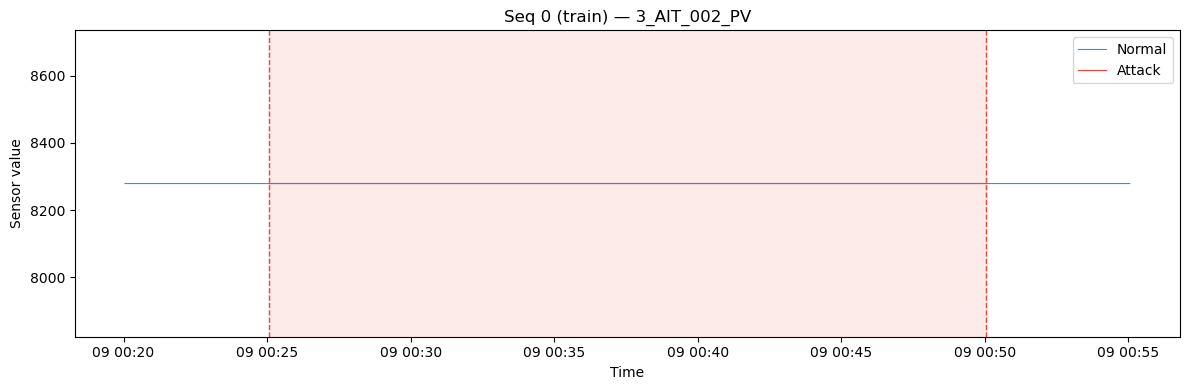

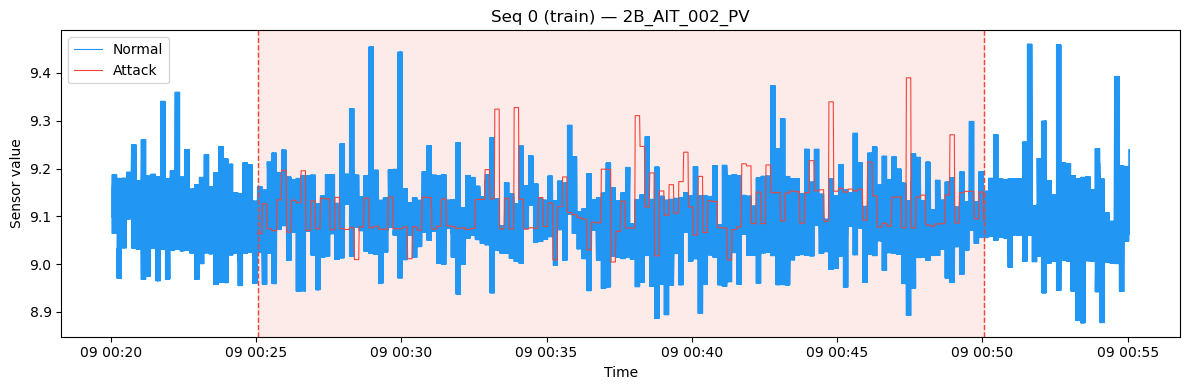

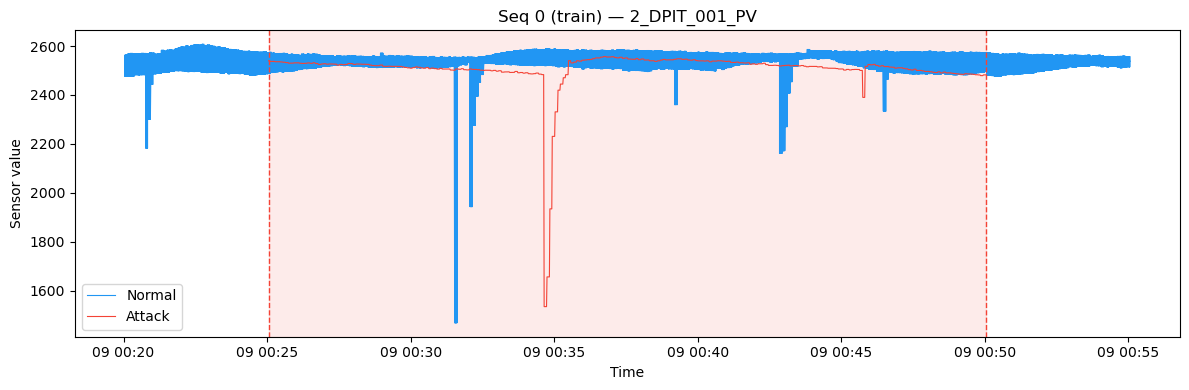

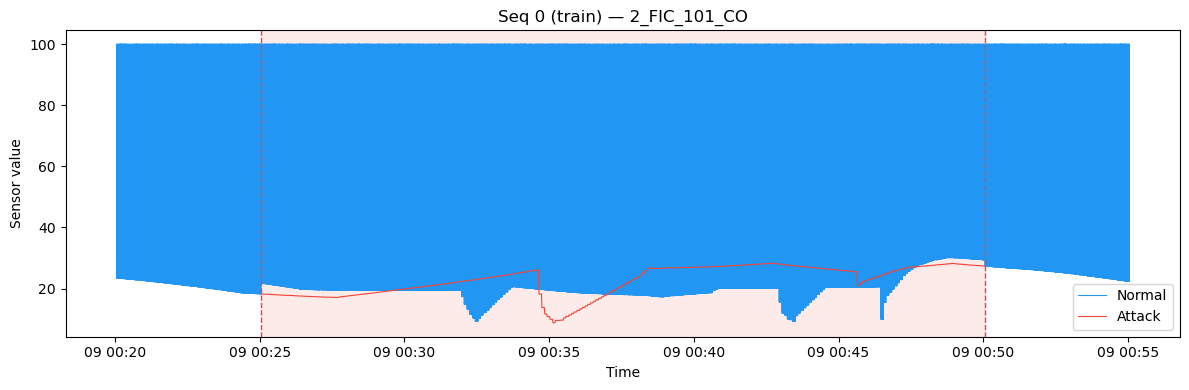

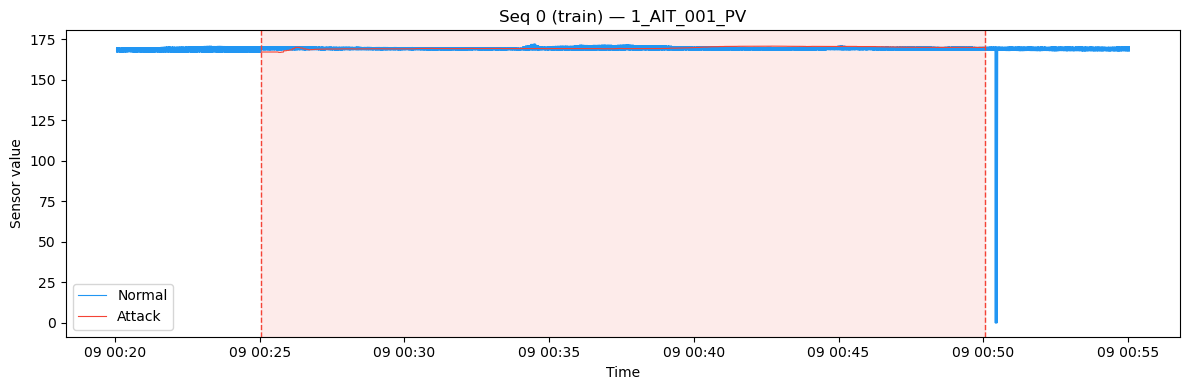

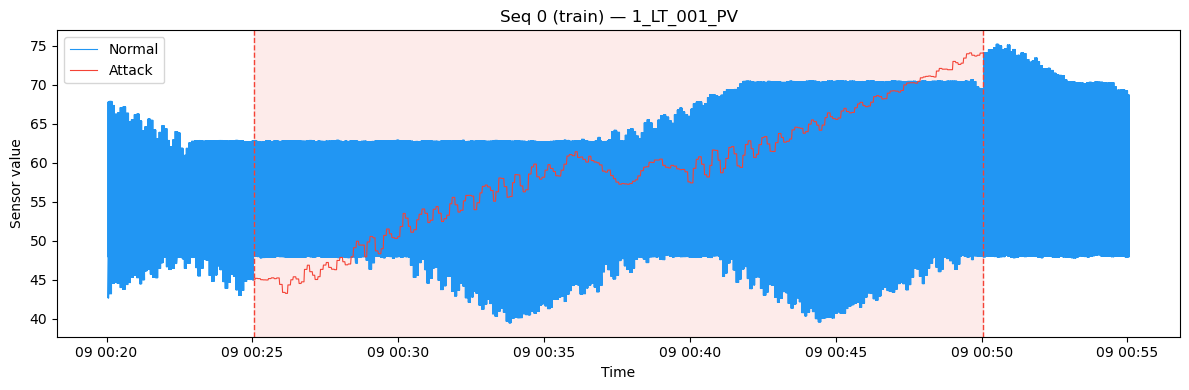

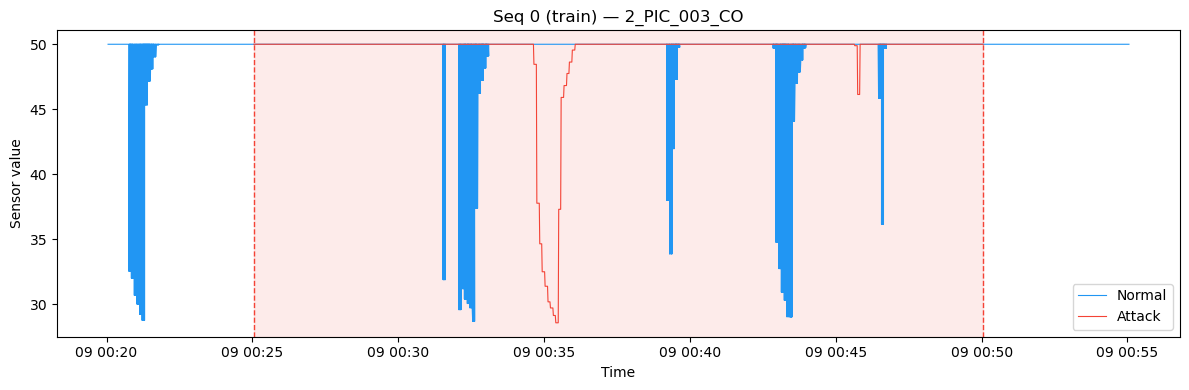

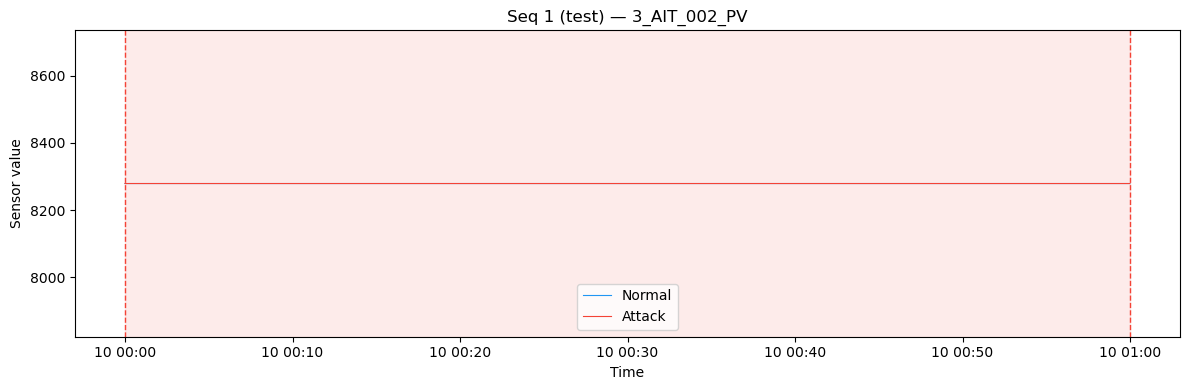

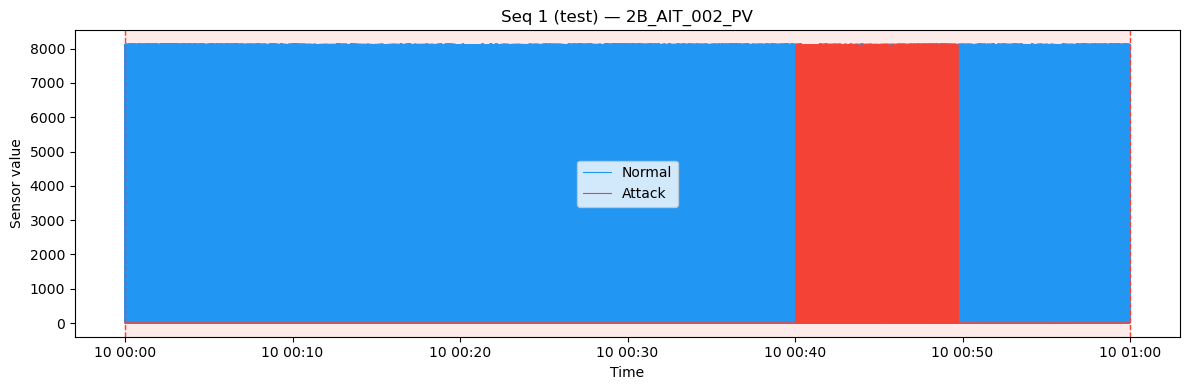

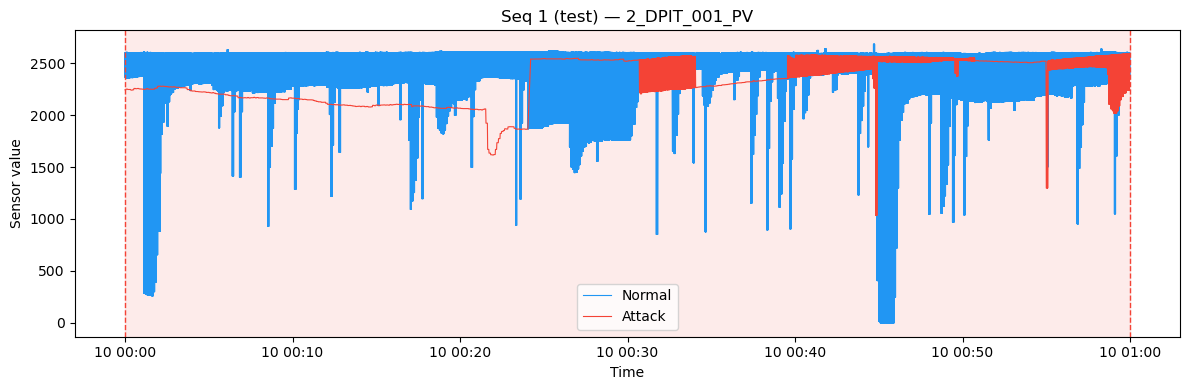

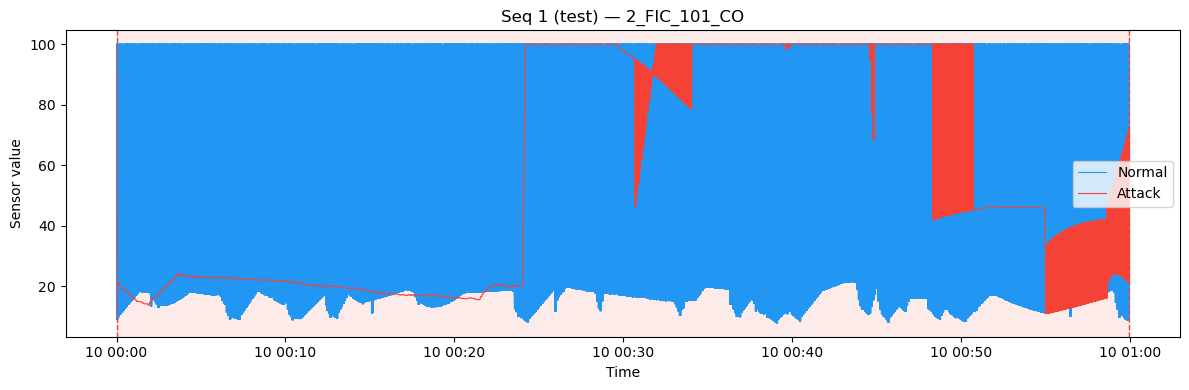

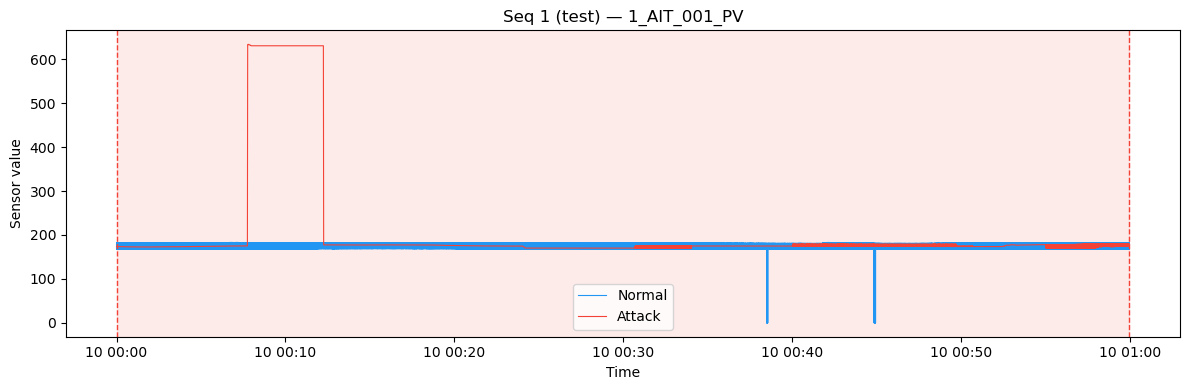

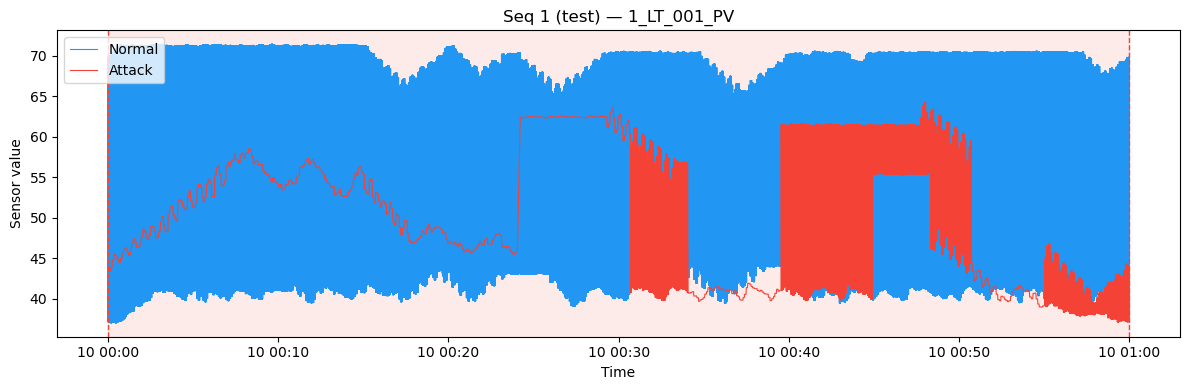

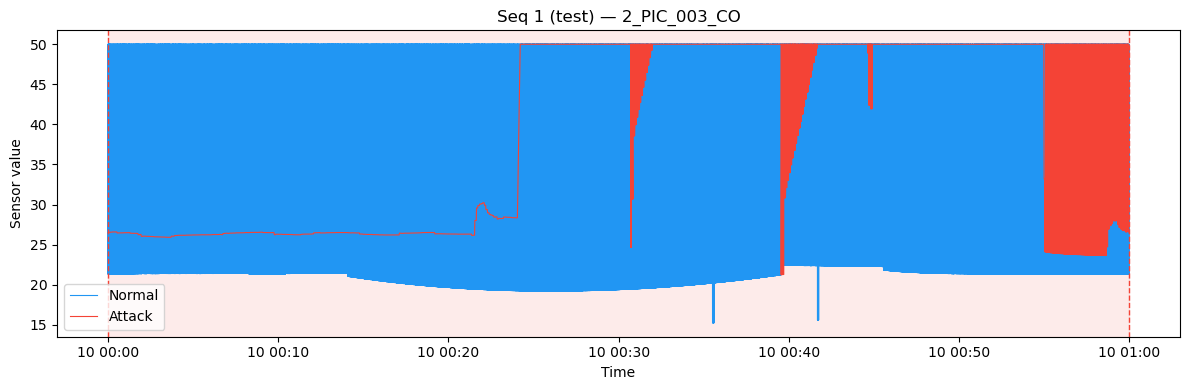

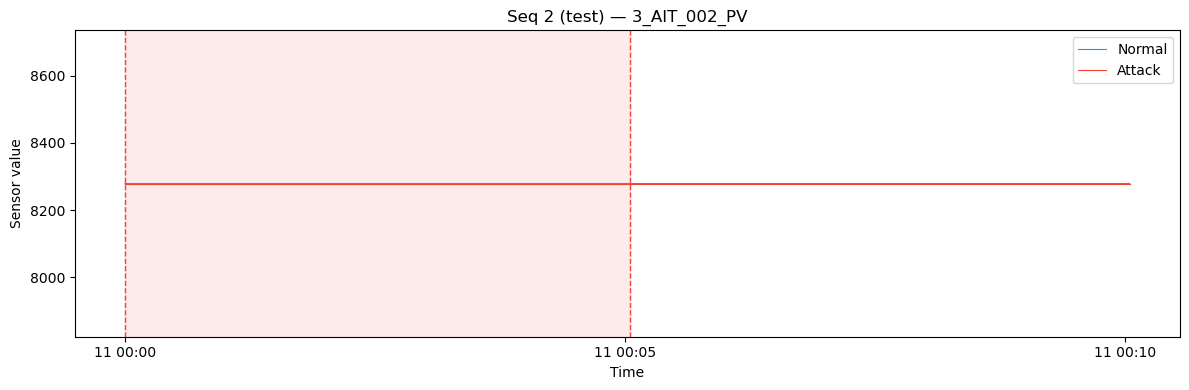

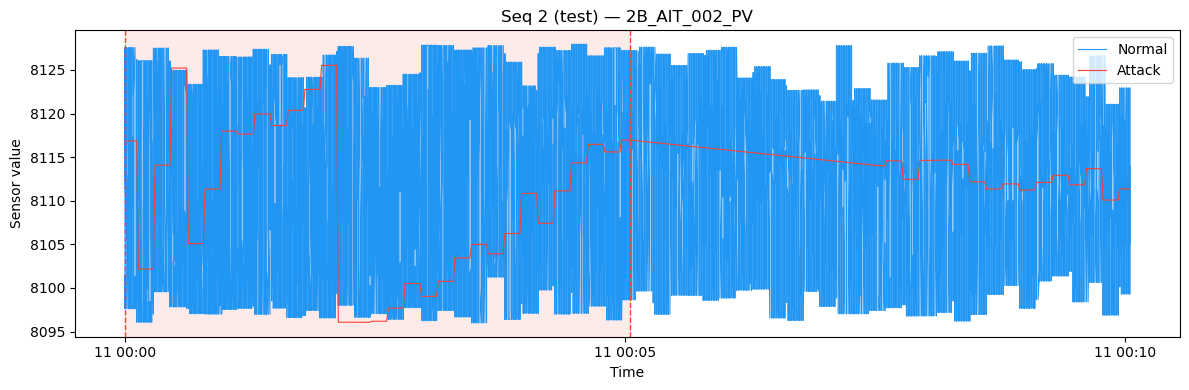

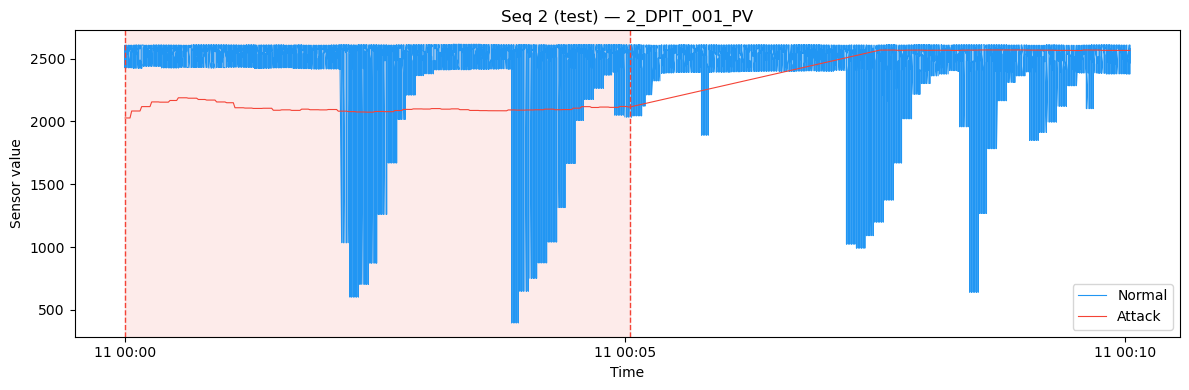

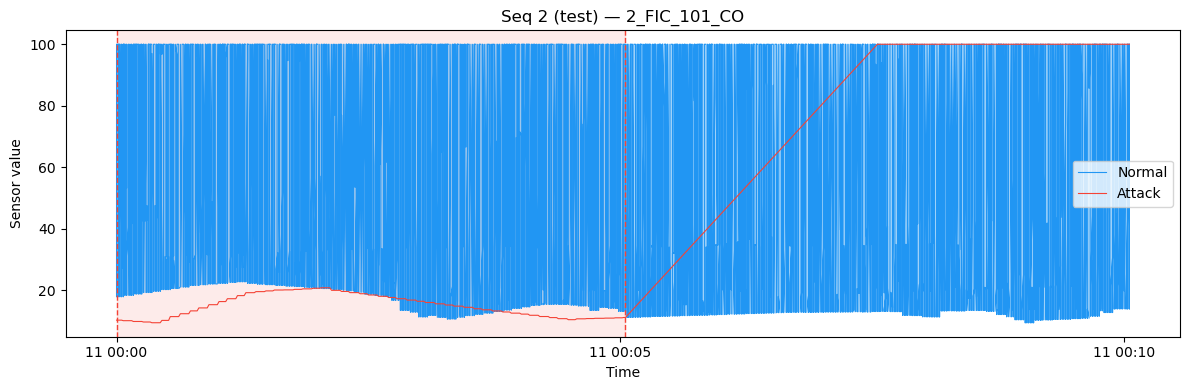

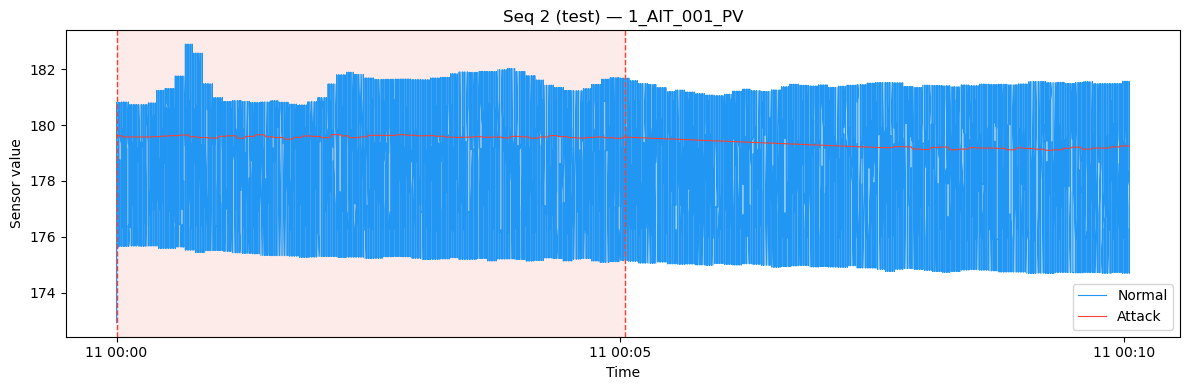

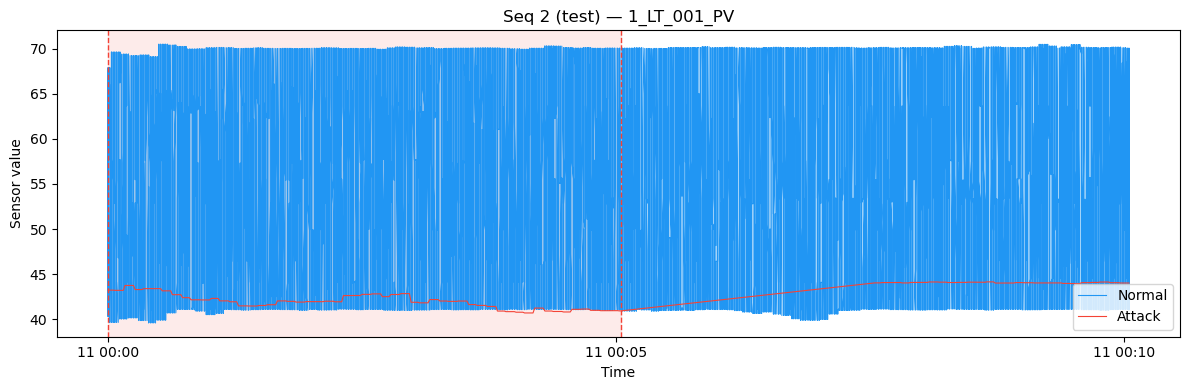

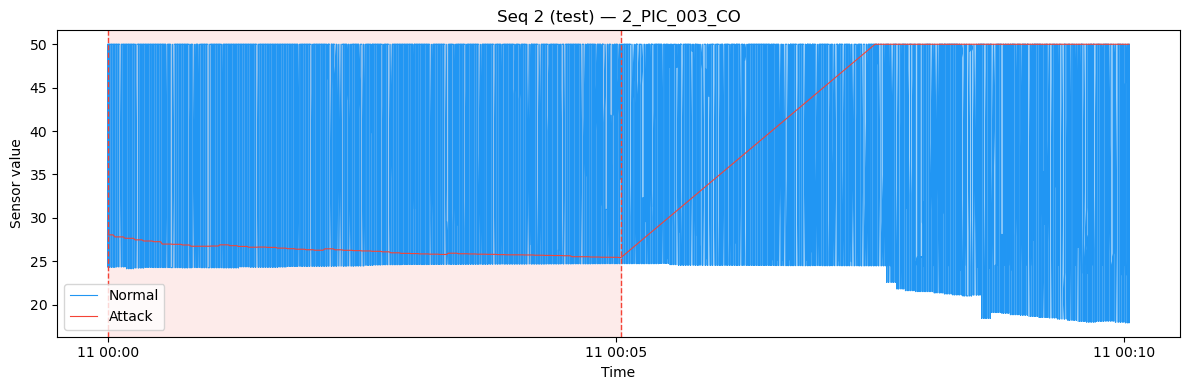

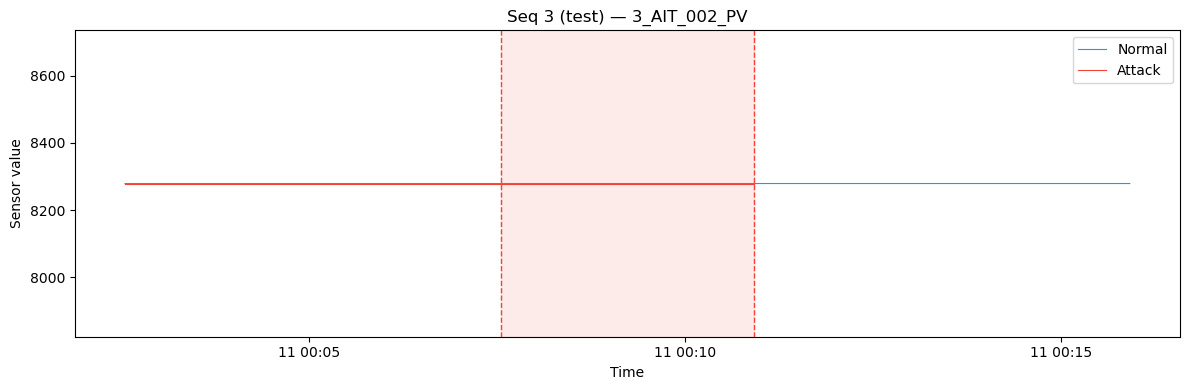

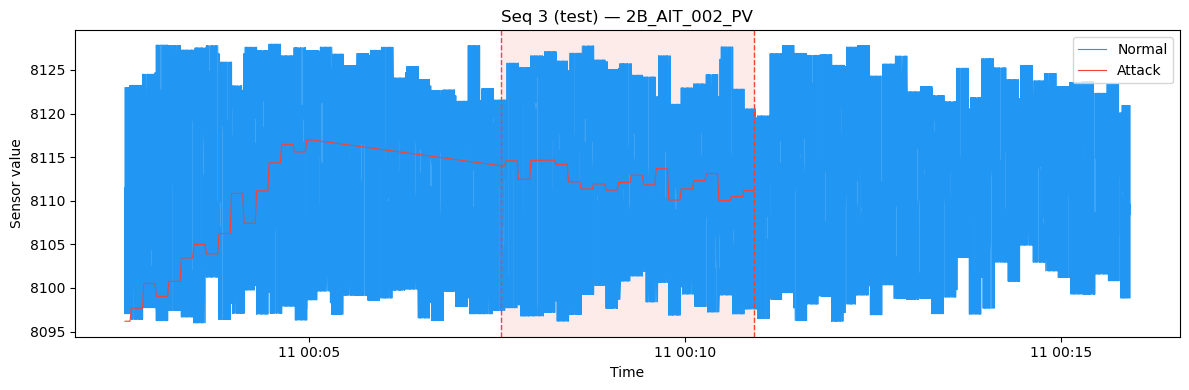

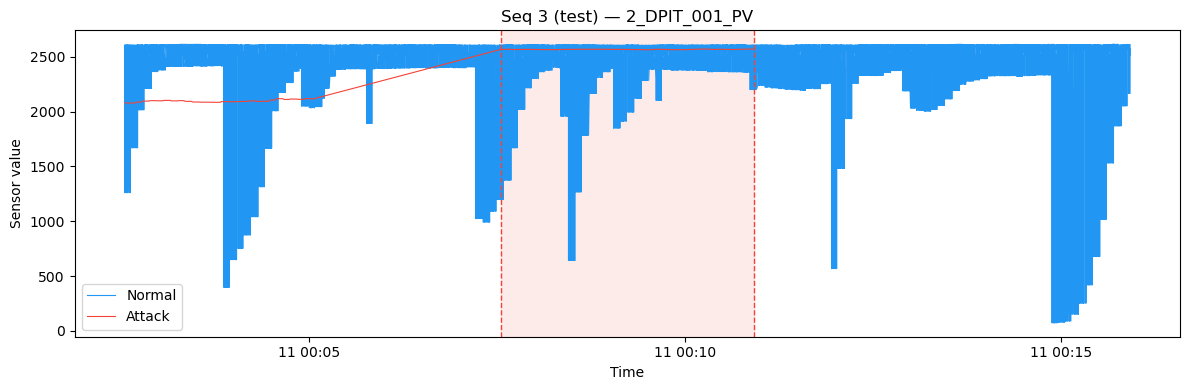

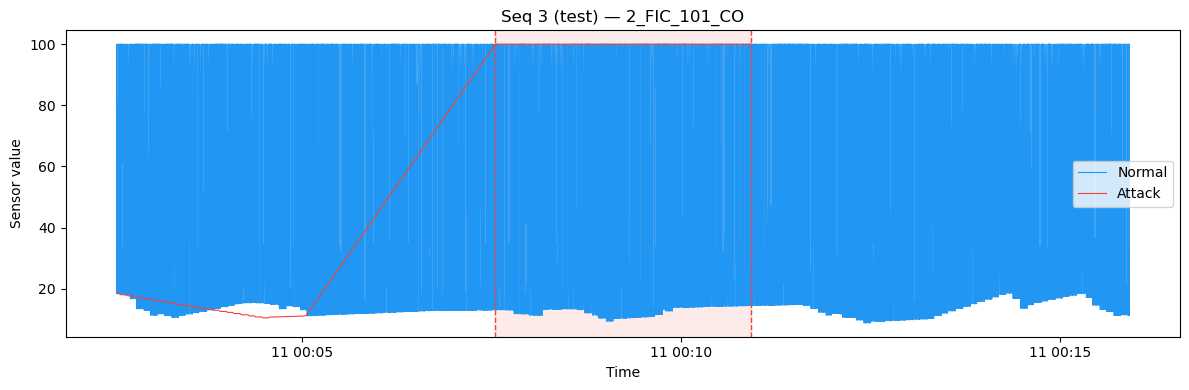

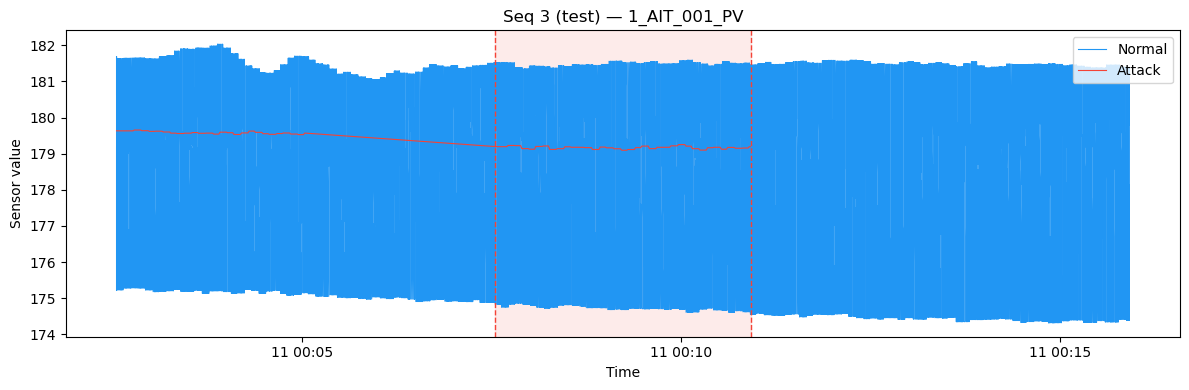

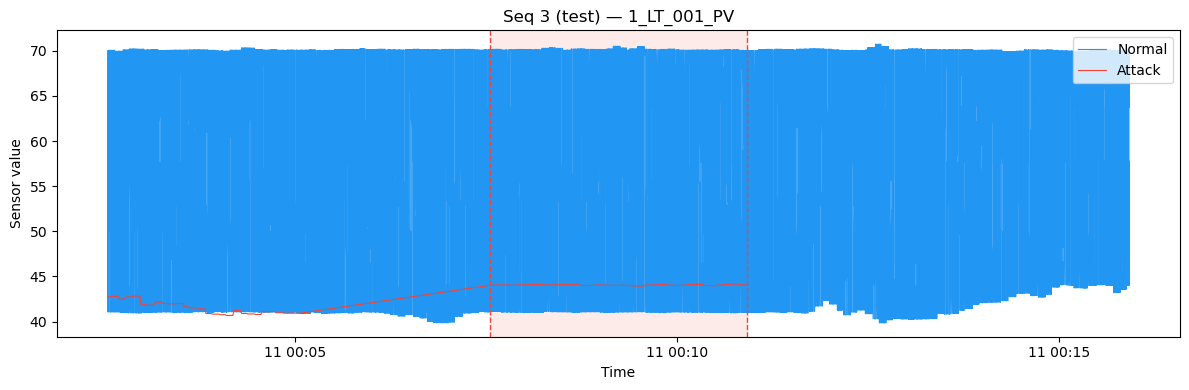

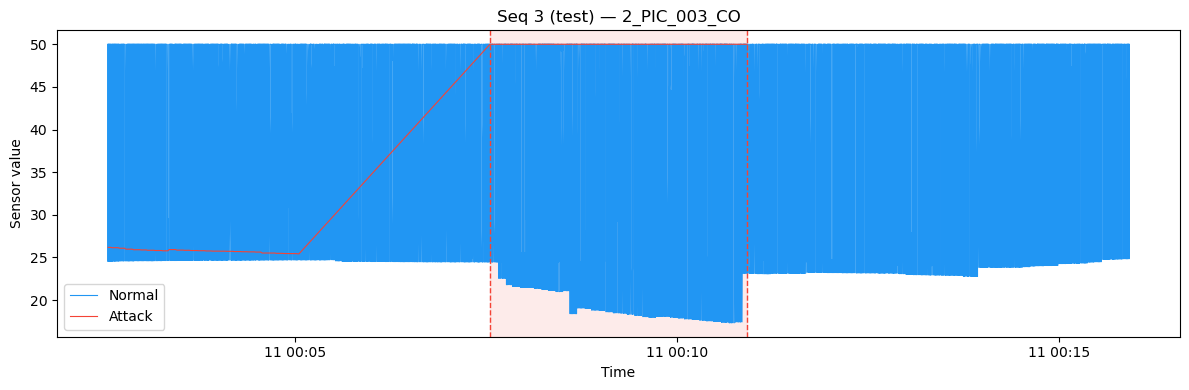

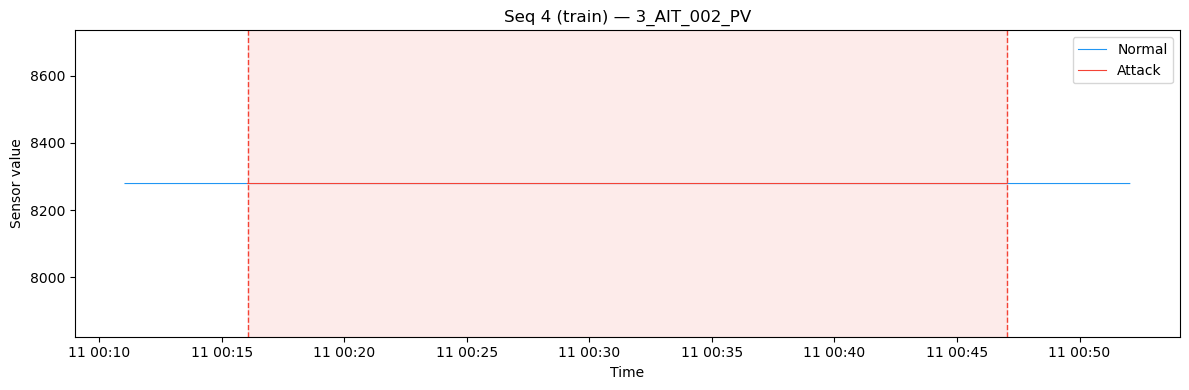

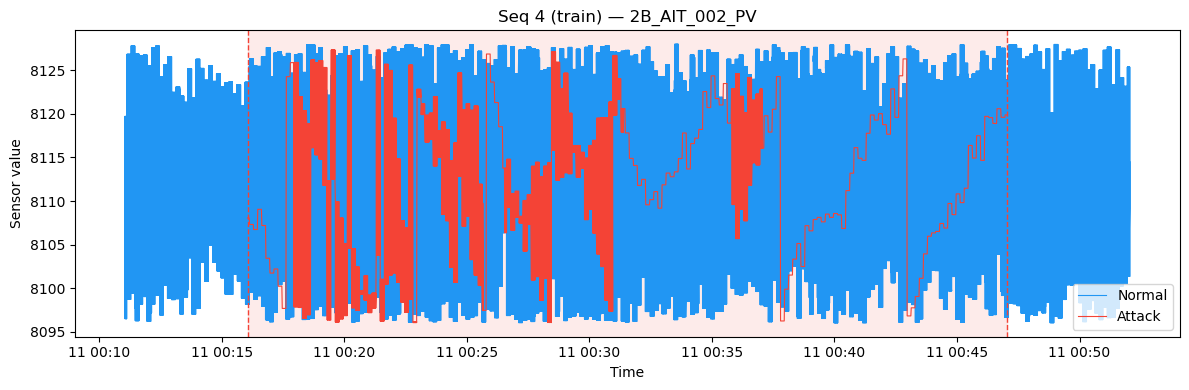

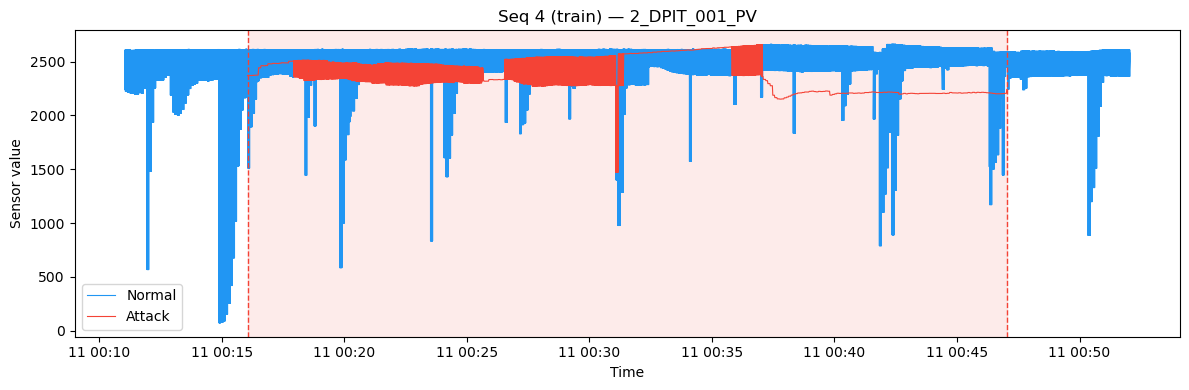

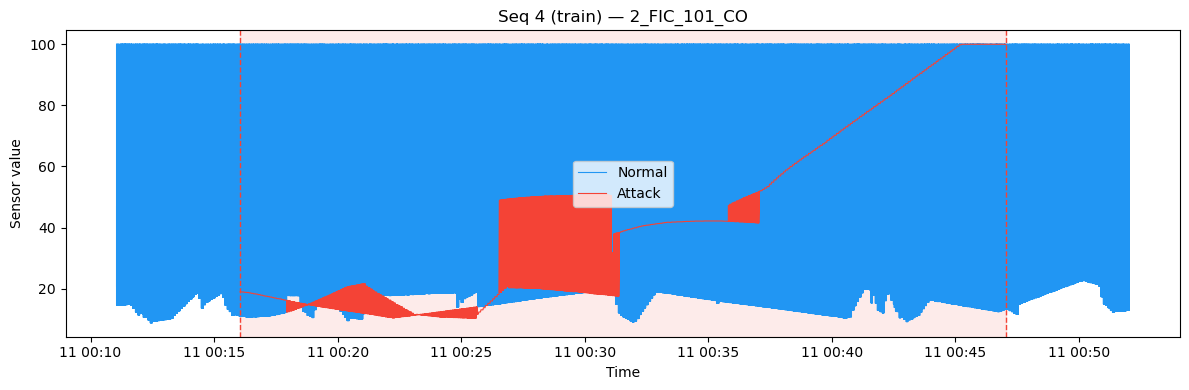

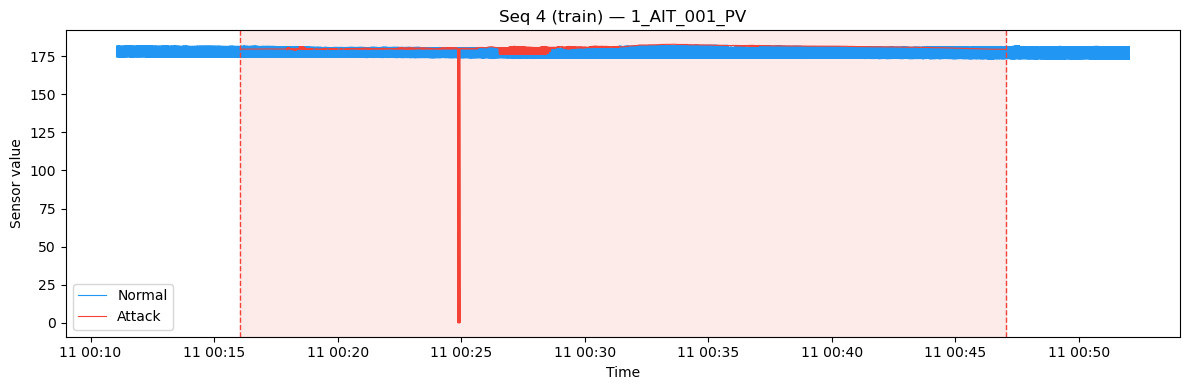

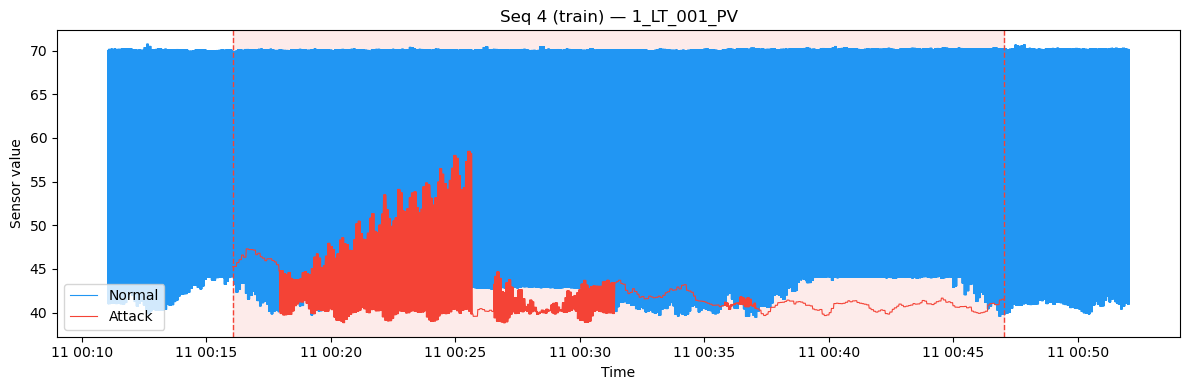

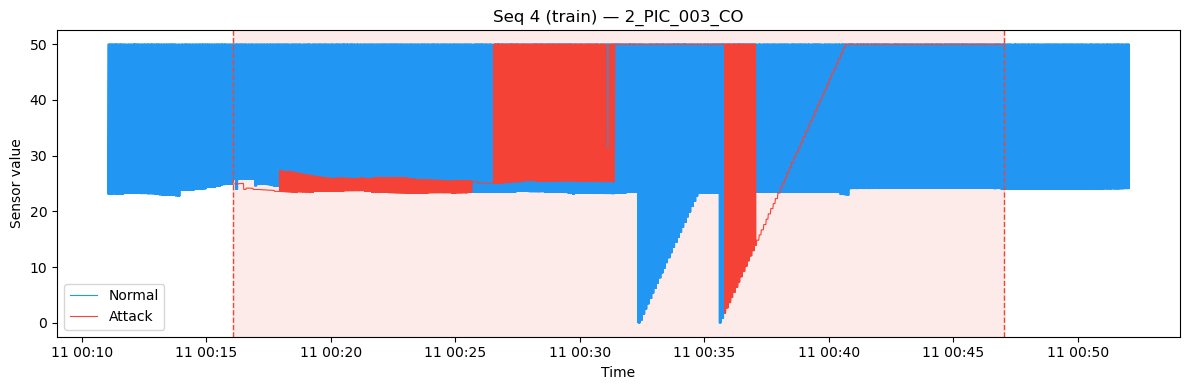

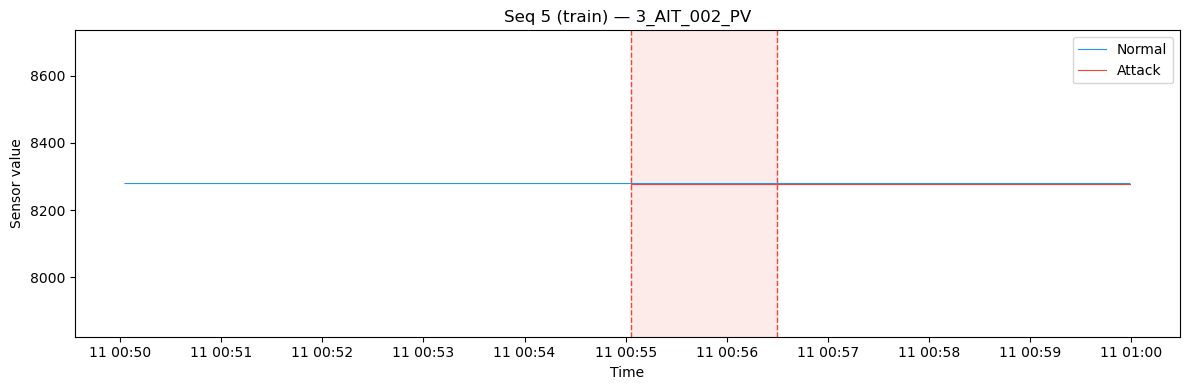

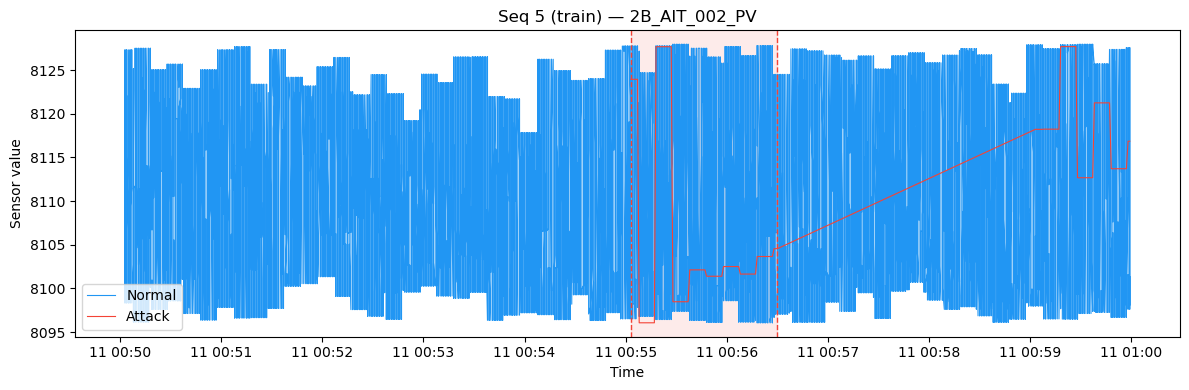

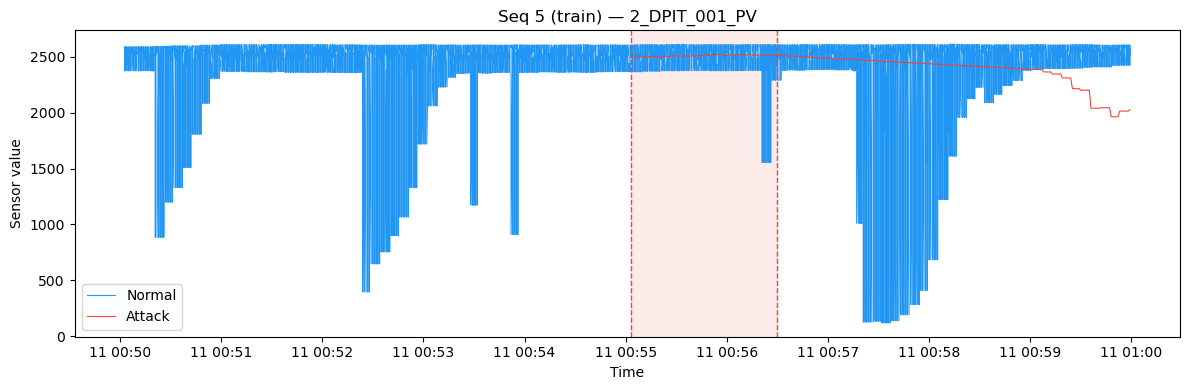

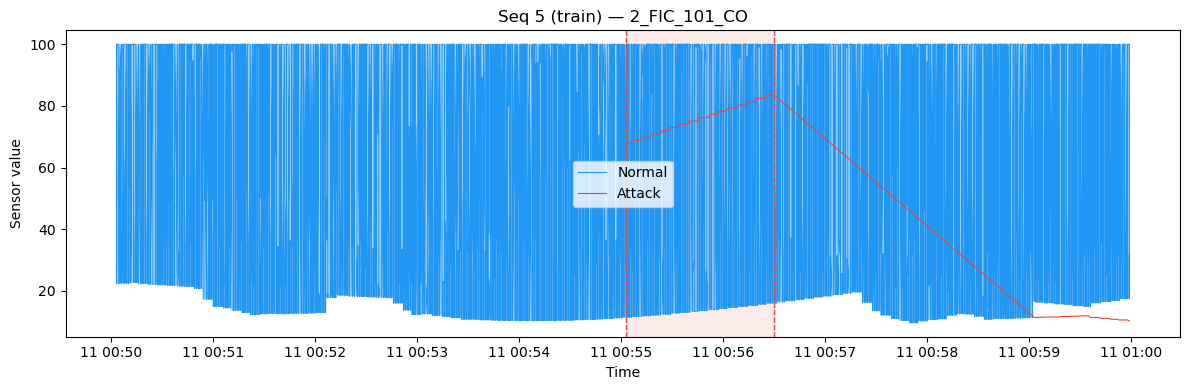

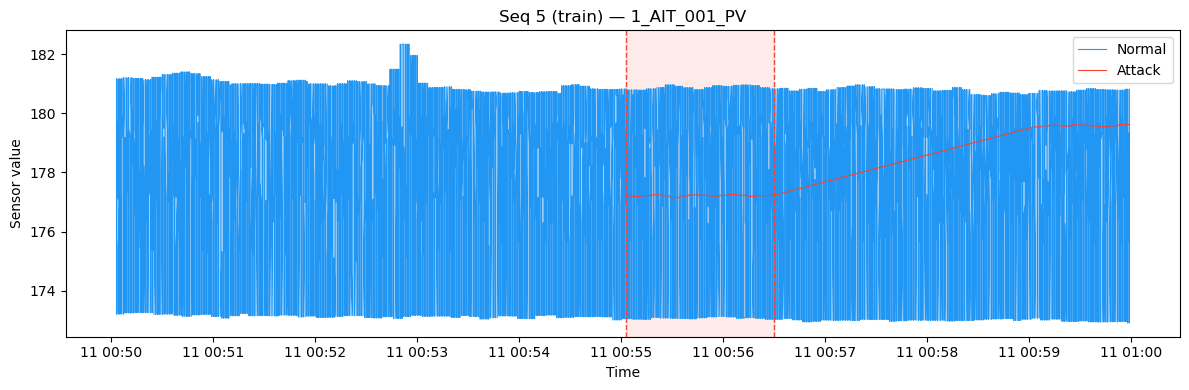

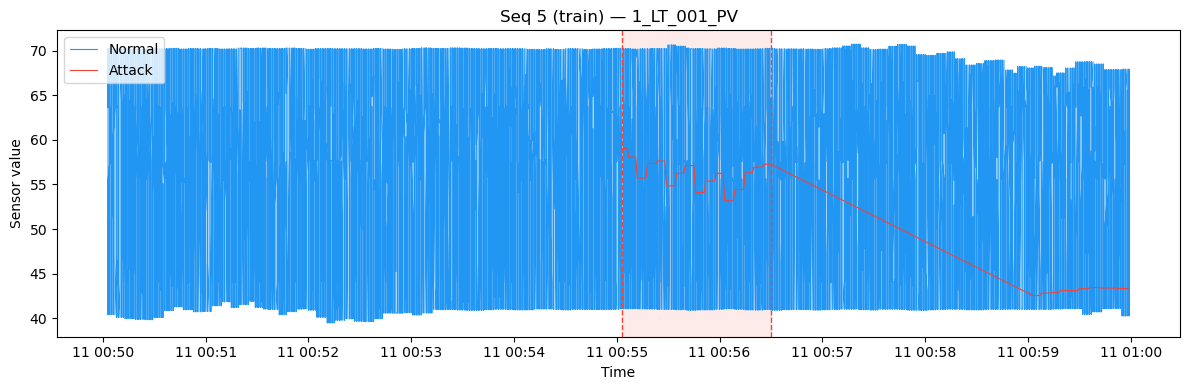

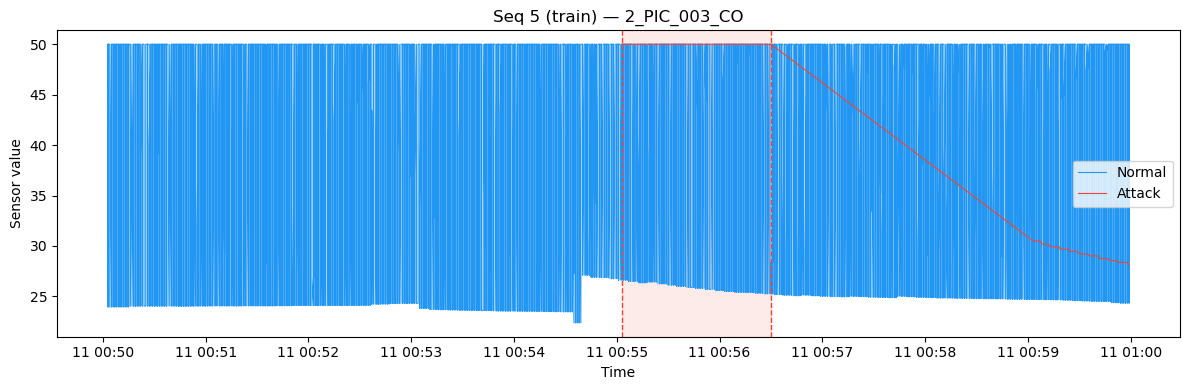

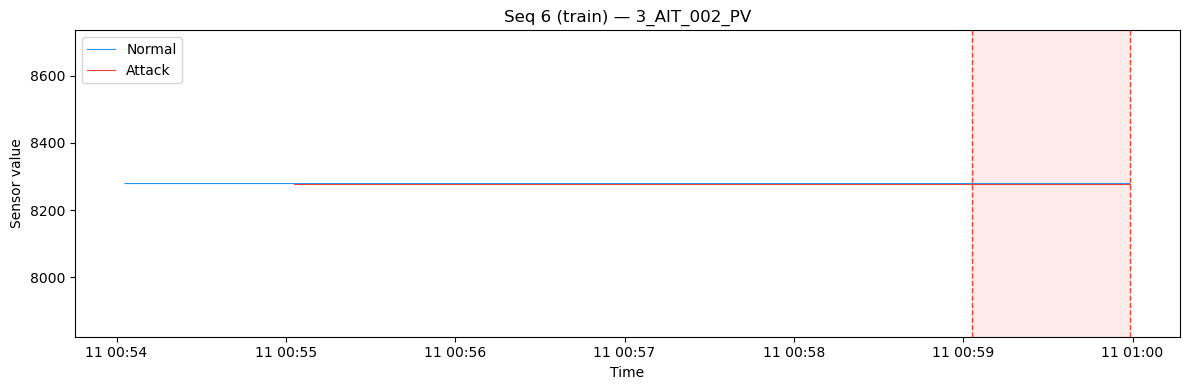

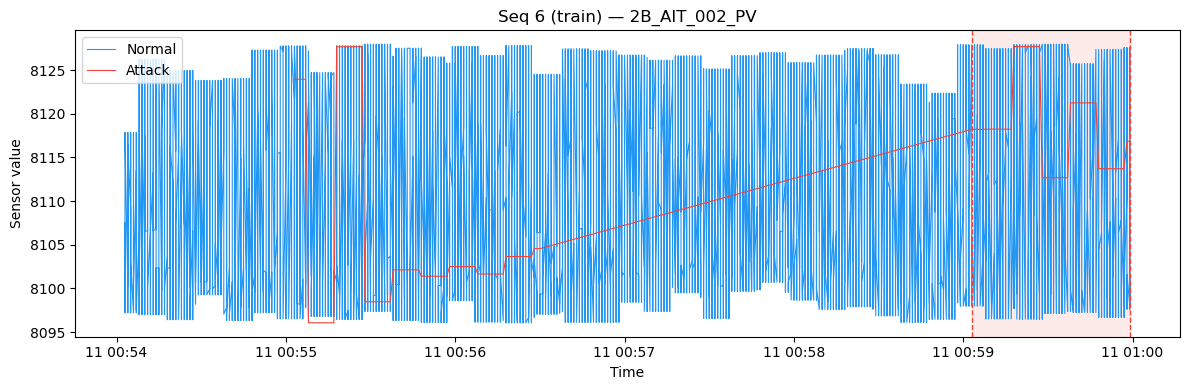

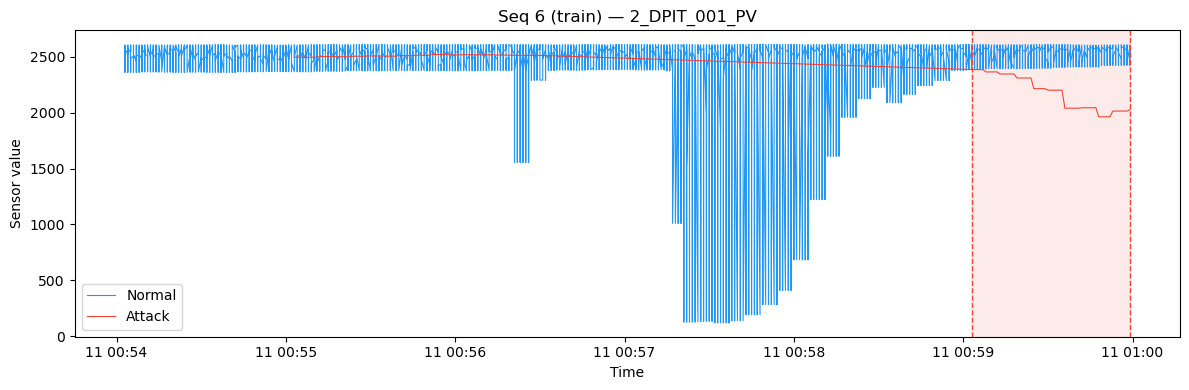

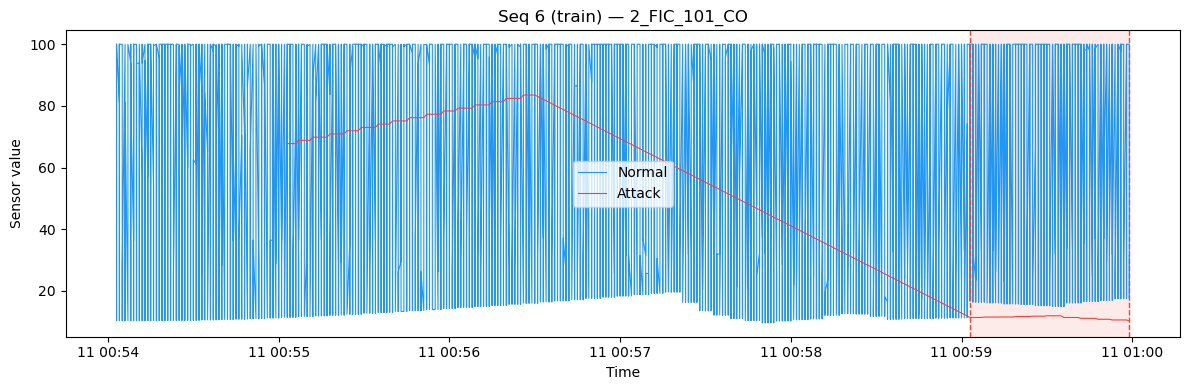

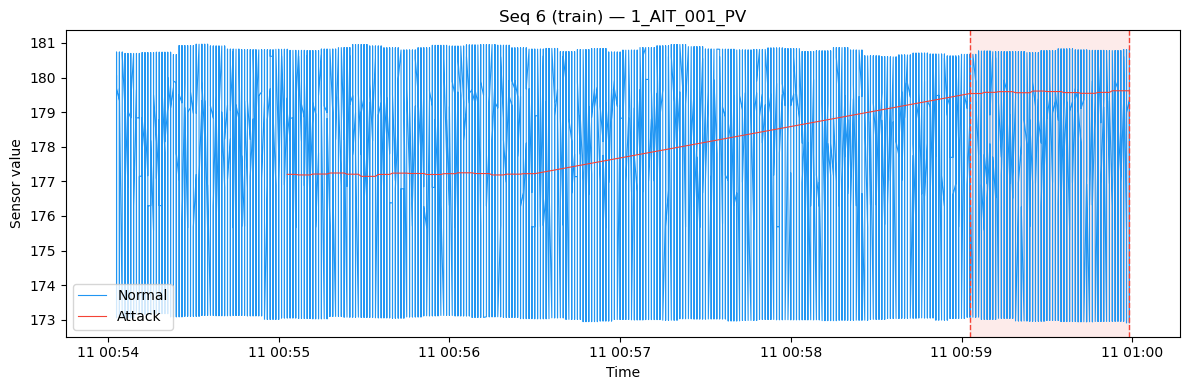

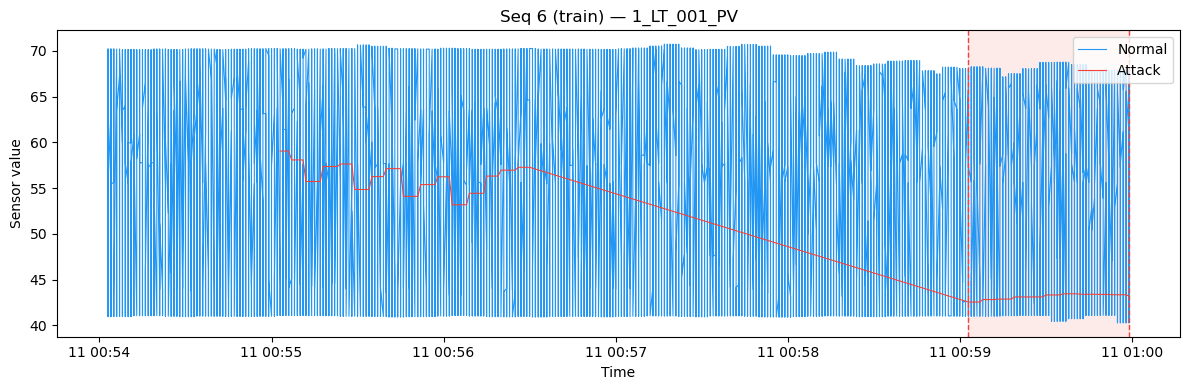

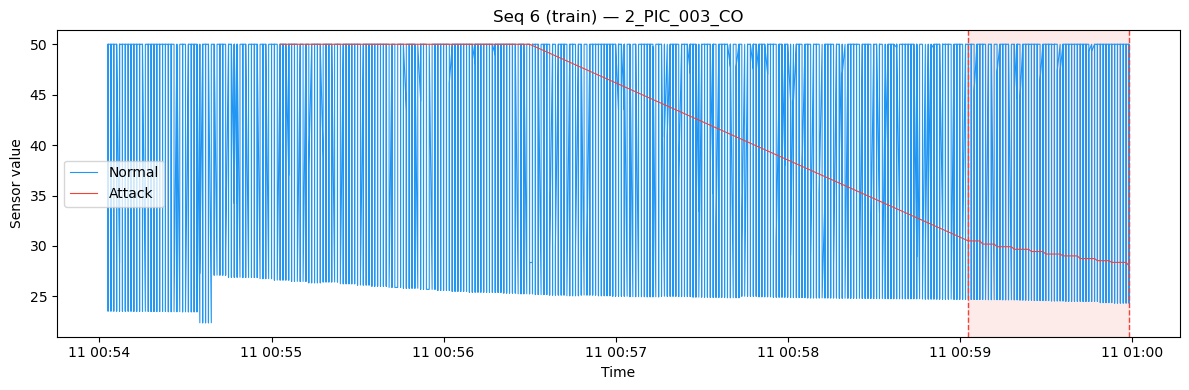

In [30]:
for _, seq in seq_summary_df.iterrows():
    seq_id    = seq["seq_id"]
    win_start = seq["start"] - pd.Timedelta(minutes=5)
    win_end   = seq["end"]   + pd.Timedelta(minutes=5)

    window_df = df_sorted[
        (df_sorted["timestamp"] >= win_start) &
        (df_sorted["timestamp"] <= win_end)
    ]

    for sensor in REPRESENTATIVE_SENSORS:
        fig, ax = plt.subplots(figsize=(12, 4))

        normal_mask = window_df["label"] == 0
        attack_mask = window_df["label"] == 1

        ax.plot(
            window_df.loc[normal_mask, "timestamp"],
            window_df.loc[normal_mask, sensor],
            color="#2196F3", linewidth=0.8, label="Normal"
        )
        ax.plot(
            window_df.loc[attack_mask, "timestamp"],
            window_df.loc[attack_mask, sensor],
            color="#F44336", linewidth=0.8, label="Attack"
        )

        ax.axvspan(seq["start"], seq["end"], color="#F44336", alpha=0.1)
        ax.axvline(seq["start"], color="#F44336", linestyle="--", linewidth=1)
        ax.axvline(seq["end"],   color="#F44336", linestyle="--", linewidth=1)

        ax.set_title(f"Seq {seq_id} ({seq['split']}) — {sensor}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Sensor value")
        ax.legend()

        plt.tight_layout()
        plt.show()
        save_fig(fig, f"eda_attack_seq{seq_id}_{sensor}.png")

### 5.2 Analysis

- **Attack signatures are visible by eye in multiple sensors** — the attacks are
  not subtle. Several sensors show abrupt, sustained changes at attack boundaries
  that are clearly distinguishable from normal oscillation.
- **Most consistent attack indicators across sequences:**
  - `2_DPIT_001_PV` — sharp drops during attack periods visible in seqs 0, 1, 4.
    The most consistent attack indicator across sequences.
  - `2_FIC_101_CO` — dramatic value shift at attack start in seq 0, spikes in
    seq 1. Strong and abrupt signature.
  - `2_PIC_003_CO` — sharp drops in seq 0, gradual ramp in seq 2. Response
    pattern varies by sequence.
  - `1_LT_001_PV` — gradual upward trend in seq 0, flat suppression in seq 2.
    Different attack sequences produce different signatures on this sensor.
- **`1_AIT_001_PV` shows an unusual frozen pattern in seq 0** — completely flat
  during the attack period then drops to near zero at the end. This looks more
  like a sensor being manipulated or suppressed than a physical process response.
- **`2B_AIT_002_PV` shows no visible signature in seq 0 (Oct 9)** but by seq 4
  (Oct 11) the sensor is at ~8100–8125 with a distinct oscillation pattern during
  attacks. The sensor's behavior changes dramatically across the recording period.
- **Attack signatures are not consistent across sequences** — the same sensor
  responds differently to different attack sequences. This suggests the attacks
  target different parts of the system, producing varied sensor responses. Rolling
  window features in NB5 should capture these temporal patterns.
- **Implication for fault injection (NB3):** `2_DPIT_001_PV`, `2_FIC_101_CO`,
  and `2_PIC_003_CO` are the strongest and most consistent attack indicators.
  Synthetic failures injected into these sensors will need to produce signatures
  that are distinguishable from both normal behavior and these attack patterns.


# Section 6 — Correlation Structure Analysis

Individual sensor behavior tells only part of the story. In physical systems,
sensors are coupled, pressure affects flow, level affects pressure, and so on.
Cyber attacks may disrupt these coupling relationships even when individual sensor
values look plausible. This section examines whether the correlation structure
between sensors changes during attacks compared to normal operation.

A change in correlation structure during attacks would motivate cross-sensor
features in NB5 feature engineering.

## 6.1 Compute Correlation Matrices

Compute Pearson correlation matrices for three periods separately:
- Pre-attack normal (train, label=0)
- Attack rows (label=1)
- Attack-window normal (test, label=0)

We use the representative sensors only — computing a full 98x98 correlation
matrix would be difficult to interpret visually.

In [31]:
corr_pre    = normal_pre_attack[REPRESENTATIVE_SENSORS].corr()
corr_attack = df_sorted[df_sorted["label"] == 1][REPRESENTATIVE_SENSORS].corr()
corr_test_normal = normal_attack_window[REPRESENTATIVE_SENSORS].corr()

print("Pre-attack normal correlation matrix:")
print(corr_pre.round(2))

Pre-attack normal correlation matrix:
               3_AIT_002_PV  2B_AIT_002_PV  2_DPIT_001_PV  2_FIC_101_CO  1_AIT_001_PV  1_LT_001_PV  2_PIC_003_CO
3_AIT_002_PV           1.00           0.11           0.12          0.37         -0.06         0.04         -0.03
2B_AIT_002_PV          0.11           1.00           0.00          0.06          0.14        -0.01          0.02
2_DPIT_001_PV          0.12           0.00           1.00          0.24         -0.04         0.11          0.38
2_FIC_101_CO           0.37           0.06           0.24          1.00          0.03         0.15          0.15
1_AIT_001_PV          -0.06           0.14          -0.04          0.03          1.00         0.02         -0.00
1_LT_001_PV            0.04          -0.01           0.11          0.15          0.02         1.00          0.07
2_PIC_003_CO          -0.03           0.02           0.38          0.15         -0.00         0.07          1.00


## 6.2 Correlation Heatmaps

Plot correlation matrices for all three periods side by side. Visual comparison
reveals whether attack periods disrupt the normal correlation structure between
sensors, a sign that attacks affect multiple sensors simultaneously rather than
in isolation.

/tmp/ipykernel_5864/1277045470.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


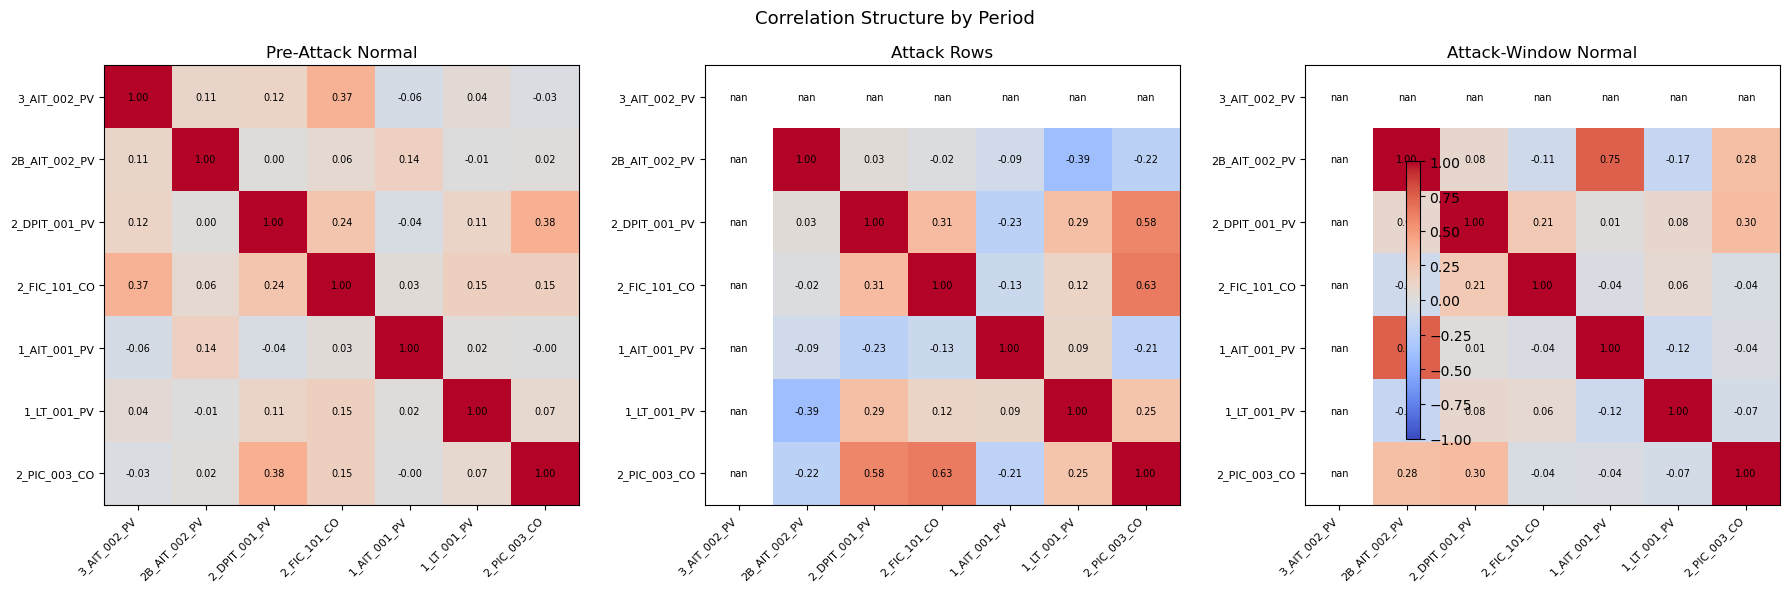

In [32]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = ["Pre-Attack Normal", "Attack Rows", "Attack-Window Normal"]
matrices = [corr_pre, corr_attack, corr_test_normal]

for ax, matrix, title in zip(axes, matrices, titles):
    im = ax.imshow(matrix.values, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
    ax.set_xticks(range(len(REPRESENTATIVE_SENSORS)))
    ax.set_yticks(range(len(REPRESENTATIVE_SENSORS)))
    ax.set_xticklabels(REPRESENTATIVE_SENSORS, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(REPRESENTATIVE_SENSORS, fontsize=8)
    ax.set_title(title)

    for i in range(len(REPRESENTATIVE_SENSORS)):
        for j in range(len(REPRESENTATIVE_SENSORS)):
            ax.text(j, i, f"{matrix.values[i,j]:.2f}",
                   ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
plt.suptitle("Correlation Structure by Period", fontsize=13)
plt.tight_layout()
plt.show()
save_fig(fig, "eda_correlation_heatmaps.png")

### 6.2 Analysis

- **`3_AIT_002_PV` produces NaN correlations in attack and attack-window panels**
  — the sensor is saturated at a single constant value in both periods, making
  correlation undefined. This further confirms the sensor is uninformative during
  the test period.
- **Attack rows show strengthened correlations between physical process sensors**
  — `2_FIC_101_CO` ↔ `2_PIC_003_CO` rises from 0.15 to 0.63 and
  `2_DPIT_001_PV` ↔ `2_PIC_003_CO` rises from 0.38 to 0.58 during attacks.
  This suggests attacks force these sensors into a more tightly coupled regime,
  possibly by manipulating a shared physical process.
- **`1_LT_001_PV` ↔ `2B_AIT_002_PV` becomes negatively correlated (-0.39)
  during attacks** — these sensors move in opposite directions during attack
  periods, a pattern not present in normal operation.
- **Attack-window normals show a new strong correlation** — `2B_AIT_002_PV` ↔
  `1_AIT_001_PV` jumps from 0.14 in pre-attack normal to 0.75 in attack-window
  normal. This is a structural change in the normal population during the test
  period, not just an attack artifact.
- **Implication for feature engineering (NB5):** Cross-sensor features capturing
  the relationship between `2_FIC_101_CO`, `2_DPIT_001_PV`, and `2_PIC_003_CO`
  may be valuable attack discriminators. The strengthened coupling during attacks
  is a detectable pattern that single-sensor features would miss.
- **Caveat:** These findings are based on 7 representative sensors only. A full
  98-sensor correlation analysis may reveal additional coupling patterns.

# Section 7 — Normalization Strategy Assessment

All findings so far have been on raw sensor values. Before modeling, sensors must
be normalized to a common scale, otherwise high-variance sensors like
`3_AIT_002_PV` will dominate the feature space. The standard approach is to fit
a StandardScaler on the train split and apply it to both train and test.

The question this section investigates is whether train-only normalization is
appropriate given the distribution shift and sensor drift we have observed, or
whether an alternative strategy is needed.

## 7.1 Apply Train-Only Normalization

Fit a StandardScaler on the train split sensor columns and transform both train
and test. Then compute per-block means on the normalized data and compare to the
raw per-block means from Section 3. If normalization resolves the shift, test
block means should be close to zero. If shift persists, it is a genuine dataset
property that normalization alone cannot fix.

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_mask = df_sorted["split"] == "train"
test_mask  = df_sorted["split"] == "test"

df_normalized = df_sorted.copy()
df_normalized.loc[train_mask, REPRESENTATIVE_SENSORS] = scaler.fit_transform(
    df_sorted.loc[train_mask, REPRESENTATIVE_SENSORS]
)
df_normalized.loc[test_mask, REPRESENTATIVE_SENSORS] = scaler.transform(
    df_sorted.loc[test_mask, REPRESENTATIVE_SENSORS]
)

# Per-block means on normalized data
norm_block_means = []
for block_id, block_df in df_normalized.groupby("block_id"):
    date  = block_df["timestamp"].min().date()
    split = block_df["split"].iloc[0]
    means = block_df[REPRESENTATIVE_SENSORS].mean()
    norm_block_means.append({"block_id": block_id, "date": date, "split": split, **means})

norm_block_df = pd.DataFrame(norm_block_means)
print(norm_block_df[["block_id", "date", "split"] + REPRESENTATIVE_SENSORS].to_string(index=False))

 block_id       date split  3_AIT_002_PV  2B_AIT_002_PV  2_DPIT_001_PV  2_FIC_101_CO  1_AIT_001_PV  1_LT_001_PV  2_PIC_003_CO
        0 2017-09-25 train     -0.626523      -0.262782       0.042905     -0.247148     -0.091725    -0.034721      0.391563
        1 2017-09-26 train     -0.319572      -0.262813      -0.097796      0.086659     -0.219329    -0.168883      0.021352
        2 2017-09-27 train     -0.427597      -0.262801      -0.027146      0.006358      1.418040    -0.080284     -0.034635
        3 2017-09-28 train     -0.194046      -0.262803      -0.028427     -0.004137      1.555301     0.100120      0.046230
        4 2017-09-29 train     -0.261191      -0.262829      -0.050139      0.095115      0.536750     0.065035      0.045267
        5 2017-10-02 train     -0.855567      -0.262739       0.033294     -0.281387     -1.104241     0.351543      0.085792
        6 2017-10-03 train     -0.163421      -0.262761       0.076346      0.027798     -1.103170     0.082577      0

### 7.1 Analysis

- **Normalization resolves the shift for most sensors** — five of seven
  representative sensors show normalized block means close to zero in both
  train and test periods, confirming that train-only StandardScaler is
  appropriate for the majority of the dataset.
- **`2B_AIT_002_PV` shows severe persistent shift after normalization** —
  test blocks reach +1.12 and +3.81 standard deviations above the training
  mean. This is not a normalization artifact — the sensor's behavior in the
  test period is genuinely outside the range seen during training. No
  normalization strategy fitted on train data alone can resolve this.
- **`3_AIT_002_PV` is effectively constant in the test period** — normalized
  value is +0.41 for all test blocks, identical to the last train blocks where
  saturation occurred. The sensor carries no information in the test period
  regardless of normalization strategy.
- **Train-only normalization is appropriate for the majority of sensors** —
  the shift problem is concentrated in two sensors, not a dataset-wide
  normalization failure.

## 7.2 Per-Block Normalization Comparison

As an alternative to train-only normalization, we test per-block normalization,
fitting a StandardScaler independently on each contiguous time block. If per-block
normalization brings all blocks closer to zero mean, it suggests that sensors are
internally consistent within each day but shift between days. This would motivate
a different normalization strategy in NB5.

Note: Per-block normalization would constitute data leakage in a real deployment
scenario since future blocks are not available at fit time. We evaluate it here
purely as a diagnostic tool to understand the nature of the shift.

In [34]:
df_perblock = df_sorted.copy()

for block_id, block_df in df_sorted.groupby("block_id"):
    idx = block_df.index
    block_scaler = StandardScaler()
    df_perblock.loc[idx, REPRESENTATIVE_SENSORS] = block_scaler.fit_transform(
        block_df[REPRESENTATIVE_SENSORS]
    )

# Per-block means after per-block normalization
perblock_means = []
for block_id, block_df in df_perblock.groupby("block_id"):
    date  = block_df["timestamp"].min().date()
    split = block_df["split"].iloc[0]
    means = block_df[REPRESENTATIVE_SENSORS].mean()
    perblock_means.append({"block_id": block_id, "date": date, "split": split, **means})

perblock_df = pd.DataFrame(perblock_means)
print(perblock_df[["block_id", "date", "split"] + REPRESENTATIVE_SENSORS].round(4).to_string(index=False))

 block_id       date split  3_AIT_002_PV  2B_AIT_002_PV  2_DPIT_001_PV  2_FIC_101_CO  1_AIT_001_PV  1_LT_001_PV  2_PIC_003_CO
        0 2017-09-25 train          -0.0            0.0            0.0           0.0          -0.0         -0.0           0.0
        1 2017-09-26 train          -0.0            0.0            0.0          -0.0           0.0         -0.0          -0.0
        2 2017-09-27 train          -0.0           -0.0            0.0           0.0          -0.0          0.0           0.0
        3 2017-09-28 train           0.0           -0.0            0.0          -0.0           0.0         -0.0           0.0
        4 2017-09-29 train          -0.0           -0.0            0.0          -0.0          -0.0         -0.0           0.0
        5 2017-10-02 train           0.0           -0.0            0.0          -0.0          -0.0         -0.0          -0.0
        6 2017-10-03 train           0.0            0.0            0.0           0.0          -0.0          0.0       

### 7.2 Analysis

- **Per-block normalization produces zero mean for every block by definition** —
  this is mathematically guaranteed since each block is normalized independently.
  The result confirms the computation is correct but is not informative about
  whether shift is genuinely resolved.
- **The diagnostic value of per-block normalization is limited** — it removes
  within-block drift by construction, but at the cost of destroying inter-block
  information. A sensor that drifts from 500 to 450 across the recording period
  would look identical in both early and late blocks after per-block normalization.
- **Per-block normalization is not viable for the deployment pipeline** — it
  requires fitting a scaler on each incoming block independently, which assumes
  block boundaries are known in advance. In a real ICS deployment, data arrives
  as a continuous stream with no natural block boundaries.
- **The shift in `2B_AIT_002_PV` is a genuine dataset property** — no normalization
  strategy fitted on pre-attack data can resolve the fact that this sensor operates
  in a completely different value range during the test period. This is a
  characteristic of the dataset, not a preprocessing failure.

## 7.3 Recommendation

Based on the findings of Sections 7.1 and 7.2, we document our normalization
strategy recommendation for the downstream pipeline.

**Recommendation: Keep train-only normalization with documented limitations.**

Evidence:
- Train-only StandardScaler brings the majority of sensors to near-zero mean
  in both train and test periods (Section 7.1).
- The persistent shift in `2B_AIT_002_PV` (+3.81 std in test) and saturation
  of `3_AIT_002_PV` are genuine dataset properties — no normalization strategy
  fitted on train data alone can resolve them.
- Per-block normalization is not viable for a deployment-realistic pipeline and
  destroys inter-block information that may be useful for classification.

Limitations to document in the paper:
- Two sensors (`2B_AIT_002_PV`, `3_AIT_002_PV`) operate outside the training
  distribution in the test period. This is a known characteristic of the WaDi A2
  dataset consistent with findings in the literature (Turrin et al.).
- 35 of 78 eligible sensors show >1% out-of-range attack-window normal rows
  (Section 4.5). This contributes to false positives on test normal rows and
  should be reported as a dataset limitation rather than a modeling failure.
- These limitations apply equally to all methods evaluated on WaDi A2 and do
  not invalidate comparisons with prior work.

Action items for NB5:
- Fit StandardScaler on train split only — apply to both train and test
- Flag `2B_AIT_002_PV` and `3_AIT_002_PV` for monitoring in feature importance
- Report per-sensor out-of-range fractions from Section 4.5 in the paper

# Section 8 — Key Findings and Pipeline Implications

This section consolidates all findings from Sections 1–7 into a structured set
of documented decisions. Each finding is paired with its implication for
downstream notebooks. This section serves as the authoritative reference for
design decisions made as a result of this EDA.

## 8.1 Key Findings

**Finding 1: The dataset has a well-defined temporal structure with known gaps.**
14 contiguous daily blocks spanning Sept 25 – Oct 11 2017, with two missing days
(Sept 30, Oct 1) and three partial days (Sept 25, Sept 29, Oct 7). Attack rows
are confined to the last three blocks (Oct 9–11). The manual sequence-level
train/test split from NB1 is intact and methodologically sound.

**Finding 2: Day-to-day sensor drift exists but is sensor-specific.**
Two sensors show clear directional drift across the recording period —
`3_AIT_002_PV` drifts upward and saturates at 8279 by Oct 5, and `1_AIT_004_PV`
drifts steadily downward from ~500 to ~453. The majority of sensors show
day-to-day variability with no directional trend. Drift is not a dataset-wide
phenomenon.

**Finding 3: Attack-window normal rows are genuinely different from pre-attack
normal rows for a significant fraction of sensors.**
45% of eligible sensors (35/78) have >1% of attack-window normal rows falling
outside the pre-attack [p1, p99] range. Five sensors exceed 10% out-of-range.
This is the primary explanation for high false positive rates on test normal rows
in binary classification — the model is not failing, the test normal data is
genuinely outside the training distribution for many sensors.

**Finding 4: Two sensors are effectively uninformative in the test period.**
`3_AIT_002_PV` has saturated to a single constant value (8279.1) across all
test normal rows. `2B_AIT_002_PV` operates 3.8 standard deviations above its
training mean in the test period. Both sensors will produce misleading features
in NB5 without special treatment.

**Finding 5: Attack signatures are visible by eye and sensor-specific.**
`2_DPIT_001_PV`, `2_FIC_101_CO`, and `2_PIC_003_CO` show the strongest and
most consistent attack signatures across sequences. Attack response patterns
vary by sequence — the same sensor responds differently to different attacks,
suggesting attacks target different subsystems.

**Finding 6: Correlation structure changes during attacks.**
Several sensor pairs show substantially stronger correlations during attack rows
than during normal operation — notably `2_FIC_101_CO` ↔ `2_PIC_003_CO` (0.15
→ 0.63) and `2_DPIT_001_PV` ↔ `2_PIC_003_CO` (0.38 → 0.58). Attacks force
sensors into a more tightly coupled regime detectable through cross-sensor features.

**Finding 7: Train-only normalization is appropriate with documented limitations.**
StandardScaler fitted on the train split brings the majority of sensors to near-zero
mean in both train and test periods. The persistent shift in two sensors is a
dataset property, not a normalization failure.

## 8.2 Pipeline Implications

| Finding | Implication |
|---------|-------------|
| Temporal structure confirmed | Block-level feature computation in NB5 is validated. Rolling windows must respect block boundaries. |
| Sensor-specific drift | Train-only normalization is appropriate for most sensors. Flag `3_AIT_002_PV` and `1_AIT_004_PV` for monitoring. |
| Attack-window normal shift | High false positive rate on test normals is a dataset property, not a modeling failure. Document in paper. |
| Two uninformative sensors | Monitor `3_AIT_002_PV` and `2B_AIT_002_PV` in feature importance. Consider exclusion if they degrade performance. |
| Visible attack signatures | Rolling window features over `2_DPIT_001_PV`, `2_FIC_101_CO`, `2_PIC_003_CO` are high-priority targets in NB5. |
| Correlation structure change | Cross-sensor ratio or difference features between `2_FIC_101_CO`, `2_DPIT_001_PV`, and `2_PIC_003_CO` worth exploring in NB5. |
| Train-only normalization confirmed | Fit StandardScaler on train split only in NB5. Apply to test without refitting. |

## 8.3 Decisions Made

The following decisions are made as a direct result of this EDA and apply to
all downstream notebooks:

**Split strategy:** Keep the existing sequence-level manual split from NB1.
The split is methodologically sound and the train/test boundary is well-defined.

**Normalization strategy:** Train-only StandardScaler in NB5. Fit on train,
transform both splits. Document the known shift in `2B_AIT_002_PV` and
`3_AIT_002_PV` as dataset limitations in the paper.

**Feature engineering priorities (NB5):**
- Rolling window features over `2_DPIT_001_PV`, `2_FIC_101_CO`, `2_PIC_003_CO`
  as primary attack discriminators
- Cross-sensor features between the above three sensors to capture
  correlation structure change during attacks
- Block-level computation required — no cross-block rolling windows

**Sensors to monitor:**
- `3_AIT_002_PV` — saturated in test period, zero variance
- `2B_AIT_002_PV` — 3.8 std shift in test period
- `2A_AIT_004_PV` — highest out-of-range fraction (23.7%) in dataset-wide scan
- `1_AIT_003_PV` — second highest out-of-range fraction (19.5%)

**Fault injection (NB3):**
- Target `2_DPIT_001_PV`, `2_FIC_101_CO`, `2_PIC_003_CO` as primary injection
  candidates — strongest attack response sensors
- Avoid injecting faults into `3_AIT_002_PV` — sensor is saturated and
  uninformative in the test period
- Injection windows must avoid overlap with existing attack sequences

**Binary classification (NB6):**
- High false positive rate on test normal rows is expected and explainable —
  frame as a dataset property in the paper, consistent with Turrin et al.
- Report per-sensor out-of-range fractions from Section 4.5 as supporting
  evidence for this framing

**Three-class classification (NB7):**
- The distribution shift findings strengthen the motivation for the three-class
  approach — if normal behavior is not stable across the recording period,
  distinguishing attack from fault requires more than binary anomaly detection